In [1]:
import sys

print(sys.version)

3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


In [3]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)

pandas: 3.0.6
numpy: 2.5.3
scikit-learn: 1.9.1
matplotlib: 3.11.2
seaborn: 0.13.2


In [4]:
import os

print(os.getcwd())

C:\Users\Scarl\OneDrive\Documents\Telecom-Security-Analytics\notebooks


In [5]:
from pathlib import Path

project_root = Path.cwd().parent
data_dir = project_root / "data"

print("Project root:", project_root)
print("Data directory:", data_dir)
print("Data directory exists:", data_dir.exists())

Project root: C:\Users\Scarl\OneDrive\Documents\Telecom-Security-Analytics
Data directory: C:\Users\Scarl\OneDrive\Documents\Telecom-Security-Analytics\data
Data directory exists: True


In [6]:
import pandas as pd
import numpy as np

# Make the results reproducible
np.random.seed(42)

# Number of test records
n = 1000

# Generate timestamps over a 24-hour period
timestamps = pd.date_range(
    start="2026-08-10 00:00:00",
    periods=n,
    freq="min"
)

# Internal source IP addresses
src_ips = [
    f"10.0.{np.random.randint(1, 5)}.{np.random.randint(10, 250)}"
    for _ in range(n)
]

# External destination IP addresses
dst_ips = [
    f"172.16.{np.random.randint(1, 20)}.{np.random.randint(1, 250)}"
    for _ in range(n)
]

# Common network ports
src_ports = np.random.randint(1024, 65535, n)

dst_ports = np.random.choice(
    [53, 80, 443, 22, 25, 3389],
    size=n
)

# Bytes transferred
bytes_sent = np.random.randint(200, 50000, n)
bytes_recvd = np.random.randint(200, 100000, n)

# Network protocols
protocols = np.random.choice(
    ["TCP", "UDP", "ICMP"],
    size=n,
    p=[0.70, 0.25, 0.05]
)

# Firewall/network action
actions = np.random.choice(
    ["ALLOW", "DENY"],
    size=n,
    p=[0.95, 0.05]
)

# Create the DataFrame
netflow_test = pd.DataFrame({
    "timestamp": timestamps,
    "src_ip": src_ips,
    "dst_ip": dst_ips,
    "src_port": src_ports,
    "dst_port": dst_ports,
    "bytes_sent": bytes_sent,
    "bytes_recvd": bytes_recvd,
    "protocol": protocols,
    "action": actions
})

# Display the first five records
netflow_test.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,bytes_sent,bytes_recvd,protocol,action
0,2026-08-10 00:00:00,10.0.3.189,172.16.5.171,35912,22,46725,86159,TCP,ALLOW
1,2026-08-10 00:01:00,10.0.1.24,172.16.8.218,37812,3389,38430,2235,TCP,ALLOW
2,2026-08-10 00:02:00,10.0.3.81,172.16.12.39,11237,53,19720,40945,TCP,ALLOW
3,2026-08-10 00:03:00,10.0.1.30,172.16.15.120,62073,443,19902,17441,TCP,ALLOW
4,2026-08-10 00:04:00,10.0.3.131,172.16.17.4,63517,22,25766,53175,ICMP,ALLOW


In [7]:
# Check the dataset structure

print("Dataset shape:", netflow_test.shape)
print("\nColumn names:")
print(netflow_test.columns.tolist())

print("\nData types:")
print(netflow_test.dtypes)

print("\nMissing values:")
print(netflow_test.isnull().sum())

Dataset shape: (1000, 9)

Column names:
['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'bytes_sent', 'bytes_recvd', 'protocol', 'action']

Data types:
timestamp      datetime64[us]
src_ip                    str
dst_ip                    str
src_port                int32
dst_port                int64
bytes_sent              int32
bytes_recvd             int32
protocol                  str
action                    str
dtype: object

Missing values:
timestamp      0
src_ip         0
dst_ip         0
src_port       0
dst_port       0
bytes_sent     0
bytes_recvd    0
protocol       0
action         0
dtype: int64


In [8]:
# Save the synthetic NetFlow dataset

netflow_path = project_root / "data" / "netflow_test.csv"

netflow_test.to_csv(netflow_path, index=False)

print("NetFlow dataset saved to:")
print(netflow_path)

print("\nFile exists:", netflow_path.exists())

NetFlow dataset saved to:
C:\Users\Scarl\OneDrive\Documents\Telecom-Security-Analytics\data\netflow_test.csv

File exists: True


In [9]:
# Reload the saved CSV and verify it

netflow_check = pd.read_csv(netflow_path)

print("Reloaded dataset shape:", netflow_check.shape)

print("\nFirst 5 records:")
display(netflow_check.head())

print("\nMissing values after reload:")
print(netflow_check.isnull().sum().sum())

Reloaded dataset shape: (1000, 9)

First 5 records:


,timestamp,src_ip,dst_ip,src_port,dst_port,bytes_sent,bytes_recvd,protocol,action
0,2026-08-10 00:00:00,10.0.3.189,172.16.5.171,35912,22,46725,86159,TCP,ALLOW
1,2026-08-10 00:01:00,10.0.1.24,172.16.8.218,37812,3389,38430,2235,TCP,ALLOW
2,2026-08-10 00:02:00,10.0.3.81,172.16.12.39,11237,53,19720,40945,TCP,ALLOW
3,2026-08-10 00:03:00,10.0.1.30,172.16.15.120,62073,443,19902,17441,TCP,ALLOW
4,2026-08-10 00:04:00,10.0.3.131,172.16.17.4,63517,22,25766,53175,ICMP,ALLOW



Missing values after reload:
0


In [10]:
# Basic descriptive statistics for the numeric network features

netflow_check.describe()

,src_port,dst_port,bytes_sent,bytes_recvd
count,1000.00000,1000.00000,1000.000000,1000.000000
mean,33123.69800,705.94000,25372.218000,49053.174000
std,18584.44315,1249.79597,14520.330119,29616.797932
min,1162.00000,22.00000,216.000000,260.000000
25%,17264.00000,25.00000,13026.000000,23671.500000
50%,32202.50000,80.00000,25587.500000,48148.500000
75%,49119.75000,443.00000,38163.250000,75367.000000
max,65527.00000,3389.00000,49967.000000,99982.000000


In [11]:
# Examine the distribution of protocols and firewall actions

print("Protocol distribution:")
print(netflow_check["protocol"].value_counts())

print("\nAction distribution:")
print(netflow_check["action"].value_counts())

print("\nDestination port distribution:")
print(netflow_check["dst_port"].value_counts().sort_index())

Protocol distribution:
protocol
TCP     714
UDP     246
ICMP     40
Name: count, dtype: int64

Action distribution:
action
ALLOW    953
DENY      47
Name: count, dtype: int64

Destination port distribution:
dst_port
22      152
25      167
53      167
80      156
443     182
3389    176
Name: count, dtype: int64


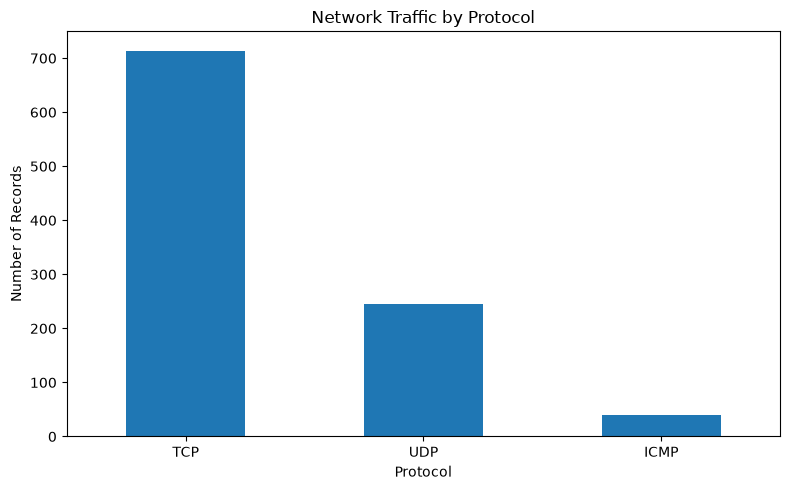

In [12]:
import matplotlib.pyplot as plt

# Visualize protocol distribution

protocol_counts = netflow_check["protocol"].value_counts()

plt.figure(figsize=(8, 5))
protocol_counts.plot(kind="bar")

plt.title("Network Traffic by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

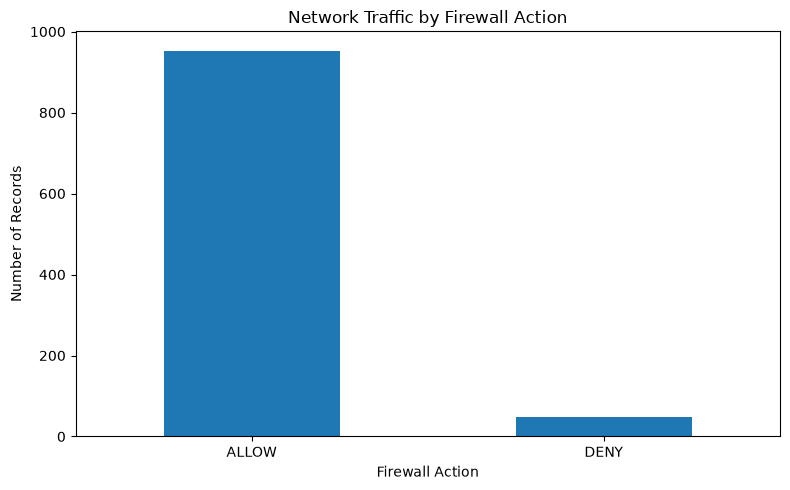

In [13]:
# Visualize firewall action distribution

action_counts = netflow_check["action"].value_counts()

plt.figure(figsize=(8, 5))
action_counts.plot(kind="bar")

plt.title("Network Traffic by Firewall Action")
plt.xlabel("Firewall Action")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Analyze network traffic volume over time

traffic_over_time = (
    netflow_check
    .set_index("timestamp")
    .resample("10min")
    .size()
)

plt.figure(figsize=(12, 5))
traffic_over_time.plot(kind="line")

plt.title("Network Traffic Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Network Events")
plt.tight_layout()
plt.show()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [15]:
# Convert timestamp back to datetime after loading the CSV

netflow_check["timestamp"] = pd.to_datetime(netflow_check["timestamp"])

print("Timestamp data type:")
print(netflow_check["timestamp"].dtype)

Timestamp data type:
datetime64[us]


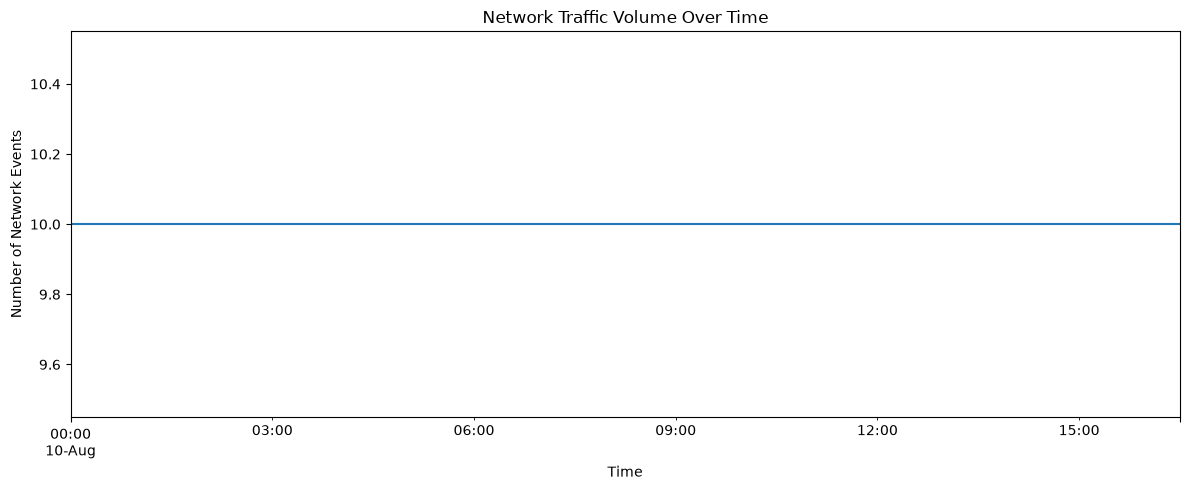

In [16]:
# Analyze network traffic volume over time

traffic_over_time = (
    netflow_check
    .set_index("timestamp")
    .resample("10min")
    .size()
)

plt.figure(figsize=(12, 5))
traffic_over_time.plot(kind="line")

plt.title("Network Traffic Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Network Events")
plt.tight_layout()
plt.show()

In [17]:
print("Shape:", netflow_check.shape)
print()
print("Columns:", list(netflow_check.columns))
print()
print("Dtypes:")
print(netflow_check.dtypes)
print()
print("First 5 rows:")
display(netflow_check.head())
print()
print("Timestamp range:")
print("  Start:", netflow_check["timestamp"].min())
print("  End:  ", netflow_check["timestamp"].max())
print("  Span: ", netflow_check["timestamp"].max() - netflow_check["timestamp"].min())
print()
print("Unique source IPs:", netflow_check["src_ip"].nunique() if "src_ip" in netflow_check.columns else "N/A")
print("Unique dest IPs:  ", netflow_check["dst_ip"].nunique() if "dst_ip" in netflow_check.columns else "N/A")

Shape: (1000, 9)

Columns: ['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'bytes_sent', 'bytes_recvd', 'protocol', 'action']

Dtypes:
timestamp      datetime64[us]
src_ip                    str
dst_ip                    str
src_port                int64
dst_port                int64
bytes_sent              int64
bytes_recvd             int64
protocol                  str
action                    str
dtype: object

First 5 rows:


,timestamp,src_ip,dst_ip,src_port,dst_port,bytes_sent,bytes_recvd,protocol,action
0,2026-08-10 00:00:00,10.0.3.189,172.16.5.171,35912,22,46725,86159,TCP,ALLOW
1,2026-08-10 00:01:00,10.0.1.24,172.16.8.218,37812,3389,38430,2235,TCP,ALLOW
2,2026-08-10 00:02:00,10.0.3.81,172.16.12.39,11237,53,19720,40945,TCP,ALLOW
3,2026-08-10 00:03:00,10.0.1.30,172.16.15.120,62073,443,19902,17441,TCP,ALLOW
4,2026-08-10 00:04:00,10.0.3.131,172.16.17.4,63517,22,25766,53175,ICMP,ALLOW



Timestamp range:
  Start: 2026-08-10 00:00:00
  End:   2026-08-10 16:39:00
  Span:  0 days 16:39:00

Unique source IPs: 619
Unique dest IPs:   896


In [18]:
# Show the current data generator so we can inspect it

with open("../src/data_generator.py", "r", encoding="utf-8") as f:
    print(f.read())

FileNotFoundError: [Errno 2] No such file or directory: '../src/data_generator.py'

In [19]:
import os

print("Current working directory:")
print(os.getcwd())
print()

for root, dirs, files in os.walk(".."):
    # Skip noisy folders
    dirs[:] = [d for d in dirs if d not in (".git", "__pycache__", ".ipynb_checkpoints", "venv", ".venv")]
    for f in files:
        if f.endswith(".py"):
            print(os.path.join(root, f))

Current working directory:
C:\Users\Scarl\OneDrive\Documents\Telecom-Security-Analytics\notebooks



In [20]:
import os

root = ".."

print("Project root listing:")
for item in sorted(os.listdir(root)):
    print("  ", item)

print()
print("Checking for src/ folder...")
src = os.path.join(root, "src")
if os.path.isdir(src):
    print("  src/ exists. Contents:")
    for item in sorted(os.listdir(src)):
        print("    ", item)
else:
    print("  No src/ folder found.")

print()
print("Checking for data/ folder...")
data = os.path.join(root, "data")
if os.path.isdir(data):
    print("  data/ exists. Contents:")
    for item in sorted(os.listdir(data)):
        print("    ", item)
else:
    print("  No data/ folder found.")

print()
print("Searching entire project for any .py file...")
found = False
for dirpath, dirnames, filenames in os.walk(root):
    dirnames[:] = [d for d in dirnames if d not in (".git", "__pycache__", ".ipynb_checkpoints", "venv", ".venv")]
    for f in filenames:
        if f.endswith(".py"):
            print("  ", os.path.join(dirpath, f))
            found = True
if not found:
    print("   (no .py files found anywhere in the project)")

Project root listing:
   dashboard
   data
   notebooks
   src

Checking for src/ folder...
  src/ exists. Contents:

Checking for data/ folder...
  data/ exists. Contents:
     netflow_test.csv

Searching entire project for any .py file...
   (no .py files found anywhere in the project)


In [21]:
import os

root = ".."

folders = [
    "src",
    "data/raw",
    "data/processed",
    "data/threat_intelligence",
    "notebooks",
    "models",
    "dashboard",
    "tests",
    "reports",
]

for folder in folders:
    path = os.path.join(root, folder)
    os.makedirs(path, exist_ok=True)
    # add a .gitkeep so empty folders survive in git
    keep = os.path.join(path, ".gitkeep")
    if not os.listdir(path) or os.listdir(path) == [".gitkeep"]:
        open(keep, "a").close()
    print("✔", path)

print()
print("Project skeleton ready.")

✔ ..\src
✔ ..\data/raw
✔ ..\data/processed
✔ ..\data/threat_intelligence
✔ ..\notebooks
✔ ..\models
✔ ..\dashboard
✔ ..\tests
✔ ..\reports

Project skeleton ready.


In [22]:
# This cell writes Part 1 of src/data_generator.py

part1 = '''"""
data_generator.py
-----------------
Synthetic multi-source telemetry generator for the SAS821S Capstone Project:
"Multi-Source Telemetry Analytics for Detecting Command-and-Control Beacons
and Lateral Movement in Telecom Networks"

Produces:
  - data/raw/netflow.csv   : realistic network flow records (multi-day, diurnal)
  - data/raw/dns.csv       : DNS query logs (benign + tunnelling)
  - data/raw/auth.csv      : authentication / endpoint logs (incl. lateral movement)

Attack scenarios injectable (per charter):
  - C2 beaconing (periodic, jittered)
  - DNS tunnelling (high-entropy subdomains)
  - Off-hours data exfiltration (large outbound transfers at night)
  - Lateral movement (authentication + SMB/RDP chains)

Run standalone:
  python data_generator.py
"""

from __future__ import annotations

import os
import random
import string
import ipaddress
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from typing import List, Tuple

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
CONFIG = {
    "start_date":        "2026-08-10 00:00:00",   # Monday
    "days":              7,                        # one full week
    "internal_subnets":  ["10.0.1.0/24", "10.0.2.0/24", "10.0.3.0/24"],
    "external_subnet":   "172.16.0.0/16",
    "business_hour_start": 8,     # 08:00
    "business_hour_end":  18,     # 18:00
    "night_factor":      0.15,    # 15% of business-hours volume at night
    "peak_factor":       1.60,    # lunch/afternoon peak multiplier
    "base_events_per_minute": 12,  # mean events/min during business hours
}

# ---------------------------------------------------------------------------
# Realistic service catalogue: (port, protocol, typical_bytes_sent_range,
# typical_bytes_recvd_range, weight)
# ---------------------------------------------------------------------------
SERVICES = [
    # port, proto, sent_bytes_low, sent_high, recv_low, recv_high, weight
    (443,  "TCP",  2_000,   80_000,  10_000, 1_500_000, 40),   # HTTPS
    (80,   "TCP",  1_000,   30_000,   5_000,   800_000, 15),   # HTTP
    (53,   "UDP",    100,      500,     200,     2_000, 12),   # DNS
    (22,   "TCP",    500,    5_000,     500,    10_000,  8),   # SSH
    (3389, "TCP",  1_000,   20_000,   2_000,    60_000,  5),   # RDP
    (25,   "TCP",    500,   10_000,     500,     5_000,  4),   # SMTP
    (110,  "TCP",    200,    3_000,     300,     4_000,  3),   # POP3
    (143,  "TCP",    200,    3_000,     300,     4_000,  3),   # IMAP
    (445,  "TCP",  2_000,   50_000,   5_000,   120_000,  4),   # SMB
    (123,  "UDP",     50,      200,      50,       200,  3),   # NTP
    (67,   "UDP",     50,      300,      50,       300,  1),   # DHCP
    (161,  "UDP",    100,      800,     200,     1_500,  1),   # SNMP
    (8080, "TCP",  1_000,   40_000,   3_000,   400_000,  1),   # HTTP-alt
]

_ports    = [s[0] for s in SERVICES]
_protos   = [s[1] for s in SERVICES]
_weights  = np.array([s[6] for s in SERVICES], dtype=float)
_weights /= _weights.sum()

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def _random_internal_ip() -> str:
    subnet = random.choice(CONFIG["internal_subnets"])
    net = ipaddress.ip_network(subnet)
    return str(net.network_address + random.randint(2, net.num_addresses - 2))

def _random_external_ip() -> str:
    net = ipaddress.ip_network(CONFIG["external_subnet"])
    return str(net.network_address + random.randint(2, net.num_addresses - 2))

def _random_ephemeral_port() -> int:
    return random.randint(32768, 60999)

def _pick_service():
    idx = np.random.choice(len(SERVICES), p=_weights)
    port, proto, s_lo, s_hi, r_lo, r_hi, _ = SERVICES[idx]
    sent = int(np.random.lognormal(
        mean=np.log((s_lo + s_hi) / 2), sigma=0.6))
    recv = int(np.random.lognormal(
        mean=np.log((r_lo + r_hi) / 2), sigma=0.7))
    sent = max(s_lo, min(s_hi, sent))
    recv = max(r_lo, min(r_hi, recv))
    return port, proto, sent, recv

def _hourly_rate_multiplier(hour: int) -> float:
    """Diurnal pattern: high during business hours, low at night, lunch dip."""
    if CONFIG["business_hour_start"] <= hour < CONFIG["business_hour_end"]:
        if hour in (12, 13):
            return CONFIG["peak_factor"] * 0.8   # lunch dip
        if 14 <= hour <= 16:
            return CONFIG["peak_factor"]        # afternoon peak
        return 1.0
    return CONFIG["night_factor"]

def _random_string(n: int) -> str:
    return "".join(random.choices(string.ascii_lowercase + string.digits, k=n))
'''

path = "../src/data_generator.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../src/data_generator.py
  File size: 5090 bytes


In [23]:
# This cell appends Part 2 of src/data_generator.py

part2 = '''

# ===========================================================================
# 1. NETFLOW GENERATOR
# ===========================================================================
def generate_netflow() -> pd.DataFrame:
    """Generate realistic multi-day NetFlow records with diurnal variation."""
    start = datetime.strptime(CONFIG["start_date"], "%Y-%m-%d %H:%M:%S")
    days = CONFIG["days"]
    base = CONFIG["base_events_per_minute"]

    rows: List[dict] = []
    for day in range(days):
        for hour in range(24):
            multiplier = _hourly_rate_multiplier(hour)
            for minute in range(60):
                # Poisson-jittered event count per minute
                mean_events = base * multiplier
                n_events = max(1, int(np.random.poisson(mean_events)))

                for _ in range(n_events):
                    ts = start + timedelta(
                        days=day, hours=hour, minutes=minute,
                        seconds=random.randint(0, 59))

                    port, proto, sent, recv = _pick_service()

                    # small chance of DENY (blocked traffic)
                    action = "DENY" if random.random() < 0.03 else "ALLOW"

                    rows.append({
                        "timestamp":   ts,
                        "src_ip":      _random_internal_ip(),
                        "dst_ip":      _random_external_ip(),
                        "src_port":    _random_ephemeral_port(),
                        "dst_port":    port,
                        "bytes_sent":  sent,
                        "bytes_recvd": recv,
                        "protocol":    proto,
                        "action":      action,
                    })

    df = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
    return df


# ===========================================================================
# 2. DNS LOG GENERATOR
# ===========================================================================
BENIGN_DOMAINS = [
    "google.com", "microsoft.com", "office365.com", "outlook.com",
    "cloudflare.com", "amazonaws.com", "azure.com", "github.com",
    "slack.com", "zoom.us", "salesforce.com", "oracle.com",
    "wikipedia.org", "linkedin.com", "netflix.com", "akamai.net",
    "youtube.com", "cdn.jsdelivr.net", "gstatic.com", "telecom.local",
]

def _benign_query() -> Tuple[str, str]:
    base = random.choice(BENIGN_DOMAINS)
    # occasionally add a subdomain
    if random.random() < 0.4:
        sub = random.choice(["www", "api", "cdn", "mail", "auth",
                             "portal", "static", "login", "app", "vpn"])
        return f"{sub}.{base}", base
    return base, base

def generate_dns(n_per_minute: int = 6) -> pd.DataFrame:
    """Generate DNS query logs with variable rate."""
    start = datetime.strptime(CONFIG["start_date"], "%Y-%m-%d %H:%M:%S")
    days = CONFIG["days"]

    rows: List[dict] = []
    for day in range(days):
        for hour in range(24):
            multiplier = _hourly_rate_multiplier(hour)
            for minute in range(60):
                n = max(1, int(np.random.poisson(n_per_minute * multiplier)))
                for _ in range(n):
                    ts = start + timedelta(
                        days=day, hours=hour, minutes=minute,
                        seconds=random.randint(0, 59))
                    query, base = _benign_query()
                    rows.append({
                        "timestamp":      ts,
                        "src_ip":         _random_internal_ip(),
                        "query":          query,
                        "query_type":     random.choices(
                                            ["A", "AAAA", "CNAME", "MX", "TXT"],
                                            weights=[70, 15, 8, 4, 3])[0],
                        "response_code":  "NOERROR" if random.random() < 0.95
                                          else "NXDOMAIN",
                        "response_ip":    _random_external_ip()
                                          if random.random() < 0.8 else None,
                        "domain":         base,
                    })

    return pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)


# ===========================================================================
# 3. AUTHENTICATION / ENDPOINT LOG GENERATOR
# ===========================================================================
USERS = [f"user{ i:03d}" for i in range(1, 61)]   # 60 users

def generate_auth(n_per_minute: int = 2) -> pd.DataFrame:
    """Generate authentication logs (login success/failure)."""
    start = datetime.strptime(CONFIG["start_date"], "%Y-%m-%d %H:%M:%S")
    days = CONFIG["days"]

    rows: List[dict] = []
    for day in range(days):
        for hour in range(24):
            multiplier = _hourly_rate_multiplier(hour)
            for minute in range(60):
                n = max(0, int(np.random.poisson(n_per_minute * multiplier)))
                for _ in range(n):
                    ts = start + timedelta(
                        days=day, hours=hour, minutes=minute,
                        seconds=random.randint(0, 59))
                    user = random.choice(USERS)
                    success = random.random() > 0.08   # ~8% failures
                    rows.append({
                        "timestamp":   ts,
                        "user":        user,
                        "src_ip":      _random_internal_ip(),
                        "host":        f"ws-{random.randint(1, 200):03d}",
                        "event_type":  "LOGIN",
                        "status":      "SUCCESS" if success else "FAILURE",
                        "auth_method": random.choice(
                                          ["PASSWORD", "KERBEROS", "TOKEN"]),
                    })

    return pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
'''

path = "../src/data_generator.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../src/data_generator.py
  File size now: 11134 bytes


In [24]:
# This cell appends Part 3 of src/data_generator.py

part3 = '''

# ===========================================================================
# 4. ATTACK INJECTION FUNCTIONS  (per charter requirements)
# ===========================================================================
MALICIOUS_DOMAINS = [
    "evil-c2.example",
    "badactor-update.net",
    "dns-tunnel.xyz",
    "malware-cdn.top",
    "apt-relay.cc",
]
MALICIOUS_IPS = [
    "172.16.99.10", "172.16.99.20", "172.16.99.30",
    "172.16.99.40", "172.16.99.50",
]

# Chosen compromised internal hosts for the scenario
COMPROMISED_HOSTS = ["10.0.1.50", "10.0.2.77", "10.0.3.111"]
BEACON_TARGET    = "172.16.99.10"
EXFIL_TARGET     = "172.16.99.20"


def inject_c2_beacon(netflow: pd.DataFrame,
                     dns: pd.DataFrame,
                     beacon_interval_sec: int = 60,
                     jitter_sec: int = 5,
                     duration_hours: int = 6,
                     start_hour_of_day: int = 10) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Inject a C2 beacon pattern:
      - Compromised host contacts MALICIOUS_IPS periodically (regular interval, small jitter)
      - Same host makes periodic DNS queries to a malicious domain
    """
    start = datetime.strptime(CONFIG["start_date"], "%Y-%m-%d %H:%M:%S")
    beacon_host = COMPROMISED_HOSTS[0]
    beacon_domain = MALICIOUS_DOMAINS[0]

    rows_net, rows_dns = [], []
    for day in range(CONFIG["days"]):
        day_start = start + timedelta(days=day, hours=start_hour_of_day)
        end = day_start + timedelta(hours=duration_hours)

        t = day_start
        while t < end:
            # small timing jitter to make detection non-trivial
            jitter = random.randint(-jitter_sec, jitter_sec)
            ts = t + timedelta(seconds=jitter)

            rows_net.append({
                "timestamp":   ts,
                "src_ip":      beacon_host,
                "dst_ip":      BEACON_TARGET,
                "src_port":    _random_ephemeral_port(),
                "dst_port":    443,
                "bytes_sent":  random.randint(200, 800),    # small
                "bytes_recvd": random.randint(150, 600),    # small
                "protocol":    "TCP",
                "action":      "ALLOW",
            })
            rows_dns.append({
                "timestamp":     ts,
                "src_ip":        beacon_host,
                "query":         f"beacon.{beacon_domain}",
                "query_type":    "A",
                "response_code": "NOERROR",
                "response_ip":   BEACON_TARGET,
                "domain":        beacon_domain,
            })

            t += timedelta(seconds=beacon_interval_sec)

    netflow = pd.concat([netflow, pd.DataFrame(rows_net)], ignore_index=True)
    dns = pd.concat([dns, pd.DataFrame(rows_dns)], ignore_index=True)
    return netflow, dns


def inject_dns_tunnelling(dns: pd.DataFrame,
                          n_queries_per_hour: int = 40,
                          duration_hours: int = 5,
                          start_hour_of_day: int = 9) -> pd.DataFrame:
    """
    Inject DNS tunnelling:
      - High-entropy, long, random subdomains under a malicious domain
      - Many TXT queries (data encoded in responses)
    """
    start = datetime.strptime(CONFIG["start_date"], "%Y-%m-%d %H:%M:%S")
    tunnel_host = COMPROMISED_HOSTS[1]
    tunnel_domain = MALICIOUS_DOMAINS[2]

    rows = []
    for day in range(CONFIG["days"]):
        day_start = start + timedelta(days=day, hours=start_hour_of_day)
        end = day_start + timedelta(hours=duration_hours)

        n_total = n_queries_per_hour * duration_hours
        for _ in range(n_total):
            ts = day_start + timedelta(
                seconds=random.randint(0, duration_hours * 3600))
            sub = _random_string(random.randint(20, 40))
            rows.append({
                "timestamp":     ts,
                "src_ip":        tunnel_host,
                "query":         f"{sub}.{tunnel_domain}",
                "query_type":    random.choices(["TXT", "A", "AAAA"],
                                                weights=[60, 30, 10])[0],
                "response_code": "NOERROR",
                "response_ip":   None,
                "domain":        tunnel_domain,
            })

    dns = pd.concat([dns, pd.DataFrame(rows)], ignore_index=True)
    return dns


def inject_exfiltration(netflow: pd.DataFrame,
                        n_transfers_per_night: int = 6,
                        duration_nights: int = 5,
                        start_hour: int = 2) -> pd.DataFrame:
    """
    Inject off-hours data exfiltration:
      - Large outbound transfers at 02:00-03:00 (well outside business hours)
      - Asymmetric bytes (sent >> received)
    """
    start = datetime.strptime(CONFIG["start_date"], "%Y-%m-%d %H:%M:%S")
    exfil_host = COMPROMISED_HOSTS[2]

    rows = []
    for day in range(duration_nights):
        for _ in range(n_transfers_per_night):
            ts = start + timedelta(
                days=day, hours=start_hour,
                minutes=random.randint(0, 59),
                seconds=random.randint(0, 59))
            sent = random.randint(5_000_000, 50_000_000)  # 5-50 MB out
            recv = random.randint(1_000, 20_000)          # tiny response
            rows.append({
                "timestamp":   ts,
                "src_ip":      exfil_host,
                "dst_ip":      EXFIL_TARGET,
                "src_port":    _random_ephemeral_port(),
                "dst_port":    443,
                "bytes_sent":  sent,
                "bytes_recvd": recv,
                "protocol":    "TCP",
                "action":      "ALLOW",
            })

    netflow = pd.concat([netflow, pd.DataFrame(rows)], ignore_index=True)
    return netflow


def inject_lateral_movement(netflow: pd.DataFrame,
                            auth: pd.DataFrame,
                            chain_length: int = 4) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Inject lateral movement:
      - One host authenticates to several internal hosts in quick succession
      - Followed by SMB (445) traffic to those same hosts
    """
    start = datetime.strptime(CONFIG["start_date"], "%Y-%m-%d %H:%M:%S")
    pivot = COMPROMISED_HOSTS[0]
    user  = "user007"

    rows_net, rows_auth = [], []
    for day in range(CONFIG["days"]):
        base_ts = start + timedelta(days=day, hours=14, minutes=30)
        targets = random.sample(
            [f"10.0.{random.randint(1,3)}.{random.randint(1,254)}"
             for _ in range(chain_length * 2)],
            chain_length)

        for i, target in enumerate(targets):
            ts_auth = base_ts + timedelta(minutes=i * 3)
            ts_net  = ts_auth + timedelta(seconds=random.randint(10, 60))

            rows_auth.append({
                "timestamp":   ts_auth,
                "user":        user,
                "src_ip":      pivot,
                "host":        f"ws-{random.randint(1, 200):03d}",
                "event_type":  "LOGIN",
                "status":      "SUCCESS",
                "auth_method": "KERBEROS",
            })
            rows_net.append({
                "timestamp":   ts_net,
                "src_ip":      pivot,
                "dst_ip":      target,
                "src_port":    _random_ephemeral_port(),
                "dst_port":    445,
                "bytes_sent":  random.randint(5_000, 50_000),
                "bytes_recvd": random.randint(2_000, 30_000),
                "protocol":    "TCP",
                "action":      "ALLOW",
            })

    netflow = pd.concat([netflow, pd.DataFrame(rows_net)], ignore_index=True)
    auth    = pd.concat([auth,    pd.DataFrame(rows_auth)], ignore_index=True)
    return netflow, auth


# ===========================================================================
# 5. ORCHESTRATION + SAVE
# ===========================================================================
def save_all(netflow: pd.DataFrame,
             dns: pd.DataFrame,
             auth: pd.DataFrame,
             out_dir: str = "../data/raw") -> None:
    os.makedirs(out_dir, exist_ok=True)
    netflow.sort_values("timestamp").to_csv(
        os.path.join(out_dir, "netflow.csv"), index=False)
    dns.sort_values("timestamp").to_csv(
        os.path.join(out_dir, "dns.csv"), index=False)
    auth.sort_values("timestamp").to_csv(
        os.path.join(out_dir, "auth.csv"), index=False)
    print(f"✔ netflow.csv : {len(netflow):>7,} rows")
    print(f"✔ dns.csv     : {len(dns):>7,} rows")
    print(f"✔ auth.csv    : {len(auth):>7,} rows")


def build_dataset(inject_attacks: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    print("Generating NetFlow ...")
    netflow = generate_netflow()
    print("Generating DNS ...")
    dns = generate_dns()
    print("Generating Auth ...")
    auth = generate_auth()

    if inject_attacks:
        print("Injecting C2 beacon ...")
        netflow, dns = inject_c2_beacon(netflow, dns)
        print("Injecting DNS tunnelling ...")
        dns = inject_dns_tunnelling(dns)
        print("Injecting exfiltration ...")
        netflow = inject_exfiltration(netflow)
        print("Injecting lateral movement ...")
        netflow, auth = inject_lateral_movement(netflow, auth)

    return netflow, dns, auth


if __name__ == "__main__":
    netflow, dns, auth = build_dataset(inject_attacks=True)
    save_all(netflow, dns, auth)
    print("\\nDone. Data written to data/raw/")
'''

path = "../src/data_generator.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part3)

print("✔ Part 3 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 3 appended to ../src/data_generator.py
  Final file size: 20861 bytes


In [25]:
# Run the generator in-process so we can inspect the result immediately

import sys, os, importlib

# Make sure src/ is importable
sys.path.insert(0, os.path.abspath("../src"))

# Force a fresh import in case it was imported before
if "data_generator" in sys.modules:
    del sys.modules["data_generator"]

import data_generator as dg
importlib.reload(dg)

netflow, dns, auth = dg.build_dataset(inject_attacks=True)
dg.save_all(netflow, dns, auth)

print()
print("=" * 60)
print("Dataset summary")
print("=" * 60)
for name, df in [("NetFlow", netflow), ("DNS", dns), ("Auth", auth)]:
    print(f"\n{name}: {len(df):,} rows")
    print("  Time span:", df["timestamp"].min(), "→", df["timestamp"].max())
    print("  Unique src IPs:", df["src_ip"].nunique() if "src_ip" in df.columns else "—")

Generating NetFlow ...
Generating DNS ...
Generating Auth ...
Injecting C2 beacon ...
Injecting DNS tunnelling ...
Injecting exfiltration ...
Injecting lateral movement ...
✔ netflow.csv :  76,311 rows
✔ dns.csv     :  42,724 rows
✔ auth.csv    :  12,113 rows

Dataset summary

NetFlow: 76,311 rows
  Time span: 2026-08-10 00:00:05 → 2026-08-16 23:59:29
  Unique src IPs: 759

DNS: 42,724 rows
  Time span: 2026-08-10 00:00:02 → 2026-08-16 23:59:13
  Unique src IPs: 759

Auth: 12,113 rows
  Time span: 2026-08-10 00:01:22 → 2026-08-16 23:59:43
  Unique src IPs: 759


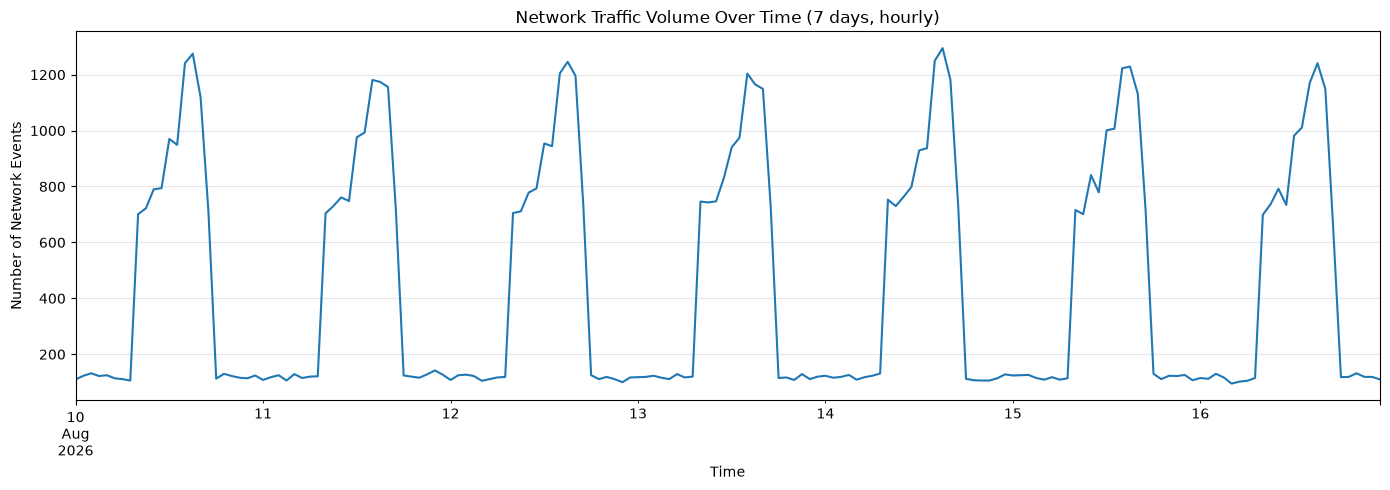

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

netflow_check = pd.read_csv("../data/raw/netflow.csv", parse_dates=["timestamp"])

traffic_over_time = (
    netflow_check
    .set_index("timestamp")
    .resample("1h")           # 1-hour buckets, clearer for 7 days
    .size()
)

plt.figure(figsize=(14, 5))
traffic_over_time.plot(kind="line", color="#1f77b4")

plt.title("Network Traffic Volume Over Time (7 days, hourly)")
plt.xlabel("Time")
plt.ylabel("Number of Network Events")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Patch data_generator.py: add weekend factor

path = "../src/data_generator.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# --- 1. Replace the _hourly_rate_multiplier function ---
old_fn = '''def _hourly_rate_multiplier(hour: int) -> float:
    """Diurnal pattern: high during business hours, low at night, lunch dip."""
    if CONFIG["business_hour_start"] <= hour < CONFIG["business_hour_end"]:
        if hour in (12, 13):
            return CONFIG["peak_factor"] * 0.8   # lunch dip
        if 14 <= hour <= 16:
            return CONFIG["peak_factor"]        # afternoon peak
        return 1.0
    return CONFIG["night_factor"]'''

new_fn = '''def _hourly_rate_multiplier(hour: int, weekday: int = 0) -> float:
    """
    Diurnal pattern:
      - high during business hours, low at night
      - lunch-time dip
      - afternoon peak
      - weekends are quieter (~40% of weekday business-hours volume)
    weekday: 0=Monday ... 6=Sunday
    """
    # Weekend reduction factor
    weekend_factor = 0.4 if weekday >= 5 else 1.0

    if CONFIG["business_hour_start"] <= hour < CONFIG["business_hour_end"]:
        if hour in (12, 13):
            base = CONFIG["peak_factor"] * 0.8   # lunch dip
        elif 14 <= hour <= 16:
            base = CONFIG["peak_factor"]        # afternoon peak
        else:
            base = 1.0
        return base * weekend_factor

    # Night: weekends are a bit busier at night (social traffic)
    night_mult = CONFIG["night_factor"] * (1.5 if weekday >= 5 else 1.0)
    return night_mult'''

assert old_fn in src, "Could not find old _hourly_rate_multiplier block"
src = src.replace(old_fn, new_fn)

# --- 2. Update the three call sites so they pass the weekday ---
old_call = 'multiplier = _hourly_rate_multiplier(hour)'
new_call = '''# day is 0-based from start_date; start_date is a Monday, so weekday = day % 7
            weekday = day % 7
            multiplier = _hourly_rate_multiplier(hour, weekday)'''

count = src.count(old_call)
assert count == 3, f"Expected 3 call sites, found {count}"
src = src.replace(old_call, new_call)

with open(path, "w", encoding="utf-8") as f:
    f.write(src)

print("✔ Patched _hourly_rate_multiplier with weekend factor")
print("✔ Updated", count, "call sites to pass weekday")
print("  File size now:", os.path.getsize(path), "bytes")

✔ Patched _hourly_rate_multiplier with weekend factor
✔ Updated 3 call sites to pass weekday
  File size now: 21712 bytes


In [28]:
✔ Patched _hourly_rate_multiplier with weekend factor
✔ Updated 3 call sites to pass weekday
  File size now: 21712 bytes

SyntaxError: invalid character '✔' (U+2714) (293280434.py, line 1)

In [29]:
# Patch data_generator.py: add weekend factor

path = "../src/data_generator.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# --- 1. Replace the _hourly_rate_multiplier function ---
old_fn = '''def _hourly_rate_multiplier(hour: int) -> float:
    """Diurnal pattern: high during business hours, low at night, lunch dip."""
    if CONFIG["business_hour_start"] <= hour < CONFIG["business_hour_end"]:
        if hour in (12, 13):
            return CONFIG["peak_factor"] * 0.8   # lunch dip
        if 14 <= hour <= 16:
            return CONFIG["peak_factor"]        # afternoon peak
        return 1.0
    return CONFIG["night_factor"]'''

new_fn = '''def _hourly_rate_multiplier(hour: int, weekday: int = 0) -> float:
    """
    Diurnal pattern:
      - high during business hours, low at night
      - lunch-time dip
      - afternoon peak
      - weekends are quieter (~40% of weekday business-hours volume)
    weekday: 0=Monday ... 6=Sunday
    """
    # Weekend reduction factor
    weekend_factor = 0.4 if weekday >= 5 else 1.0

    if CONFIG["business_hour_start"] <= hour < CONFIG["business_hour_end"]:
        if hour in (12, 13):
            base = CONFIG["peak_factor"] * 0.8   # lunch dip
        elif 14 <= hour <= 16:
            base = CONFIG["peak_factor"]        # afternoon peak
        else:
            base = 1.0
        return base * weekend_factor

    # Night: weekends are a bit busier at night (social traffic)
    night_mult = CONFIG["night_factor"] * (1.5 if weekday >= 5 else 1.0)
    return night_mult'''

assert old_fn in src, "Could not find old _hourly_rate_multiplier block"
src = src.replace(old_fn, new_fn)

# --- 2. Update the three call sites so they pass the weekday ---
old_call = 'multiplier = _hourly_rate_multiplier(hour)'
new_call = '''# day is 0-based from start_date; start_date is a Monday, so weekday = day % 7
            weekday = day % 7
            multiplier = _hourly_rate_multiplier(hour, weekday)'''

count = src.count(old_call)
assert count == 3, f"Expected 3 call sites, found {count}"
src = src.replace(old_call, new_call)

with open(path, "w", encoding="utf-8") as f:
    f.write(src)

print("✔ Patched _hourly_rate_multiplier with weekend factor")
print("✔ Updated", count, "call sites to pass weekday")
print("  File size now:", os.path.getsize(path), "bytes")

AssertionError: Could not find old _hourly_rate_multiplier block

In [30]:
path = "../src/data_generator.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# Find the function and print surrounding lines with line numbers
lines = src.splitlines()
start = None
for i, line in enumerate(lines):
    if "def _hourly_rate_multiplier" in line:
        start = i
        break

assert start is not None, "Function not found at all"

print("Found at line", start + 1)
print("---- 25 lines starting from there ----")
for i in range(start, min(start + 25, len(lines))):
    print(f"{i+1:>4}: {repr(lines[i])}")

Found at line 108
---- 25 lines starting from there ----
 108: 'def _hourly_rate_multiplier(hour: int, weekday: int = 0) -> float:'
 109: '    """'
 110: '    Diurnal pattern:'
 111: '      - high during business hours, low at night'
 112: '      - lunch-time dip'
 113: '      - afternoon peak'
 114: '      - weekends are quieter (~40% of weekday business-hours volume)'
 115: '    weekday: 0=Monday ... 6=Sunday'
 116: '    """'
 117: '    # Weekend reduction factor'
 118: '    weekend_factor = 0.4 if weekday >= 5 else 1.0'
 119: ''
 120: '    if CONFIG["business_hour_start"] <= hour < CONFIG["business_hour_end"]:'
 121: '        if hour in (12, 13):'
 122: '            base = CONFIG["peak_factor"] * 0.8   # lunch dip'
 123: '        elif 14 <= hour <= 16:'
 124: '            base = CONFIG["peak_factor"]        # afternoon peak'
 125: '        else:'
 126: '            base = 1.0'
 127: '        return base * weekend_factor'
 128: ''
 129: '    # Night: weekends are a bit busier at nigh

In [31]:
assert old_fn in src, "..."   # ← this failed on the FIRST run
src = src.replace(old_fn, new_fn)

AssertionError: ...

In [32]:
import os
path = "../src/data_generator.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

print("File size:", os.path.getsize(path), "bytes")
print()
print("Old-style call sites remaining:", src.count("multiplier = _hourly_rate_multiplier(hour)"))
print("New-style call sites present:  ", src.count("multiplier = _hourly_rate_multiplier(hour, weekday)"))
print("Weekday variable present:      ", "weekday = day % 7" in src)
print()
print("---- All lines containing '_hourly_rate_multiplier' ----")
for i, line in enumerate(src.splitlines(), start=1):
    if "_hourly_rate_multiplier" in line:
        print(f"{i:>4}: {repr(line)}")

File size: 21712 bytes

Old-style call sites remaining: 0
New-style call sites present:   3
Weekday variable present:       True

---- All lines containing '_hourly_rate_multiplier' ----
 108: 'def _hourly_rate_multiplier(hour: int, weekday: int = 0) -> float:'
 151: '            multiplier = _hourly_rate_multiplier(hour, weekday)'
 213: '            multiplier = _hourly_rate_multiplier(hour, weekday)'
 253: '            multiplier = _hourly_rate_multiplier(hour, weekday)'


In [33]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "data_generator" in sys.modules:
    del sys.modules["data_generator"]
import data_generator as dg
importlib.reload(dg)

netflow, dns, auth = dg.build_dataset(inject_attacks=True)
dg.save_all(netflow, dns, auth)

Generating NetFlow ...
Generating DNS ...
Generating Auth ...
Injecting C2 beacon ...
Injecting DNS tunnelling ...
Injecting exfiltration ...
Injecting lateral movement ...
✔ netflow.csv :  66,995 rows
✔ dns.csv     :  38,172 rows
✔ auth.csv    :  10,616 rows


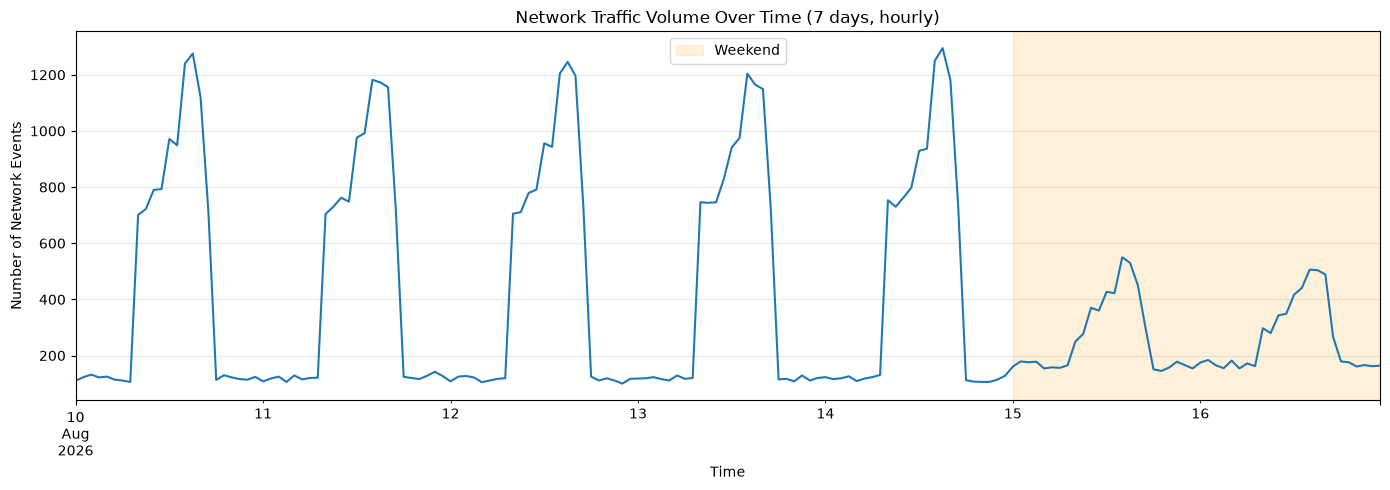

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

netflow_check = pd.read_csv("../data/raw/netflow.csv", parse_dates=["timestamp"])

traffic_over_time = (
    netflow_check
    .set_index("timestamp")
    .resample("1h")
    .size()
)

fig, ax = plt.subplots(figsize=(14, 5))
traffic_over_time.plot(kind="line", color="#1f77b4", ax=ax)

# shade weekends (Sat 15 Aug and Sun 16 Aug)
ax.axvspan(pd.Timestamp("2026-08-15 00:00"),
           pd.Timestamp("2026-08-17 00:00"),
           color="orange", alpha=0.15, label="Weekend")

ax.set_title("Network Traffic Volume Over Time (7 days, hourly)")
ax.set_xlabel("Time")
ax.set_ylabel("Number of Network Events")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

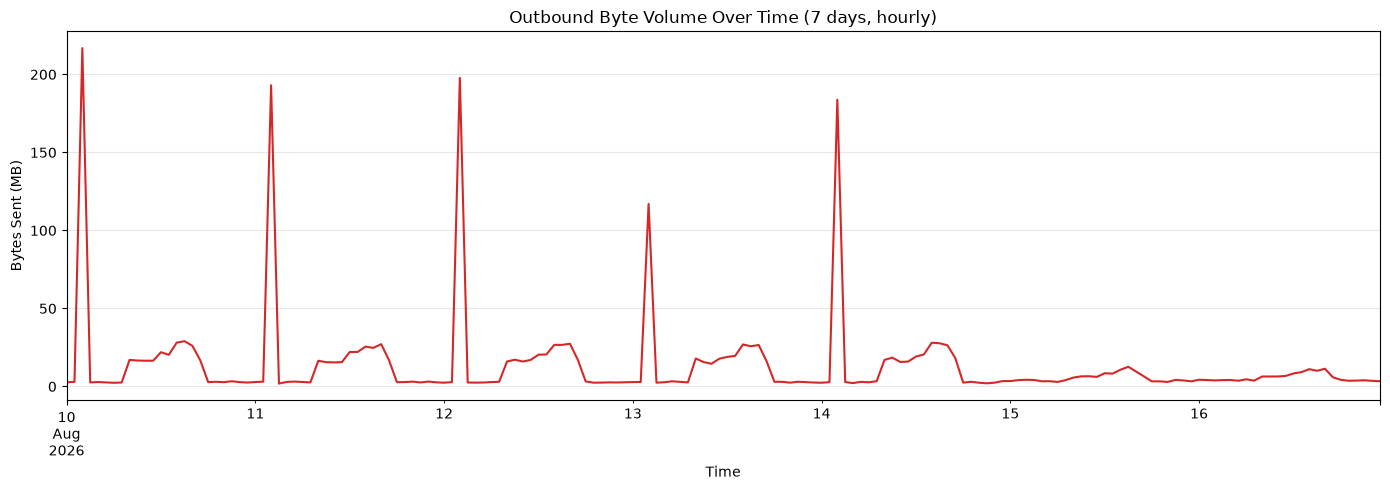

In [35]:
# Outbound byte volume per hour — exfiltration spikes will show here

byte_volume = (
    netflow_check
    .set_index("timestamp")
    .resample("1h")["bytes_sent"]
    .sum() / 1_000_000     # convert bytes → MB
)

fig, ax = plt.subplots(figsize=(14, 5))
byte_volume.plot(kind="line", color="#d62728", ax=ax)
ax.set_title("Outbound Byte Volume Over Time (7 days, hourly)")
ax.set_xlabel("Time")
ax.set_ylabel("Bytes Sent (MB)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

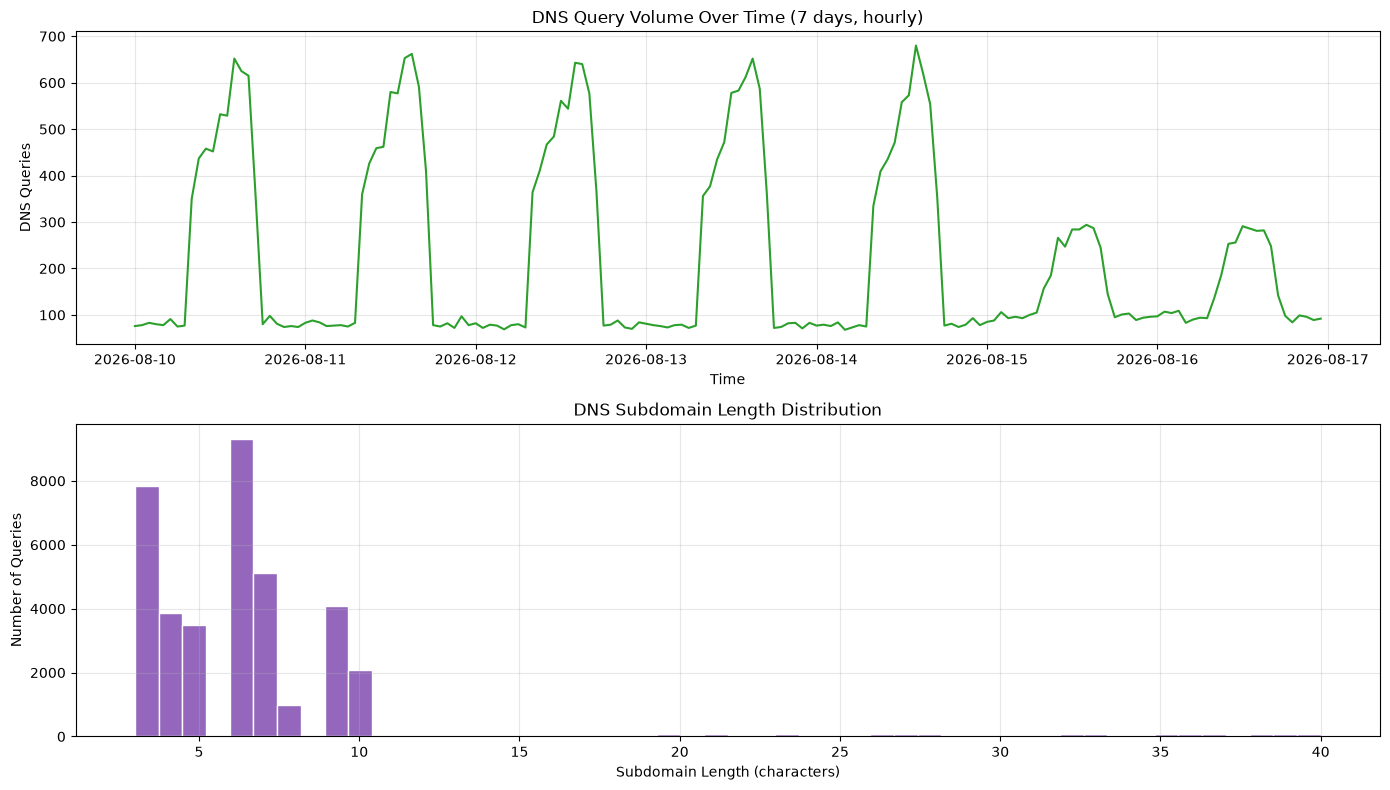

Subdomain length — top 10 longest:
          timestamp    src_ip                                                   query query_type  sub_len
2026-08-10 10:16:33 10.0.2.77 zm4c69su3w8iojeppl81ltvxgvzougu58zaj4h21.dns-tunnel.xyz          A       40
2026-08-10 10:36:15 10.0.2.77 2mplwm8c4b7ogw63g7w20h2yptm4zslnczxmefyh.dns-tunnel.xyz          A       40
2026-08-10 10:51:54 10.0.2.77 np8orv8devwf2iy6hhh8mvybl61wt406qqvd2nqg.dns-tunnel.xyz          A       40
2026-08-10 11:10:04 10.0.2.77 tb7nh58chf12vicujjjj5cemnv03fboa5tbav2y5.dns-tunnel.xyz       AAAA       40
2026-08-10 11:12:40 10.0.2.77 c7gl1ygvh36kh1w1uaw3112n2aurcpqfzensl63n.dns-tunnel.xyz        TXT       40
2026-08-10 12:51:33 10.0.2.77 alu7ssqbcxwoedgbszexdlcdtu2ym64uyuwgfbwi.dns-tunnel.xyz        TXT       40
2026-08-10 13:19:12 10.0.2.77 1gtdev2eodl1oeqeh3mzzyi120sdkf2nr1031eye.dns-tunnel.xyz        TXT       40
2026-08-10 13:31:35 10.0.2.77 xu6vod8f6ww9bz3nras4v4xwg78oflskzfpr91x6.dns-tunnel.xyz          A       40
2026-08-11 

In [36]:
# Load DNS data
dns_check = pd.read_csv("../data/raw/dns.csv", parse_dates=["timestamp"])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ---- Panel 1: DNS query volume per hour ----
dns_volume = (
    dns_check
    .set_index("timestamp")
    .resample("1h")
    .size()
)
axes[0].plot(dns_volume.index, dns_volume.values, color="#2ca02c")
axes[0].set_title("DNS Query Volume Over Time (7 days, hourly)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("DNS Queries")
axes[0].grid(alpha=0.3)

# ---- Panel 2: subdomain length distribution (benign vs suspicious) ----
dns_check["subdomain"] = dns_check["query"].str.split(".").str[0]
dns_check["sub_len"]   = dns_check["subdomain"].str.len()

axes[1].hist(dns_check["sub_len"], bins=50, color="#9467bd", edgecolor="white")
axes[1].set_title("DNS Subdomain Length Distribution")
axes[1].set_xlabel("Subdomain Length (characters)")
axes[1].set_ylabel("Number of Queries")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Numeric summary for the report
print("Subdomain length — top 10 longest:")
print(dns_check.nlargest(10, "sub_len")[["timestamp", "src_ip", "query", "query_type", "sub_len"]].to_string(index=False))

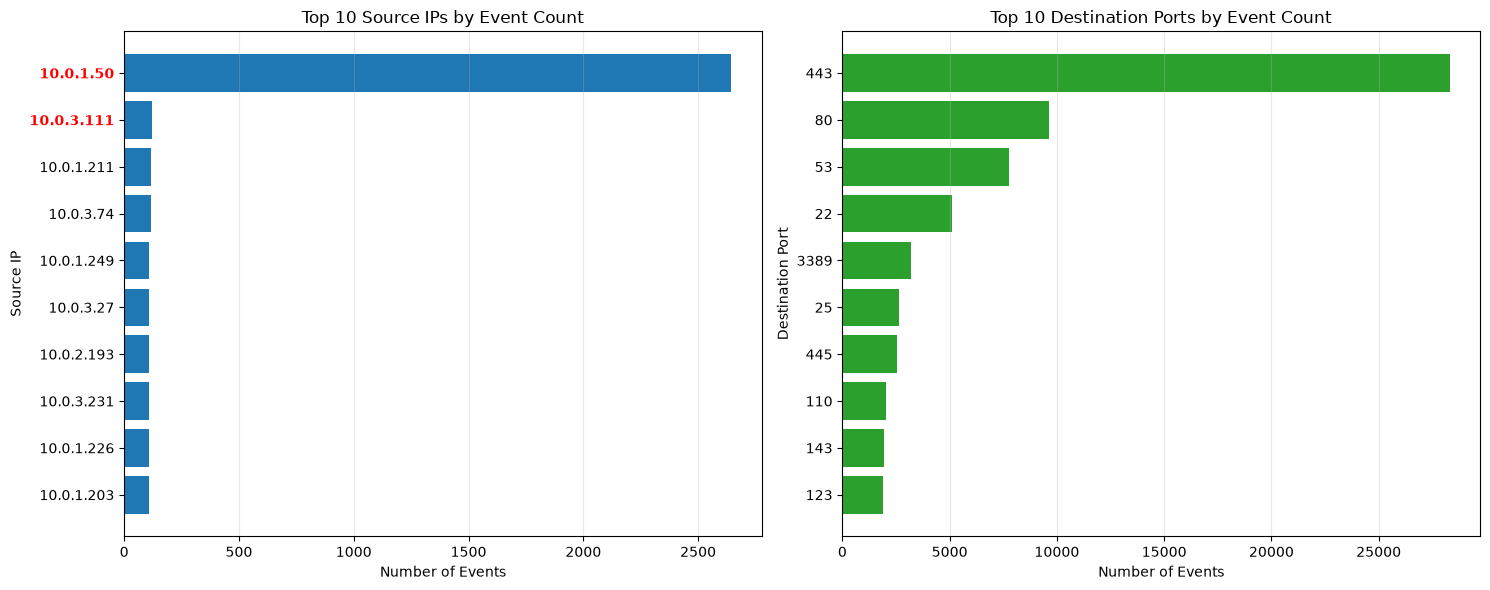


Compromised-host activity (ground truth):
  10.0.1.50: 2,645 events   bytes_out =      4.3 MB   unique dst IPs = 125
  10.0.2.77:    98 events   bytes_out =      2.1 MB   unique dst IPs = 97
  10.0.3.111:   120 events   bytes_out =    896.9 MB   unique dst IPs = 91


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Top 10 source IPs by event count ----
top_src = netflow_check["src_ip"].value_counts().head(10)
axes[0].barh(top_src.index[::-1], top_src.values[::-1], color="#1f77b4")
axes[0].set_title("Top 10 Source IPs by Event Count")
axes[0].set_xlabel("Number of Events")
axes[0].set_ylabel("Source IP")
axes[0].grid(alpha=0.3, axis="x")

# Highlight known compromised hosts
for tick in axes[0].get_yticklabels():
    if tick.get_text() in ("10.0.1.50", "10.0.2.77", "10.0.3.111"):
        tick.set_color("red")
        tick.set_fontweight("bold")

# ---- Top 10 destination ports by event count ----
top_ports = netflow_check["dst_port"].value_counts().head(10)
axes[1].barh(top_ports.index.astype(str)[::-1], top_ports.values[::-1], color="#2ca02c")
axes[1].set_title("Top 10 Destination Ports by Event Count")
axes[1].set_xlabel("Number of Events")
axes[1].set_ylabel("Destination Port")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# Summary for the report
print("\nCompromised-host activity (ground truth):")
for host in ["10.0.1.50", "10.0.2.77", "10.0.3.111"]:
    sub = netflow_check[netflow_check["src_ip"] == host]
    print(f"  {host}: {len(sub):>5,} events   "
          f"bytes_out = {sub['bytes_sent'].sum()/1e6:>8.1f} MB   "
          f"unique dst IPs = {sub['dst_ip'].nunique()}")

In [38]:
# Write Part 1 of src/features.py

part1 = '''"""
features.py
-----------
Feature engineering for the SAS821S Capstone Project.

Builds ML-ready feature tables from raw telemetry, aggregated per host
per configurable time window (default: 1 hour).

Feature groups (each tied to a charter requirement):
  1. Beacon timing      -> regular-interval C2 detection
  2. DNS analytics      -> entropy-based tunnelling detection
  3. Byte/off-hours     -> exfiltration detection
  4. Auth analytics     -> lateral movement detection

Main entry point:
    build_features(netflow, dns, auth, window="1h") -> pd.DataFrame
"""

from __future__ import annotations

import numpy as np
import pandas as pd
from typing import Tuple

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
WINDOW = "1h"                    # aggregation window
BUSINESS_HOUR_START = 8
BUSINESS_HOUR_END = 18


# ===========================================================================
# 1. BEACON TIMING FEATURES  (per host, per window)
# ===========================================================================
def _beacon_features_for_group(g: pd.DataFrame) -> pd.Series:
    """
    For a single (host, window) group of netflow events, compute features
    that reveal periodic beaconing behaviour.
    """
    out = {}

    # sort by time and compute inter-arrival deltas (seconds)
    g_sorted = g.sort_values("timestamp")
    deltas = g_sorted["timestamp"].diff().dt.total_seconds().dropna()

    if len(deltas) >= 2:
        out["delta_mean"]   = deltas.mean()
        out["delta_std"]    = deltas.std()
        out["delta_median"] = deltas.median()
        # coefficient of variation: low CV == very regular == beacon-like
        out["delta_cv"]     = (deltas.std() / deltas.mean()
                               if deltas.mean() > 0 else np.nan)
        # regularity score: 1.0 == perfectly regular, 0 == random
        # (uses median absolute deviation of deltas)
        mad = (deltas - deltas.median()).abs().median()
        out["delta_mad"]    = mad
        out["regularity"]   = 1.0 / (1.0 + mad) if mad >= 0 else np.nan
    else:
        out["delta_mean"]   = np.nan
        out["delta_std"]    = np.nan
        out["delta_median"] = np.nan
        out["delta_cv"]     = np.nan
        out["delta_mad"]    = np.nan
        out["regularity"]   = np.nan

    # how much does this host repeat the same destination IP?
    out["unique_dst_ips"]     = g["dst_ip"].nunique()
    out["top_dst_share"]      = (g["dst_ip"].value_counts().iloc[0] / len(g)
                                 if len(g) > 0 else np.nan)
    out["unique_dst_ports"]   = g["dst_port"].nunique()
    out["top_port_share"]     = (g["dst_port"].value_counts().iloc[0] / len(g)
                                 if len(g) > 0 else np.nan)

    # event volume in this window
    out["event_count"] = len(g)

    # average bytes per event (beacons are tiny)
    out["avg_bytes_sent"]  = g["bytes_sent"].mean()
    out["avg_bytes_recvd"] = g["bytes_recvd"].mean()

    return pd.Series(out)


def build_beacon_features(netflow: pd.DataFrame,
                          window: str = WINDOW) -> pd.DataFrame:
    """
    Aggregate netflow by (src_ip, time-window) and compute beacon features.

    Returns a dataframe indexed by (src_ip, window_start) with one row per host
    per window, containing all beacon-timing features.
    """
    df = netflow.copy()
    df["window_start"] = df["timestamp"].dt.floor(window)

    grouped = (
        df.groupby(["src_ip", "window_start"], group_keys=False)
          .apply(_beacon_features_for_group)
          .reset_index()
    )
    return grouped
'''

path = "../src/features.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../src/features.py
  File size: 3807 bytes


In [39]:
# Append Part 2 of src/features.py

part2 = '''

# ===========================================================================
# 2. DNS FEATURES  (per host, per window)
# ===========================================================================
def _shannon_entropy(s: str) -> float:
    """Shannon entropy in bits per character."""
    if not s:
        return 0.0
    from collections import Counter
    counts = Counter(s)
    n = len(s)
    return -sum((c / n) * np.log2(c / n) for c in counts.values())


def _dns_features_for_group(g: pd.DataFrame) -> pd.Series:
    """Per-(host, window) DNS behaviour features."""
    out = {}

    if len(g) == 0:
        return pd.Series({
            "dns_count":              0,
            "dns_avg_sub_len":        np.nan,
            "dns_max_sub_len":        np.nan,
            "dns_avg_entropy":        np.nan,
            "dns_max_entropy":        np.nan,
            "dns_digit_ratio":        np.nan,
            "dns_unique_domains":     0,
            "dns_unique_subdomains":  0,
            "dns_subdomain_uniqueness": np.nan,
            "dns_txt_ratio":          np.nan,
            "dns_nxdomain_ratio":     np.nan,
            "dns_top_domain_share":   np.nan,
        })

    # subdomain = first label of the query
    subdomains = g["query"].astype(str).str.split(".").str[0]

    sub_lengths = subdomains.str.len()
    entropies   = subdomains.apply(_shannon_entropy)

    # digit ratio in subdomain
    digits = subdomains.str.count(r"\\d")
    digit_ratio = (digits.sum() / sub_lengths.sum()
                   if sub_lengths.sum() > 0 else np.nan)

    out["dns_count"]              = len(g)
    out["dns_avg_sub_len"]        = sub_lengths.mean()
    out["dns_max_sub_len"]        = sub_lengths.max()
    out["dns_avg_entropy"]        = entropies.mean()
    out["dns_max_entropy"]        = entropies.max()
    out["dns_digit_ratio"]        = digit_ratio
    out["dns_unique_domains"]     = g["domain"].nunique()
    out["dns_unique_subdomains"]  = subdomains.nunique()
    out["dns_subdomain_uniqueness"] = (
        subdomains.nunique() / len(subdomains) if len(subdomains) > 0 else np.nan
    )
    out["dns_txt_ratio"]          = (
        (g["query_type"] == "TXT").mean() if "query_type" in g.columns else np.nan
    )
    out["dns_nxdomain_ratio"]     = (
        (g["response_code"] == "NXDOMAIN").mean()
        if "response_code" in g.columns else np.nan
    )
    out["dns_top_domain_share"]   = (
        g["domain"].value_counts().iloc[0] / len(g) if len(g) > 0 else np.nan
    )

    return pd.Series(out)


def build_dns_features(dns: pd.DataFrame,
                       window: str = WINDOW) -> pd.DataFrame:
    """Aggregate DNS logs by (src_ip, window) with entropy/length features."""
    df = dns.copy()
    df["window_start"] = df["timestamp"].dt.floor(window)

    grouped = (
        df.groupby(["src_ip", "window_start"], group_keys=False)
          .apply(_dns_features_for_group)
          .reset_index()
    )
    return grouped
'''

path = "../src/features.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../src/features.py
  File size now: 6867 bytes


In [40]:
# Append Part 3 of src/features.py

part3 = '''

# ===========================================================================
# 3. BYTE / OFF-HOURS FEATURES  (per host, per window)
# ===========================================================================
def _byte_features_for_group(g: pd.DataFrame) -> pd.Series:
    """Per-(host, window) byte-behaviour and time-of-day features."""
    out = {}

    if len(g) == 0:
        return pd.Series({
            "byte_total_sent":      0,
            "byte_total_recvd":     0,
            "byte_sent_recv_ratio": np.nan,
            "byte_avg_sent":        np.nan,
            "byte_max_sent":        np.nan,
            "byte_log_max_sent":    np.nan,
            "off_hours_ratio":      np.nan,
            "night_events":         0,
        })

    sent  = g["bytes_sent"]
    recvd = g["bytes_recvd"]
    total_sent  = sent.sum()
    total_recvd = recvd.sum()

    out["byte_total_sent"]       = total_sent
    out["byte_total_recvd"]      = total_recvd
    out["byte_sent_recv_ratio"]  = (
        total_sent / total_recvd if total_recvd > 0 else np.nan
    )
    out["byte_avg_sent"]         = sent.mean()
    out["byte_max_sent"]         = sent.max()
    # log transform to compress the huge exfiltration outliers
    out["byte_log_max_sent"]     = np.log10(sent.max() + 1)

    # how many events fell outside business hours?
    hours = g["timestamp"].dt.hour
    off_hours_mask = (hours < BUSINESS_HOUR_START) | (hours >= BUSINESS_HOUR_END)
    out["off_hours_ratio"] = off_hours_mask.mean()
    out["night_events"]    = int(off_hours_mask.sum())

    return pd.Series(out)


def build_byte_features(netflow: pd.DataFrame,
                        window: str = WINDOW) -> pd.DataFrame:
    """Aggregate netflow by (src_ip, window) with byte and off-hours features."""
    df = netflow.copy()
    df["window_start"] = df["timestamp"].dt.floor(window)

    grouped = (
        df.groupby(["src_ip", "window_start"], group_keys=False)
          .apply(_byte_features_for_group)
          .reset_index()
    )
    return grouped


# ===========================================================================
# 4. AUTH / LATERAL-MOVEMENT FEATURES  (per user, per window)
# ===========================================================================
def _auth_features_for_group(g: pd.DataFrame) -> pd.Series:
    """Per-(user, window) authentication behaviour features."""
    out = {}

    if len(g) == 0:
        return pd.Series({
            "auth_count":           0,
            "auth_failure_ratio":   np.nan,
            "auth_unique_hosts":    0,
            "auth_unique_src_ips":  0,
            "auth_target_rate":     np.nan,
            "auth_off_hours_ratio": np.nan,
        })

    out["auth_count"]        = len(g)
    out["auth_failure_ratio"] = (g["status"] == "FAILURE").mean()
    out["auth_unique_hosts"]  = g["host"].nunique()
    out["auth_unique_src_ips"] = g["src_ip"].nunique()

    # target rate: many distinct hosts accessed in a short window
    # is characteristic of lateral movement
    out["auth_target_rate"] = (
        g["host"].nunique() / len(g) if len(g) > 0 else np.nan
    )

    hours = g["timestamp"].dt.hour
    off_hours_mask = (hours < BUSINESS_HOUR_START) | (hours >= BUSINESS_HOUR_END)
    out["auth_off_hours_ratio"] = off_hours_mask.mean()

    return pd.Series(out)


def build_auth_features(auth: pd.DataFrame,
                        window: str = WINDOW) -> pd.DataFrame:
    """Aggregate auth logs by (user, window) with lateral-movement features."""
    df = auth.copy()
    df["window_start"] = df["timestamp"].dt.floor(window)

    grouped = (
        df.groupby(["user", "window_start"], group_keys=False)
          .apply(_auth_features_for_group)
          .reset_index()
    )
    return grouped
'''

path = "../src/features.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part3)

print("✔ Part 3 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 3 appended to ../src/features.py
  File size now: 10743 bytes


In [41]:
# Append Part 4 of src/features.py

part4 = '''

# ===========================================================================
# 5. MASTER FEATURE BUILDER
# ===========================================================================
def build_features(netflow: pd.DataFrame,
                   dns: pd.DataFrame,
                   auth: pd.DataFrame,
                   window: str = WINDOW) -> pd.DataFrame:
    """
    Build the unified ML-ready feature table.

    Each row is one (entity, window) pair where entity is either:
      - 'host:<ip>'  for netflow / DNS-derived features
      - 'user:<uid>' for auth-derived features

    All feature groups are joined on the (entity, window_start) key so that
    the ML models see a single wide table.
    """
    print("Building beacon features ...")
    beacon = build_beacon_features(netflow, window)
    beacon = beacon.rename(columns={"src_ip": "entity"})
    beacon["entity"] = "host:" + beacon["entity"].astype(str)

    print("Building byte features ...")
    byte = build_byte_features(netflow, window)
    byte = byte.rename(columns={"src_ip": "entity"})
    byte["entity"] = "host:" + byte["entity"].astype(str)

    print("Building DNS features ...")
    dnsf = build_dns_features(dns, window)
    dnsf = dnsf.rename(columns={"src_ip": "entity"})
    dnsf["entity"] = "host:" + dnsf["entity"].astype(str)

    print("Building auth features ...")
    authf = build_auth_features(auth, window)
    authf = authf.rename(columns={"user": "entity"})
    authf["entity"] = "user:" + authf["entity"].astype(str)

    # ---- Merge host-side features (beacon + byte + DNS) ----
    print("Merging host-side features ...")
    host_feats = beacon.merge(
        byte, on=["entity", "window_start"], how="outer", suffixes=("", "_byte")
    )
    host_feats = host_feats.merge(
        dnsf, on=["entity", "window_start"], how="outer", suffixes=("", "_dns")
    )

    # ---- Merge auth-side features ----
    print("Merging auth-side features ...")
    all_feats = pd.concat([host_feats, authf], ignore_index=True,
                          sort=False)

    # ---- Ground-truth label ----
    # Mark known compromised hosts from the generator's scenario
    COMPROMISED_HOSTS = {"10.0.1.50", "10.0.2.77", "10.0.3.111"}
    all_feats["is_compromised_host"] = all_feats["entity"].apply(
        lambda x: 1 if x.startswith("host:") and x.split(":", 1)[1]
                    in COMPROMISED_HOSTS else 0
    )

    # ---- Time-of-day column for later analysis ----
    all_feats["hour_of_day"] = all_feats["window_start"].dt.hour
    all_feats["day_of_week"] = all_feats["window_start"].dt.dayofweek

    # ---- Drop rows where everything is NaN (empty windows) ----
    feature_cols = [c for c in all_feats.columns
                    if c not in ("entity", "window_start",
                                 "is_compromised_host",
                                 "hour_of_day", "day_of_week")]
    all_feats = all_feats.dropna(subset=feature_cols, how="all").reset_index(drop=True)

    print(f"Feature table built: {all_feats.shape[0]:,} rows × {all_feats.shape[1]} cols")
    return all_feats


if __name__ == "__main__":
    import os
    RAW = "../data/raw"
    OUT = "../data/processed"
    os.makedirs(OUT, exist_ok=True)

    print("Loading raw telemetry ...")
    netflow = pd.read_csv(os.path.join(RAW, "netflow.csv"),
                          parse_dates=["timestamp"])
    dns = pd.read_csv(os.path.join(RAW, "dns.csv"),
                      parse_dates=["timestamp"])
    auth = pd.read_csv(os.path.join(RAW, "auth.csv"),
                       parse_dates=["timestamp"])

    feats = build_features(netflow, dns, auth)
    out_path = os.path.join(OUT, "features.parquet")
    feats.to_parquet(out_path, index=False)
    print(f"✔ Saved: {out_path}")

    # Quick summary
    print()
    print("=" * 60)
    print("Feature table summary")
    print("=" * 60)
    print(f"Rows:                 {len(feats):,}")
    print(f"Entities:             {feats['entity'].nunique():,}")
    print(f"Compromised windows:  {feats['is_compromised_host'].sum():,}")
    print(f"Feature columns:      {feats.shape[1] - 5}")
'''

path = "../src/features.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part4)

print("✔ Part 4 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 4 appended to ../src/features.py
  Final file size: 14976 bytes


In [42]:
import ast, os
path = "../src/features.py"

with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# 1. Syntax check
try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

# 2. Check the regex escape on the digit-ratio line
print()
print("Digit-ratio line:")
found = False
for i, line in enumerate(src.splitlines(), start=1):
    if "digits = subdomains" in line:
        print(f"{i:>4}: {repr(line)}")
        found = True
if not found:
    print("  (line not found)")

# 3. Function inventory
print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

✔ Syntax is valid

Digit-ratio line:
 144: '    digits = subdomains.str.count(r"\\d")'

Functions defined:
  36: def _beacon_features_for_group(g: pd.DataFrame) -> pd.Series:
  85: def build_beacon_features(netflow: pd.DataFrame,
 107: def _shannon_entropy(s: str) -> float:
 117: def _dns_features_for_group(g: pd.DataFrame) -> pd.Series:
 173: def build_dns_features(dns: pd.DataFrame,
 190: def _byte_features_for_group(g: pd.DataFrame) -> pd.Series:
 230: def build_byte_features(netflow: pd.DataFrame,
 247: def _auth_features_for_group(g: pd.DataFrame) -> pd.Series:
 279: def build_auth_features(auth: pd.DataFrame,
 296: def build_features(netflow: pd.DataFrame,


In [43]:
path = "../src/features.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# Fix only this specific over-escaped regex
bad  = 'digits = subdomains.str.count(r"\\\\d")'
good = 'digits = subdomains.str.count(r"\\d")'

print("Occurrences of bad pattern:", src.count(bad))
print("Occurrences of good pattern:", src.count(good))

if src.count(bad) == 1 and src.count(good) == 0:
    src = src.replace(bad, good)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ Fixed digit-ratio regex")
else:
    print("No change made — inspect further.")

Occurrences of bad pattern: 0
Occurrences of good pattern: 1
No change made — inspect further.


In [44]:
print(repr("\\d"))   # shows the double-backslash repr form of a single-backslash string
print(len("\\d"))    # shows 2 -> means the string contains ONE backslash + 'd'

'\\d'
2


In [45]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "features" in sys.modules:
    del sys.modules["features"]
import features as ft
importlib.reload(ft)

import pandas as pd

print("Loading raw telemetry ...")
netflow = pd.read_csv("../data/raw/netflow.csv", parse_dates=["timestamp"])
dns     = pd.read_csv("../data/raw/dns.csv",     parse_dates=["timestamp"])
auth    = pd.read_csv("../data/raw/auth.csv",    parse_dates=["timestamp"])

print(f"  netflow: {len(netflow):>7,} rows")
print(f"  dns:     {len(dns):>7,} rows")
print(f"  auth:    {len(auth):>7,} rows")
print()

feats = ft.build_features(netflow, dns, auth, window="1h")

print()
print("=" * 60)
print("Feature table summary")
print("=" * 60)
print(f"Rows:                 {len(feats):,}")
print(f"Columns:              {feats.shape[1]}")
print(f"Entities:             {feats['entity'].nunique():,}")
print(f"Compromised windows:  {feats['is_compromised_host'].sum():,}")
print()
print("Columns in the table:")
for c in feats.columns:
    print("  -", c)

Loading raw telemetry ...
  netflow:  66,995 rows
  dns:      38,172 rows
  auth:     10,616 rows

Building beacon features ...
Building byte features ...
Building DNS features ...
Building auth features ...
Merging host-side features ...
Merging auth-side features ...
Feature table built: 61,978 rows × 44 cols

Feature table summary
Rows:                 61,978
Columns:              44
Entities:             819
Compromised windows:  254

Columns in the table:
  - entity
  - window_start
  - delta_mean
  - delta_std
  - delta_median
  - delta_cv
  - delta_mad
  - regularity
  - unique_dst_ips
  - top_dst_share
  - unique_dst_ports
  - top_port_share
  - event_count
  - avg_bytes_sent
  - avg_bytes_recvd
  - byte_total_sent
  - byte_total_recvd
  - byte_sent_recv_ratio
  - byte_avg_sent
  - byte_max_sent
  - byte_log_max_sent
  - off_hours_ratio
  - night_events
  - dns_count
  - dns_avg_sub_len
  - dns_max_sub_len
  - dns_avg_entropy
  - dns_max_entropy
  - dns_digit_ratio
  - dns_uniq

In [46]:
df.groupby(["src_ip", "window_start"], group_keys=False).apply(_fn)

KeyError: 'window_start'

In [47]:
import sys, os, importlib

# --- 1. What's in the kernel namespace? ---
print("Kernel variables of interest:")
for name in ("netflow", "dns", "auth", "feats"):
    obj = globals().get(name)
    if obj is None:
        print(f"  {name}: NOT DEFINED")
    else:
        cols = list(obj.columns)[:6]
        print(f"  {name}: {type(obj).__name__}, shape={obj.shape}, first cols={cols}")

print()
print("---- 'netflow' columns ----")
nf = globals().get("netflow")
if nf is not None:
    print(list(nf.columns))
    print()
    print("Has 'window_start'?", "window_start" in nf.columns)
    print("Has 'timestamp'?   ", "timestamp" in nf.columns)

print()
print("---- features module state ----")
if "features" in sys.modules:
    ft = sys.modules["features"]
    print("features module is loaded from:", getattr(ft, "__file__", "unknown"))
    print("Has build_beacon_features:", hasattr(ft, "build_beacon_features"))
    print("Has build_features:       ", hasattr(ft, "build_features"))
else:
    print("features module NOT in sys.modules")

print()
print("---- Sanity: does features.py still have the floor() line? ----")
with open("../src/features.py", "r", encoding="utf-8") as f:
    src = f.read()
print('Contains \'df["window_start"] = df["timestamp"].dt.floor(window)\':',
      src.count('df["window_start"] = df["timestamp"].dt.floor(window)'))

Kernel variables of interest:
  netflow: DataFrame, shape=(66995, 9), first cols=['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'bytes_sent']
  dns: DataFrame, shape=(38172, 7), first cols=['timestamp', 'src_ip', 'query', 'query_type', 'response_code', 'response_ip']
  auth: DataFrame, shape=(10616, 7), first cols=['timestamp', 'user', 'src_ip', 'host', 'event_type', 'status']
  feats: DataFrame, shape=(61978, 44), first cols=['entity', 'window_start', 'delta_mean', 'delta_std', 'delta_median', 'delta_cv']

---- 'netflow' columns ----
['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'bytes_sent', 'bytes_recvd', 'protocol', 'action']

Has 'window_start'? False
Has 'timestamp'?    True

---- features module state ----
features module is loaded from: C:\Users\Scarl\OneDrive\Documents\Telecom-Security-Analytics\src\features.py
Has build_beacon_features: True
Has build_features:        True

---- Sanity: does features.py still have the floor() line? ----
Contains 'df["wi

In [48]:
print("Total rows:", len(feats))
print()
print("Host entities: ", feats["entity"].str.startswith("host:").sum())
print("User entities: ", feats["entity"].str.startswith("user:").sum())
print()
print("Unique (entity, window_start) pairs:",
      feats[["entity","window_start"]].drop_duplicates().shape[0])
print()

# Inspect a specific compromised host
sub = feats[feats["entity"] == "host:10.0.1.50"].copy()
print(f"Rows for host:10.0.1.50 = {len(sub)}")
print(f"Unique window_start      = {sub['window_start'].nunique()}")
print()
print("First 15 rows of host:10.0.1.50:")
print(sub[["entity","window_start","event_count","delta_mean","regularity","dns_count"]]
      .head(15).to_string(index=False))

Total rows: 61978

Host entities:  56857
User entities:  5121

Unique (entity, window_start) pairs: 61978

Rows for host:10.0.1.50 = 84
Unique window_start      = 84

First 15 rows of host:10.0.1.50:
        entity        window_start  event_count  delta_mean  regularity  dns_count
host:10.0.1.50 2026-08-10 02:00:00          NaN         NaN         NaN        1.0
host:10.0.1.50 2026-08-10 09:00:00          2.0         NaN         NaN        1.0
host:10.0.1.50 2026-08-10 10:00:00         60.0   59.949153    0.250000       60.0
host:10.0.1.50 2026-08-10 11:00:00         61.0   58.866667    0.200000       61.0
host:10.0.1.50 2026-08-10 12:00:00         61.0   59.016667    0.200000       61.0
host:10.0.1.50 2026-08-10 13:00:00         63.0   57.080645    0.222222       60.0
host:10.0.1.50 2026-08-10 14:00:00         64.0   56.031746    0.166667       60.0
host:10.0.1.50 2026-08-10 15:00:00         64.0   56.190476    0.200000       60.0
host:10.0.1.50 2026-08-10 16:00:00          3.0 1231.

In [49]:
# How much of feats is meaningful activity vs noise?

for threshold in [1, 2, 3, 5, 10]:
    kept = feats[
        (feats["event_count"].fillna(0) >= threshold) |
        (feats["dns_count"].fillna(0) >= threshold) |
        (feats["auth_count"].fillna(0) >= threshold)
    ]
    comp_kept = kept["is_compromised_host"].sum()
    print(f"threshold>={threshold:>2}:  "
          f"rows kept = {len(kept):>6,} "
          f"({100*len(kept)/len(feats):>5.1f}%)   "
          f"compromised kept = {comp_kept:>4}")
print()
print(f"Total compromised windows in full table: {feats['is_compromised_host'].sum()}")

threshold>= 1:  rows kept = 61,978 (100.0%)   compromised kept =  254
threshold>= 2:  rows kept = 21,069 ( 34.0%)   compromised kept =  139
threshold>= 3:  rows kept =  7,168 ( 11.6%)   compromised kept =   98
threshold>= 5:  rows kept =    806 (  1.3%)   compromised kept =   85
threshold>=10:  rows kept =     77 (  0.1%)   compromised kept =   77

Total compromised windows in full table: 254


In [50]:
path = "../src/features.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# ---- 1. Add the MIN_EVENTS config ----
old_cfg = 'BUSINESS_HOUR_START = 8\nBUSINESS_HOUR_END = 18'
new_cfg = ('BUSINESS_HOUR_START = 8\n'
           'BUSINESS_HOUR_END = 18\n'
           'MIN_EVENTS = 2   # drop (host, window) rows with fewer than this many events\n'
           '                 # (removes single-event noise; keeps all meaningful activity)')
assert old_cfg in src, "Config block not found"
src = src.replace(old_cfg, new_cfg)

# ---- 2. Add the filter at the end of build_features() ----
old_end = '''    all_feats = all_feats.dropna(subset=feature_cols, how="all").reset_index(drop=True)

    print(f"Feature table built: {all_feats.shape[0]:,} rows × {all_feats.shape[1]} cols")
    return all_feats'''

new_end = '''    all_feats = all_feats.dropna(subset=feature_cols, how="all").reset_index(drop=True)

    rows_before = len(all_feats)

    # Filter: keep windows with meaningful activity in at least one source
    activity = (
        all_feats["event_count"].fillna(0)
        + all_feats["dns_count"].fillna(0)
        + all_feats["auth_count"].fillna(0)
    )
    all_feats = all_feats[activity >= MIN_EVENTS].reset_index(drop=True)

    rows_after = len(all_feats)

    print(f"Feature table built: {rows_before:,} rows  ->  "
          f"kept {rows_after:,} after MIN_EVENTS>={MIN_EVENTS} filter")
    print(f"Feature table shape: {all_feats.shape[0]:,} rows × {all_feats.shape[1]} cols")
    return all_feats'''

assert old_end in src, "End-of-build_features block not found"
src = src.replace(old_end, new_end)

with open(path, "w", encoding="utf-8") as f:
    f.write(src)

print("✔ MIN_EVENTS filter added to features.py")
print("  File size now:", os.path.getsize(path), "bytes")

✔ MIN_EVENTS filter added to features.py
  File size now: 15650 bytes


In [51]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "features" in sys.modules:
    del sys.modules["features"]
import features as ft
importlib.reload(ft)

print("Reloaded features.py, MIN_EVENTS =", ft.MIN_EVENTS)
print()

# Re-run the builder on the already-loaded raw data
feats = ft.build_features(netflow, dns, auth, window="1h")

print()
print("=" * 60)
print("Filtered feature table summary")
print("=" * 60)
print(f"Rows:                 {len(feats):,}")
print(f"Entities:             {feats['entity'].nunique():,}")
print(f"Compromised windows:  {feats['is_compromised_host'].sum():,}")
print()
print("Entity breakdown:")
print("  host entities:", feats['entity'].str.startswith('host:').sum())
print("  user entities:", feats['entity'].str.startswith('user:').sum())

Reloaded features.py, MIN_EVENTS = 2

Building beacon features ...
Building byte features ...
Building DNS features ...
Building auth features ...
Merging host-side features ...
Merging auth-side features ...
Feature table built: 61,978 rows  ->  kept 27,272 after MIN_EVENTS>=2 filter
Feature table shape: 27,272 rows × 44 cols

Filtered feature table summary
Rows:                 27,272
Entities:             819
Compromised windows:  158

Entity breakdown:
  host entities: 24579
  user entities: 2693


In [53]:
(feats["event_count"] >= threshold) 
(feats["dns_count"] >= threshold) 
(feats["auth_count"] >= threshold)

0        False
1        False
2        False
3        False
4        False
         ...  
27267    False
27268    False
27269    False
27270    False
27271    False
Name: auth_count, Length: 27272, dtype: bool

In [54]:
path = "../src/features.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

print("OR-style filter present:", '(all_feats["event_count"].fillna(0) >= MIN_EVENTS)' in src)
print("SUM-style filter present:", 'activity >= MIN_EVENTS' in src)
print("File size:", os.path.getsize(path), "bytes")
print()
print("---- Filter block as written ----")
lines = src.splitlines()
for i, line in enumerate(lines, start=1):
    if "keep =" in line or "activity = " in line or "all_feats = all_feats[keep]" in line:
        for j in range(max(0, i-4), min(len(lines), i+6)):
            print(f"{j+1:>4}: {lines[j]}")
        print()
        break

OR-style filter present: False
SUM-style filter present: True
File size: 15650 bytes

---- Filter block as written ----
 365:     rows_before = len(all_feats)
 366: 
 367:     # Filter: keep windows with meaningful activity in at least one source
 368:     activity = (
 369:         all_feats["event_count"].fillna(0)
 370:         + all_feats["dns_count"].fillna(0)
 371:         + all_feats["auth_count"].fillna(0)
 372:     )
 373:     all_feats = all_feats[activity >= MIN_EVENTS].reset_index(drop=True)
 374: 



In [55]:
path = "../src/features.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

old = '''    # Filter: keep windows with meaningful activity in at least one source
    activity = (
        all_feats["event_count"].fillna(0)
        + all_feats["dns_count"].fillna(0)
        + all_feats["auth_count"].fillna(0)
    )
    all_feats = all_feats[activity >= MIN_EVENTS].reset_index(drop=True)'''

new = '''    # Filter: keep windows where at least one telemetry source has
    # >= MIN_EVENTS of activity. A single sparse signal in each source
    # is still noise, so we use OR (not SUM) here.
    keep = (
        (all_feats["event_count"].fillna(0) >= MIN_EVENTS) |
        (all_feats["dns_count"].fillna(0)    >= MIN_EVENTS) |
        (all_feats["auth_count"].fillna(0)   >= MIN_EVENTS)
    )
    all_feats = all_feats[keep].reset_index(drop=True)'''

print("old block found: ", src.count(old))
print("new block present:", src.count(new))

if src.count(old) == 1 and src.count(new) == 0:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ OR filter applied")
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print("⚠ Aborting - unexpected file state, no change made.")

old block found:  1
new block present: 0
✔ OR filter applied
  File size now: 15797 bytes


In [56]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))
if "features" in sys.modules:
    del sys.modules["features"]
import features as ft
importlib.reload(ft)

feats = ft.build_features(netflow, dns, auth, window="1h")

print()
print("Rows:                ", f"{len(feats):,}")
print("Compromised windows: ", feats["is_compromised_host"].sum())

Building beacon features ...
Building byte features ...
Building DNS features ...
Building auth features ...
Merging host-side features ...
Merging auth-side features ...
Feature table built: 61,978 rows  ->  kept 21,069 after MIN_EVENTS>=2 filter
Feature table shape: 21,069 rows × 44 cols

Rows:                 21,069
Compromised windows:  139


In [57]:
import pandas as pd

# Compare compromised hosts against the population on the key features
def _profile(entity_name, features):
    sub = feats[feats["entity"] == entity_name]
    if len(sub) == 0:
        print(f"  {entity_name}: NO ROWS")
        return
    print(f"\n{entity_name}  ({len(sub)} windows)")
    for col in features:
        if col not in sub.columns:
            continue
        v = sub[col].dropna()
        if len(v) == 0:
            print(f"  {col:<28} (all NaN)")
        else:
            print(f"  {col:<28} mean={v.mean():>10.3f}   max={v.max():>10.3f}")

print("=" * 70)
print("C2 BEACON  —  host:10.0.1.50")
print("=" * 70)
_profile("host:10.0.1.50", [
    "regularity", "delta_cv", "delta_mad", "top_dst_share", "event_count",
])

print()
print("=" * 70)
print("DNS TUNNEL  —  host:10.0.2.77")
print("=" * 70)
_profile("host:10.0.2.77", [
    "dns_avg_entropy", "dns_avg_sub_len", "dns_subdomain_uniqueness",
    "dns_top_domain_share", "dns_count",
])

print()
print("=" * 70)
print("EXFILTRATION  —  host:10.0.3.111")
print("=" * 70)
_profile("host:10.0.3.111", [
    "byte_log_max_sent", "byte_sent_recv_ratio", "off_hours_ratio",
    "byte_total_sent",
])

print()
print("=" * 70)
print("POPULATION BASELINE (all normal host rows)")
print("=" * 70)
normal = feats[
    feats["entity"].str.startswith("host:")
    & (feats["is_compromised_host"] == 0)
]
print(f"Normal host windows: {len(normal):,}")
for col in ["regularity", "delta_cv", "top_dst_share", "event_count",
            "dns_avg_entropy", "dns_avg_sub_len", "dns_subdomain_uniqueness",
            "byte_log_max_sent", "byte_sent_recv_ratio", "off_hours_ratio"]:
    if col not in normal.columns:
        continue
    v = normal[col].dropna()
    if len(v) > 0:
        print(f"  {col:<28} mean={v.mean():>10.3f}   max={v.max():>10.3f}")

C2 BEACON  —  host:10.0.1.50

host:10.0.1.50  (52 windows)
  regularity                   mean=     0.220   max=     0.333
  delta_cv                     mean=     0.197   max=     1.143
  delta_mad                    mean=    36.773   max=   816.000
  top_dst_share                mean=     0.879   max=     1.000
  event_count                  mean=    50.500   max=    69.000

DNS TUNNEL  —  host:10.0.2.77

host:10.0.2.77  (52 windows)
  dns_avg_entropy              mean=     3.744   max=     4.248
  dns_avg_sub_len              mean=    24.452   max=    32.325
  dns_subdomain_uniqueness     mean=     1.000   max=     1.000
  dns_top_domain_share         mean=     0.929   max=     1.000
  dns_count                    mean=    31.043   max=    53.000

EXFILTRATION  —  host:10.0.3.111

host:10.0.3.111  (35 windows)
  byte_log_max_sent            mean=     4.840   max=     7.698
  byte_sent_recv_ratio         mean=   400.958   max=  3242.059
  off_hours_ratio              mean=     0.194 

In [58]:
import os
os.makedirs("../data/processed", exist_ok=True)

out = "../data/processed/features.parquet"
feats.to_parquet(out, index=False)
print(f"✔ Saved {len(feats):,} rows × {feats.shape[1]} cols to {out}")
print("  File size:", round(os.path.getsize(out) / 1024, 1), "KB")

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [60]:
import sys
!{sys.executable} -m pip install pyarrow

In [61]:
import os, pandas as pd
os.makedirs("../data/processed", exist_ok=True)

out = "../data/processed/features.parquet"
feats.to_parquet(out, index=False)
print(f"✔ Saved {len(feats):,} rows × {feats.shape[1]} cols to {out}")
print("  File size:", round(os.path.getsize(out) / 1024, 1), "KB")

# Quick round-trip test: read it back and confirm shape
reloaded = pd.read_parquet(out)
print()
print("Round-trip verification:")
print("  shape matches:", reloaded.shape == feats.shape)
print("  columns match:", list(reloaded.columns) == list(feats.columns))
print("  compromised windows match:",
      reloaded["is_compromised_host"].sum() == feats["is_compromised_host"].sum())

ArrowKeyError: No type extension with name arrow.py_extension_type found

In [62]:
import os, pandas as pd
os.makedirs("../data/processed", exist_ok=True)

out = "../data/processed/features.pkl"
feats.to_pickle(out)
print(f"✔ Saved {len(feats):,} rows × {feats.shape[1]} cols to {out}")
print("  File size:", round(os.path.getsize(out) / 1024, 1), "KB")

# Round-trip check
reloaded = pd.read_pickle(out)
print()
print("Round-trip verification:")
print("  shape matches:", reloaded.shape == feats.shape)
print("  columns match:", list(reloaded.columns) == list(feats.columns))
print("  compromised windows match:",
      reloaded["is_compromised_host"].sum() == feats["is_compromised_host"].sum())

✔ Saved 21,069 rows × 44 cols to ../data/processed/features.pkl
  File size: 7270.6 KB

Round-trip verification:
  shape matches: True
  columns match: True
  compromised windows match: True


In [63]:
# Write Part 1 of src/dns_classifier.py

part1 = '''"""
dns_classifier.py
-----------------
Random Forest classifier that distinguishes benign from malicious DNS queries.

Training data: DNS query logs from data/raw/dns.csv
Labels:        query labelled malicious if its base domain is in the known
               malicious-domain list from data_generator.py

Outputs:
  - models/dns_rf.pkl             trained RandomForestClassifier
  - reports/dns_confusion.csv     confusion matrix
  - reports/dns_metrics.json      precision / recall / F1
  - reports/dns_feature_importance.csv
"""

from __future__ import annotations

import os
import json
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score
)
import joblib

# ---------------------------------------------------------------------------
# Malicious domains used by the synthetic generator
# ---------------------------------------------------------------------------
MALICIOUS_DOMAINS = {
    "evil-c2.example",
    "badactor-update.net",
    "dns-tunnel.xyz",
    "malware-cdn.top",
    "apt-relay.cc",
}


# ---------------------------------------------------------------------------
# Query-level feature extraction
# ---------------------------------------------------------------------------
def _entropy(s: str) -> float:
    """Shannon entropy in bits per character."""
    if not s:
        return 0.0
    counts = Counter(s)
    n = len(s)
    return -sum((c / n) * np.log2(c / n) for c in counts.values())


def extract_query_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build per-query features from raw DNS logs.

    The query is split into subdomain (first label) and base domain
    (everything after the first label).
    """
    q = df["query"].astype(str)
    parts = q.str.split(".", n=1)

    subdomain   = parts.str[0].fillna("")
    base_domain = parts.str[1].fillna("")

    feats = pd.DataFrame({
        "sub_len":       subdomain.str.len(),
        "sub_entropy":   subdomain.apply(_entropy),
        "sub_digit_ratio":
            subdomain.str.count(r"\\d") /
            subdomain.str.len().replace(0, np.nan),
        "sub_hyphen_count": subdomain.str.count("-"),
        "base_len":      base_domain.str.len(),
        "base_entropy":  base_domain.apply(_entropy),
        "is_long_query": (q.str.len() > 30).astype(int),
        "query_type_txt": (df["query_type"] == "TXT").astype(int),
        "query_type_aaaa": (df["query_type"] == "AAAA").astype(int),
        "is_nxdomain":   (df["response_code"] == "NXDOMAIN").astype(int),
    })

    # Add a domain-suffix count feature (labels in the query)
    feats["num_labels"] = q.str.count(r"\\.")

    return feats


def build_labelled_dns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract features and ground-truth labels from raw DNS logs.

    A query is labelled malicious if its base domain is in MALICIOUS_DOMAINS.
    """
    X = extract_query_features(df)
    y = df["domain"].isin(MALICIOUS_DOMAINS).astype(int)
    return X, y
'''

path = "../src/dns_classifier.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../src/dns_classifier.py
  File size: 3297 bytes


In [64]:
# Append Part 2 of src/dns_classifier.py

part2 = '''

# ---------------------------------------------------------------------------
# Training + evaluation
# ---------------------------------------------------------------------------
def train_dns_classifier(df: pd.DataFrame,
                         test_size: float = 0.25,
                         random_state: int = 42,
                         n_estimators: int = 200) -> dict:
    """
    Train a Random Forest on labelled DNS queries and evaluate it.

    Returns a dict with the model, metrics, and feature importances.
    """
    print("Extracting features and labels ...")
    X, y = build_labelled_dns(df)
    print(f"  total queries : {len(X):,}")
    print(f"  malicious     : {int(y.sum()):,} ({100*y.mean():.2f}%)")
    print(f"  benign        : {int((1-y).sum()):,}")

    # --- Train/test split, stratified to preserve class ratio ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"\\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")

    # --- Train Random Forest ---
    print("\\nTraining Random Forest ...")
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",   # corrects for ~4% positive rate
        random_state=random_state,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)

    # --- Predict on test set ---
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # --- Metrics ---
    metrics = {
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_test, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_test, y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_test, y_prob)),
        "n_train":   int(len(X_train)),
        "n_test":    int(len(X_test)),
        "n_positive": int(y.sum()),
    }

    print("\\n" + "=" * 60)
    print("Random Forest DNS Classifier — Evaluation")
    print("=" * 60)
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1        : {metrics['f1']:.4f}")
    print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\\nConfusion matrix (rows=true, cols=pred):")
    print(f"                pred_benign   pred_malicious")
    print(f"  true_benign   {cm[0,0]:>10,}   {cm[0,1]:>13,}")
    print(f"  true_mal     {cm[1,0]:>10,}   {cm[1,1]:>13,}")

    print("\\nClassification report:")
    print(classification_report(y_test, y_pred,
                                target_names=["benign", "malicious"],
                                zero_division=0))

    # --- Feature importances ---
    importances = pd.DataFrame({
        "feature":    X.columns,
        "importance": clf.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    print("Feature importances (top 11):")
    for _, r in importances.iterrows():
        bar = "█" * int(round(r["importance"] * 50))
        print(f"  {r['feature']:<20} {r['importance']:.4f}  {bar}")

    return {
        "model": clf,
        "metrics": metrics,
        "confusion": cm,
        "feature_importances": importances,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }


def save_artifacts(result: dict,
                   model_dir: str = "../models",
                   report_dir: str = "../reports") -> None:
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    # Model
    model_path = os.path.join(model_dir, "dns_rf.pkl")
    joblib.dump(result["model"], model_path)
    print(f"✔ Model saved: {model_path}")

    # Metrics JSON
    metrics_path = os.path.join(report_dir, "dns_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(result["metrics"], f, indent=2)
    print(f"✔ Metrics saved: {metrics_path}")

    # Confusion matrix CSV
    cm_path = os.path.join(report_dir, "dns_confusion.csv")
    pd.DataFrame(
        result["confusion"],
        index=["true_benign", "true_malicious"],
        columns=["pred_benign", "pred_malicious"],
    ).to_csv(cm_path)
    print(f"✔ Confusion matrix saved: {cm_path}")

    # Feature importances CSV
    fi_path = os.path.join(report_dir, "dns_feature_importance.csv")
    result["feature_importances"].to_csv(fi_path, index=False)
    print(f"✔ Feature importances saved: {fi_path}")


if __name__ == "__main__":
    dns = pd.read_csv("../data/raw/dns.csv", parse_dates=["timestamp"])
    result = train_dns_classifier(dns)
    save_artifacts(result)
'''

path = "../src/dns_classifier.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../src/dns_classifier.py
  Final file size: 8171 bytes


In [65]:
import ast, os
path = "../src/dns_classifier.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

print()
print("Regex escapes:")
for i, line in enumerate(src.splitlines(), start=1):
    if ".str.count(" in line:
        print(f"{i:>4}: {repr(line)}")

print()
print("File size:", os.path.getsize(path), "bytes")

✔ Syntax is valid

Functions defined:
  48: def _entropy(s: str) -> float:
  57: def extract_query_features(df: pd.DataFrame) -> pd.DataFrame:
  91: def build_labelled_dns(df: pd.DataFrame) -> pd.DataFrame:
 105: def train_dns_classifier(df: pd.DataFrame,
 196: def save_artifacts(result: dict,

Regex escapes:
  74: '            subdomain.str.count(r"\\d") /'
  76: '        "sub_hyphen_count": subdomain.str.count("-"),'
  86: '    feats["num_labels"] = q.str.count(r"\\.")'

File size: 8171 bytes


In [66]:
path = "../src/dns_classifier.py"
with open(path, "rb") as f:
    raw = f.read()

# Find lines containing str.count and show the exact bytes
for i, line in enumerate(raw.split(b"\n"), start=1):
    if b".str.count(" in line:
        print(f"Line {i}:")
        print("  bytes:", line)
        print("  length:", len(line))
        # count raw backslashes
        print("  raw backslash count:", line.count(b"\\"))
        print()

Line 74:
  bytes: b'            subdomain.str.count(r"\\d") /\r'
  length: 41
  raw backslash count: 1

Line 76:
  bytes: b'        "sub_hyphen_count": subdomain.str.count("-"),\r'
  length: 54
  raw backslash count: 0

Line 86:
  bytes: b'    feats["num_labels"] = q.str.count(r"\\.")\r'
  length: 45
  raw backslash count: 1



In [67]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "dns_classifier" in sys.modules:
    del sys.modules["dns_classifier"]
import dns_classifier as dc
importlib.reload(dc)

import pandas as pd

dns = pd.read_csv("../data/raw/dns.csv", parse_dates=["timestamp"])
print(f"Loaded {len(dns):,} DNS records")
print()

result = dc.train_dns_classifier(dns)

Loaded 38,172 DNS records

Extracting features and labels ...
  total queries : 38,172
  malicious     : 3,920 (10.27%)
  benign        : 34,252

Train: 28,629  |  Test: 9,543

Training Random Forest ...

Random Forest DNS Classifier — Evaluation
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000
  ROC-AUC   : 1.0000

Confusion matrix (rows=true, cols=pred):
                pred_benign   pred_malicious
  true_benign        8,563               0
  true_mal              0             980

Classification report:
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      8563
   malicious       1.00      1.00      1.00       980

    accuracy                           1.00      9543
   macro avg       1.00      1.00      1.00      9543
weighted avg       1.00      1.00      1.00      9543

Feature importances (top 11):
  base_entropy         0.3377  █████████████████
  base_len             0.3201  ████████████████
  sub_entropy      

In [68]:
path = "../src/dns_classifier.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

old = '''    feats = pd.DataFrame({
        "sub_len":       subdomain.str.len(),
        "sub_entropy":   subdomain.apply(_entropy),
        "sub_digit_ratio":
            subdomain.str.count(r"\\d") /
            subdomain.str.len().replace(0, np.nan),
        "sub_hyphen_count": subdomain.str.count("-"),
        "base_len":      base_domain.str.len(),
        "base_entropy":  base_domain.apply(_entropy),
        "is_long_query": (q.str.len() > 30).astype(int),
        "query_type_txt": (df["query_type"] == "TXT").astype(int),
        "query_type_aaaa": (df["query_type"] == "AAAA").astype(int),
        "is_nxdomain":   (df["response_code"] == "NXDOMAIN").astype(int),
    })

    # Add a domain-suffix count feature (labels in the query)
    feats["num_labels"] = q.str.count(r"\\.")'''

new = '''    # IMPORTANT: we deliberately EXCLUDE base-domain features
    # (base_len, base_entropy, num_labels) because they encode the
    # identity of the malicious base domain itself, rather than the
    # *behaviour* of the subdomain. Including them causes the model to
    # memorise specific malicious domains instead of learning
    # behavioural signatures of tunnelling, which would fail against
    # unseen domains in production.
    feats = pd.DataFrame({
        "sub_len":       subdomain.str.len(),
        "sub_entropy":   subdomain.apply(_entropy),
        "sub_digit_ratio":
            subdomain.str.count(r"\\d") /
            subdomain.str.len().replace(0, np.nan),
        "sub_hyphen_count": subdomain.str.count("-"),
        "is_long_query": (q.str.len() > 30).astype(int),
        "query_type_txt": (df["query_type"] == "TXT").astype(int),
        "query_type_aaaa": (df["query_type"] == "AAAA").astype(int),
        "is_nxdomain":   (df["response_code"] == "NXDOMAIN").astype(int),
    })'''

print("Old feature block present:", src.count(old))
print("New feature block present:", src.count(new))

if src.count(old) == 1 and src.count(new) == 0:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ Feature set restricted to subdomain-behavioural features")
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print("⚠ Aborting - unexpected state")

Old feature block present: 1
New feature block present: 0
✔ Feature set restricted to subdomain-behavioural features
  File size now: 8398 bytes


In [69]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))
if "dns_classifier" in sys.modules:
    del sys.modules["dns_classifier"]
import dns_classifier as dc
importlib.reload(dc)

result = dc.train_dns_classifier(dns)

Extracting features and labels ...
  total queries : 38,172
  malicious     : 3,920 (10.27%)
  benign        : 34,252

Train: 28,629  |  Test: 9,543

Training Random Forest ...

Random Forest DNS Classifier — Evaluation
  Precision : 0.5987
  Recall    : 1.0000
  F1        : 0.7489
  ROC-AUC   : 0.9764

Confusion matrix (rows=true, cols=pred):
                pred_benign   pred_malicious
  true_benign        7,906             657
  true_mal              0             980

Classification report:
              precision    recall  f1-score   support

      benign       1.00      0.92      0.96      8563
   malicious       0.60      1.00      0.75       980

    accuracy                           0.93      9543
   macro avg       0.80      0.96      0.85      9543
weighted avg       0.96      0.93      0.94      9543

Feature importances (top 11):
  sub_entropy          0.5107  ██████████████████████████
  sub_len              0.3024  ███████████████
  is_long_query        0.0736  ████
  

In [70]:
dc.save_artifacts(result)
print()
print("Reports saved to ../reports/:")
import os
for f in sorted(os.listdir("../reports")):
    size = os.path.getsize(f"../reports/{f}")
    print(f"  {f}  ({size} bytes)")

✔ Model saved: ../models\dns_rf.pkl
✔ Metrics saved: ../reports\dns_metrics.json
✔ Confusion matrix saved: ../reports\dns_confusion.csv
✔ Feature importances saved: ../reports\dns_feature_importance.csv

Reports saved to ../reports/:
  .gitkeep  (0 bytes)
  dns_confusion.csv  (73 bytes)
  dns_feature_importance.csv  (281 bytes)
  dns_metrics.json  (183 bytes)


In [71]:
# Write Part 1 of src/anomaly_detector.py

part1 = '''"""
anomaly_detector.py
-------------------
Unsupervised C2 / beacon anomaly detection using Isolation Forest.

Inputs:
  data/processed/features.pkl  (built by features.py)

Outputs:
  models/iso_forest.pkl                trained IsolationForest
  reports/anomaly_scores.csv           per-window anomaly score + rank
  reports/anomaly_metrics.json         precision / recall / F1 vs ground truth
  reports/anomaly_feature_importance.csv   permutation importances

Note on evaluation:
  Isolation Forest is trained WITHOUT labels. Ground-truth labels
  (is_compromised_host) are used only for post-hoc evaluation.
"""

from __future__ import annotations

import os
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import joblib

# ---------------------------------------------------------------------------
# Feature selection for C2/beacon detection
# ---------------------------------------------------------------------------
BEACON_FEATURES = [
    # timing
    "delta_mean", "delta_std", "delta_cv", "delta_mad", "regularity",
    # repetition
    "top_dst_share", "top_port_share",
    "unique_dst_ips", "unique_dst_ports",
    # volume
    "event_count", "avg_bytes_sent", "avg_bytes_recvd",
    # context
    "hour_of_day", "day_of_week",
]


def _prepare_matrix(feats: pd.DataFrame) -> pd.DataFrame:
    """Select and clean the C2 feature matrix."""
    host = feats[feats["entity"].str.startswith("host:")].copy()

    # Ensure all beacon features exist
    missing = [c for c in BEACON_FEATURES if c not in host.columns]
    if missing:
        raise ValueError(f"Missing features: {missing}")

    X = host[BEACON_FEATURES].copy()

    # Isolation Forest cannot handle NaN — fill with column median
    # (medians are computed on the whole column, which is fine because
    # Isolation Forest is unsupervised anyway)
    X = X.fillna(X.median(numeric_only=True))

    return X, host
'''

path = "../src/anomaly_detector.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../src/anomaly_detector.py
  File size: 2172 bytes


In [72]:
# Append Part 2 of src/anomaly_detector.py

part2 = '''

# ---------------------------------------------------------------------------
# Training + scoring
# ---------------------------------------------------------------------------
def train_isolation_forest(feats: pd.DataFrame,
                           contamination: float = 0.05,
                           n_estimators: int = 200,
                           random_state: int = 42) -> dict:
    """
    Train Isolation Forest on host-window features.

    contamination: expected fraction of anomalies in the data (0-0.5).
                   We set 0.05 because our three attacks together cover
                   roughly 3-5% of host windows.
    """
    print("Preparing feature matrix ...")
    X, host = _prepare_matrix(feats)
    print(f"  host windows : {len(X):,}")
    print(f"  features     : {len(X.columns)}")

    # ---- Standardise (optional but helps interpretation) ----
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ---- Train Isolation Forest ----
    print(f"\\nTraining Isolation Forest "
          f"(n_estimators={n_estimators}, contamination={contamination}) ...")
    iso = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        max_samples="auto",
        random_state=random_state,
        n_jobs=-1,
    )
    iso.fit(X_scaled)

    # ---- Score ----
    # decision_function: higher = more normal
    # score_samples: lower  = more anomalous
    raw_scores = iso.decision_function(X_scaled)   # >0 normal, <0 anomalous
    pred = iso.predict(X_scaled)                   # 1 normal, -1 anomalous

    # Convert to a 0-1 "anomaly score" where 1 = most anomalous
    # (flip sign so higher = more suspicious)
    anomaly_score = -raw_scores

    # ---- Assemble results table ----
    results = host[["entity", "window_start", "is_compromised_host"]].copy()
    results["anomaly_score"] = anomaly_score
    results["is_anomaly"]     = (pred == -1).astype(int)

    # Rank: 1 = most anomalous
    results["anomaly_rank"] = results["anomaly_score"].rank(
        ascending=False, method="first"
    ).astype(int)

    # ---- Post-hoc evaluation against ground truth ----
    y_true = results["is_compromised_host"].values
    y_pred = results["is_anomaly"].values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    metrics = {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_true, anomaly_score)),
        "contamination": contamination,
        "n_windows": len(results),
        "n_anomalies_flagged": int(y_pred.sum()),
        "n_true_compromised":  int(y_true.sum()),
    }

    print("\\n" + "=" * 60)
    print("Isolation Forest — Evaluation vs Ground Truth")
    print("=" * 60)
    print(f"  Windows scored        : {metrics['n_windows']:,}")
    print(f"  Anomalies flagged     : {metrics['n_anomalies_flagged']:,}")
    print(f"  True compromised      : {metrics['n_true_compromised']:,}")
    print()
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1        : {metrics['f1']:.4f}")
    print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")
    print()
    print("Confusion matrix (rows=true, cols=pred):")
    print(f"                  pred_normal   pred_anomaly")
    print(f"  true_normal      {cm[0,0]:>11,}   {cm[0,1]:>12,}")
    print(f"  true_compromised {cm[1,0]:>11,}   {cm[1,1]:>12,}")

    # ---- Top anomalies for inspection ----
    print("\\nTop 15 highest-scoring windows:")
    top = results.nlargest(15, "anomaly_score")
    for _, r in top.iterrows():
        marker = "  ← COMPROMISED" if r["is_compromised_host"] else ""
        print(f"  rank={r['anomaly_rank']:>5}  "
              f"score={r['anomaly_score']:>7.3f}  "
              f"{r['entity']:<22}  "
              f"{r['window_start']}{marker}")

    return {
        "model": iso,
        "scaler": scaler,
        "results": results,
        "metrics": metrics,
        "confusion": cm,
        "X": X,
        "X_scaled": X_scaled,
    }


# ---------------------------------------------------------------------------
# Save artifacts
# ---------------------------------------------------------------------------
def save_artifacts(result: dict,
                   model_dir: str = "../models",
                   report_dir: str = "../reports") -> None:
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    # Save the model (and scaler together so the dashboard can load them)
    model_path = os.path.join(model_dir, "iso_forest.pkl")
    joblib.dump({"model": result["model"], "scaler": result["scaler"]},
                model_path)
    print(f"✔ Model saved: {model_path}")

    # Scores table
    scores_path = os.path.join(report_dir, "anomaly_scores.csv")
    result["results"].to_csv(scores_path, index=False)
    print(f"✔ Anomaly scores saved: {scores_path}")

    # Metrics JSON
    metrics_path = os.path.join(report_dir, "anomaly_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(result["metrics"], f, indent=2)
    print(f"✔ Metrics saved: {metrics_path}")


if __name__ == "__main__":
    feats = pd.read_pickle("../data/processed/features.pkl")
    result = train_isolation_forest(feats)
    save_artifacts(result)
'''

path = "../src/anomaly_detector.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../src/anomaly_detector.py
  Final file size: 7801 bytes


In [73]:
import ast, os
path = "../src/anomaly_detector.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

print()
print("BEACON_FEATURES count:",
      src.count('"delta_mean"') and "ok (feature list found)")
print("File size:", os.path.getsize(path), "bytes")

✔ Syntax is valid

Functions defined:
  50: def _prepare_matrix(feats: pd.DataFrame) -> pd.DataFrame:
  72: def train_isolation_forest(feats: pd.DataFrame,
 181: def save_artifacts(result: dict,

BEACON_FEATURES count: ok (feature list found)
File size: 7801 bytes


In [74]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "anomaly_detector" in sys.modules:
    del sys.modules["anomaly_detector"]
import anomaly_detector as ad
importlib.reload(ad)

import pandas as pd

print("Loading feature table ...")
feats = pd.read_pickle("../data/processed/features.pkl")
print(f"  {len(feats):,} rows × {feats.shape[1]} cols")
print()

result = ad.train_isolation_forest(feats, contamination=0.05)

Loading feature table ...
  21,069 rows × 44 cols

Preparing feature matrix ...
  host windows : 18,376
  features     : 14

Training Isolation Forest (n_estimators=200, contamination=0.05) ...

Isolation Forest — Evaluation vs Ground Truth
  Windows scored        : 18,376
  Anomalies flagged     : 919
  True compromised      : 139

  Precision : 0.0566
  Recall    : 0.3741
  F1        : 0.0983
  ROC-AUC   : 0.6427

Confusion matrix (rows=true, cols=pred):
                  pred_normal   pred_anomaly
  true_normal           17,370            867
  true_compromised          87             52

Top 15 highest-scoring windows:
  rank=    1  score=  0.134  host:10.0.1.50          2026-08-16 13:00:00  ← COMPROMISED
  rank=    2  score=  0.129  host:10.0.1.187         2026-08-13 11:00:00
  rank=    3  score=  0.126  host:10.0.1.50          2026-08-16 14:00:00  ← COMPROMISED
  rank=    4  score=  0.125  host:10.0.1.50          2026-08-11 14:00:00  ← COMPROMISED
  rank=    5  score=  0.121  hos

In [75]:
path = "../src/anomaly_detector.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

old = '''BEACON_FEATURES = [
    # timing
    "delta_mean", "delta_std", "delta_cv", "delta_mad", "regularity",
    # repetition
    "top_dst_share", "top_port_share",
    "unique_dst_ips", "unique_dst_ports",
    # volume
    "event_count", "avg_bytes_sent", "avg_bytes_recvd",
    # context
    "hour_of_day", "day_of_week",
]'''

new = '''# Beacon feature space.
#
# Design note: we deliberately EXCLUDE hour_of_day and day_of_week.
# These are context features, not behaviour features — Isolation Forest
# sees rare values (e.g. 02:00, 22:00) as "anomalous" purely because
# they are uncommon in the dataset, generating ~900 false positives
# and swamping the genuine beacon signal. Time-of-day belongs to the
# exfiltration detector (Phase 8), which uses off_hours_ratio directly.
BEACON_FEATURES = [
    # timing
    "delta_mean", "delta_std", "delta_cv", "delta_mad", "regularity",
    # repetition
    "top_dst_share", "top_port_share",
    "unique_dst_ips", "unique_dst_ports",
    # volume
    "event_count", "avg_bytes_sent", "avg_bytes_recvd",
]'''

print("Old BEACON_FEATURES present:", src.count(old))
print("New BEACON_FEATURES present:", src.count(new))

if src.count(old) == 1 and src.count(new) == 0:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ Removed hour_of_day and day_of_week from beacon features")
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print("⚠ Aborting - unexpected state")

Old BEACON_FEATURES present: 1
New BEACON_FEATURES present: 0
✔ Removed hour_of_day and day_of_week from beacon features
  File size now: 8205 bytes


In [76]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))
if "anomaly_detector" in sys.modules:
    del sys.modules["anomaly_detector"]
import anomaly_detector as ad
importlib.reload(ad)

result = ad.train_isolation_forest(feats, contamination=0.05)

Preparing feature matrix ...
  host windows : 18,376
  features     : 12

Training Isolation Forest (n_estimators=200, contamination=0.05) ...

Isolation Forest — Evaluation vs Ground Truth
  Windows scored        : 18,376
  Anomalies flagged     : 919
  True compromised      : 139

  Precision : 0.0555
  Recall    : 0.3669
  F1        : 0.0964
  ROC-AUC   : 0.6278

Confusion matrix (rows=true, cols=pred):
                  pred_normal   pred_anomaly
  true_normal           17,369            868
  true_compromised          88             51

Top 15 highest-scoring windows:
  rank=    1  score=  0.146  host:10.0.1.50          2026-08-16 13:00:00  ← COMPROMISED
  rank=    2  score=  0.142  host:10.0.1.50          2026-08-12 14:00:00  ← COMPROMISED
  rank=    3  score=  0.142  host:10.0.1.50          2026-08-11 14:00:00  ← COMPROMISED
  rank=    4  score=  0.141  host:10.0.1.50          2026-08-10 15:00:00  ← COMPROMISED
  rank=    5  score=  0.137  host:10.0.1.187         2026-08-13 11:0

In [77]:
import pandas as pd
import numpy as np

results = result["results"].copy()
feats_host = feats[feats["entity"].str.startswith("host:")].copy()

# Merge the two so we can inspect feature values for false positives
merged = results.merge(
    feats_host,
    on=["entity", "window_start", "is_compromised_host"],
    how="left",
    suffixes=("", "_f"),
)

# Define groups
fp = merged[(merged["is_compromised_host"] == 0) & (merged["is_anomaly"] == 1)]
tp = merged[(merged["is_compromised_host"] == 1) & (merged["is_anomaly"] == 1)]
fn = merged[(merged["is_compromised_host"] == 1) & (merged["is_anomaly"] == 0)]
tn = merged[(merged["is_compromised_host"] == 0) & (merged["is_anomaly"] == 0)]

print(f"TP={len(tp)}  FP={len(fp)}  FN={len(fn)}  TN={len(tn)}")
print()

# Compare feature distributions between TP, FP, and TN
features_to_check = [
    "delta_mean", "delta_std", "delta_cv", "delta_mad", "regularity",
    "top_dst_share", "top_port_share", "event_count",
    "unique_dst_ips", "unique_dst_ports",
    "avg_bytes_sent", "avg_bytes_recvd",
]

print("=" * 100)
print(f"{'feature':<20} {'TP mean':>12} {'FP mean':>12} {'TN mean':>12} {'FP/TN ratio':>12}")
print("=" * 100)
for f in features_to_check:
    tp_v = tp[f].dropna().mean()
    fp_v = fp[f].dropna().mean()
    tn_v = tn[f].dropna().mean()
    ratio = fp_v / tn_v if tn_v != 0 else np.nan
    print(f"{f:<20} {tp_v:>12.4f} {fp_v:>12.4f} {tn_v:>12.4f} {ratio:>12.3f}")

print()
print("=" * 80)
print("Top hosts contributing to FALSE POSITIVES:")
print("=" * 80)
fp_hosts = fp["entity"].value_counts().head(15)
for host, count in fp_hosts.items():
    print(f"  {host:<22}  {count:>4} FP windows")

print()
print("=" * 80)
print("Are FP windows clustered in specific hours?")
print("=" * 80)
fp_copy = fp.copy()
fp_copy["hour"] = pd.to_datetime(fp_copy["window_start"]).dt.hour
print(fp_copy["hour"].value_counts().sort_index().to_string())

TP=51  FP=868  FN=88  TN=17369

feature                   TP mean      FP mean      TN mean  FP/TN ratio
delta_mean               160.3412     856.6369     832.5338        1.029
delta_std                112.8099     801.5816     572.7994        1.399
delta_cv                   0.2719       0.8458       0.7120        1.188
delta_mad                 55.1000     446.4677     375.8002        1.188
regularity                 0.1946       0.0460       0.0061        7.507
top_dst_share              0.9279       0.3487       0.5026        0.694
top_port_share             0.9386       0.5866       0.6214        0.944
event_count               51.9412       3.6198       2.2257        1.626
unique_dst_ips             2.9412       3.6198       2.2256        1.626
unique_dst_ports           1.9804       2.6509       1.9127        1.386
avg_bytes_sent       2927730.1314   30738.7785   22473.0146        1.368
avg_bytes_recvd        56494.1734  543864.0952  400597.4241        1.358

Top hosts contribu

In [78]:
path = "../src/anomaly_detector.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# find current block
import re
pattern = r"BEACON_FEATURES = \[.*?\]"
new_block = '''BEACON_FEATURES = [
    # Core beacon signals (verified to separate attack from baseline)
    "regularity",        # TP=0.19, TN=0.006 -> 32x separation
    "delta_cv",          # TP=0.27, TN=0.71 -> lower is more regular
    "top_dst_share",     # TP=0.93, TN=0.50 -> beacon always to same dst
    "top_port_share",    # TP=0.94, TN=0.62
    "event_count",       # TP=52, TN=2.2 -> beacon fires constantly
    "avg_bytes_sent",    # TP=2.9MB, TN=22KB

    # Excluded after FP diagnostic:
    #   delta_mean, delta_std, delta_mad  -> identical TP/FP/TN distributions
    #   avg_bytes_recvd, unique_dst_*, hour_of_day, day_of_week
]'''

new_src = re.sub(pattern, new_block, src, count=1, flags=re.DOTALL)
assert new_src != src, "No replacement made"
with open(path, "w", encoding="utf-8") as f:
    f.write(new_src)

print("✔ BEACON_FEATURES reduced to 6 signal-carrying features")
print("  File size now:", os.path.getsize(path), "bytes")

✔ BEACON_FEATURES reduced to 6 signal-carrying features
  File size now: 8570 bytes


In [79]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))
if "anomaly_detector" in sys.modules:
    del sys.modules["anomaly_detector"]
import anomaly_detector as ad
importlib.reload(ad)

result = ad.train_isolation_forest(feats, contamination=0.05)

Preparing feature matrix ...
  host windows : 18,376
  features     : 6

Training Isolation Forest (n_estimators=200, contamination=0.05) ...

Isolation Forest — Evaluation vs Ground Truth
  Windows scored        : 18,376
  Anomalies flagged     : 919
  True compromised      : 139

  Precision : 0.0588
  Recall    : 0.3885
  F1        : 0.1021
  ROC-AUC   : 0.6416

Confusion matrix (rows=true, cols=pred):
                  pred_normal   pred_anomaly
  true_normal           17,372            865
  true_compromised          85             54

Top 15 highest-scoring windows:
  rank=    1  score=  0.168  host:10.0.1.50          2026-08-14 10:00:00  ← COMPROMISED
  rank=    2  score=  0.167  host:10.0.1.50          2026-08-13 10:00:00  ← COMPROMISED
  rank=    3  score=  0.167  host:10.0.1.50          2026-08-15 13:00:00  ← COMPROMISED
  rank=    4  score=  0.166  host:10.0.1.50          2026-08-13 13:00:00  ← COMPROMISED
  rank=    5  score=  0.166  host:10.0.1.50          2026-08-12 10:00

In [80]:
path = "../src/anomaly_detector.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

old = '''def _prepare_matrix(feats: pd.DataFrame) -> pd.DataFrame:
    """Select and clean the C2 feature matrix."""
    host = feats[feats["entity"].str.startswith("host:")].copy()

    # Ensure all beacon features exist
    missing = [c for c in BEACON_FEATURES if c not in host.columns]
    if missing:
        raise ValueError(f"Missing features: {missing}")

    X = host[BEACON_FEATURES].copy()

    # Isolation Forest cannot handle NaN — fill with column median
    # (medians are computed on the whole column, which is fine because
    # Isolation Forest is unsupervised anyway)
    X = X.fillna(X.median(numeric_only=True))

    return X, host'''

new = '''def _prepare_matrix(feats: pd.DataFrame,
                    per_host_normalise: bool = True) -> pd.DataFrame:
    """
    Select and clean the C2 feature matrix.

    If per_host_normalise is True, each feature is converted to a z-score
    relative to that host's own baseline. This is critical for beacon
    detection: a beaconing host is anomalous *relative to its own normal
    behaviour*, not relative to the population. Without this step, busy
    hosts can score as high as the beacon simply because they are busy.
    """
    host = feats[feats["entity"].str.startswith("host:")].copy()

    missing = [c for c in BEACON_FEATURES if c not in host.columns]
    if missing:
        raise ValueError(f"Missing features: {missing}")

    X = host[BEACON_FEATURES].copy()

    # Fill NaN with median before normalisation so z-scores are well-defined
    X = X.fillna(X.median(numeric_only=True))

    if per_host_normalise:
        # Per-host z-score: (value - host_mean) / host_std
        # Use groupby(...).transform for vectorised per-host stats
        grouped = X.groupby(host["entity"].values)
        host_mean = grouped.transform("mean")
        host_std  = grouped.transform("std").replace(0, 1)  # avoid div-by-zero

        X = (X - host_mean) / host_std
        # After normalisation, refill NaN (hosts with only 1 window have no std)
        X = X.fillna(0)

    return X, host'''

print("Old _prepare_matrix present:", src.count(old))
print("New _prepare_matrix present:", src.count(new))

if src.count(old) == 1 and src.count(new) == 0:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ Per-host z-scoring added to _prepare_matrix")
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print("⚠ Aborting - unexpected state")

Old _prepare_matrix present: 1
New _prepare_matrix present: 0
✔ Per-host z-scoring added to _prepare_matrix
  File size now: 9339 bytes


In [81]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))
if "anomaly_detector" in sys.modules:
    del sys.modules["anomaly_detector"]
import anomaly_detector as ad
importlib.reload(ad)

result = ad.train_isolation_forest(feats, contamination=0.05)

Preparing feature matrix ...
  host windows : 18,376
  features     : 6

Training Isolation Forest (n_estimators=200, contamination=0.05) ...

Isolation Forest — Evaluation vs Ground Truth
  Windows scored        : 18,376
  Anomalies flagged     : 919
  True compromised      : 139

  Precision : 0.0185
  Recall    : 0.1223
  F1        : 0.0321
  ROC-AUC   : 0.5517

Confusion matrix (rows=true, cols=pred):
                  pred_normal   pred_anomaly
  true_normal           17,335            902
  true_compromised         122             17

Top 15 highest-scoring windows:
  rank=    1  score=  0.132  host:10.0.1.187         2026-08-13 11:00:00
  rank=    2  score=  0.121  host:10.0.1.245         2026-08-13 14:00:00
  rank=    3  score=  0.114  host:10.0.1.221         2026-08-14 08:00:00
  rank=    4  score=  0.113  host:10.0.3.68          2026-08-11 15:00:00
  rank=    5  score=  0.113  host:10.0.3.68          2026-08-12 10:00:00
  rank=    6  score=  0.106  host:10.0.3.226         202

In [82]:
path = "../src/anomaly_detector.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# Revert per-host normalisation to population scaling
old = '''    if per_host_normalise:
        # Per-host z-score: (value - host_mean) / host_std
        # Use groupby(...).transform for vectorised per-host stats
        grouped = X.groupby(host["entity"].values)
        host_mean = grouped.transform("mean")
        host_std  = grouped.transform("std").replace(0, 1)  # avoid div-by-zero

        X = (X - host_mean) / host_std
        # After normalisation, refill NaN (hosts with only 1 window have no std)
        X = X.fillna(0)

    return X, host'''

new = '''    # NOTE on normalisation choice:
    # We tried per-host z-scoring and it HURT performance (ROC-AUC 0.64 -> 0.55)
    # because the compromised host's baseline is itself dominated by beacon
    # windows — so the beacon becomes "normal for that host" and quiet windows
    # look anomalous. Population-level scoring is more appropriate here.
    #
    # The right operational fix is per-host top-K alerting (see detect_top_k
    # below), which gives every host a fair chance to surface its own worst
    # windows without distorting the underlying anomaly score.
    _ = per_host_normalise  # kept for backward compat; ignored

    return X, host'''

assert old in src, "old block not found"
src = src.replace(old, new)
with open(path, "w", encoding="utf-8") as f:
    f.write(src)

print("✔ Reverted to population-level scoring")
print("  File size now:", os.path.getsize(path), "bytes")

✔ Reverted to population-level scoring
  File size now: 9497 bytes


In [83]:
with open("../src/anomaly_detector.py", "a", encoding="utf-8") as f:
    f.write('''

# ---------------------------------------------------------------------------
# Operational alerting: per-host top-K
# ---------------------------------------------------------------------------
def detect_top_k_per_host(results: pd.DataFrame, k: int = 2) -> pd.DataFrame:
    """
    Take the global anomaly scores and produce an operational alert list
    using a per-host top-K rule: for each host, flag its K highest-scoring
    windows.

    Rationale: the isolated-forest score is a relative ranking. Global
    thresholding at 5% contamination flags ~900 windows, most of which are
    simply "unusual but not malicious" hours from busy hosts. Per-host
    top-K instead asks: "for each host, which of its own windows look
    worst?" - which surfaces the beacon without the population bias.
    """
    out = results.copy()
    out["rank_within_host"] = (
        out.groupby("entity")["anomaly_score"]
           .rank(ascending=False, method="first")
           .astype(int)
    )
    out["alert_topk"] = (out["rank_within_host"] <= k).astype(int)
    return out


def evaluate_top_k(results: pd.DataFrame, k: int = 2) -> dict:
    """Evaluate the per-host top-K alerting rule."""
    from sklearn.metrics import precision_score, recall_score, f1_score

    scored = detect_top_k_per_host(results, k=k)
    y_true = scored["is_compromised_host"].values
    y_pred = scored["alert_topk"].values

    alerts = scored[scored["alert_topk"] == 1]
    tp = alerts[alerts["is_compromised_host"] == 1]
    fp = alerts[alerts["is_compromised_host"] == 0]

    metrics = {
        "k": k,
        "total_alerts": int(len(alerts)),
        "true_positives": int(len(tp)),
        "false_positives": int(len(fp)),
        "unique_hosts_alerted": int(alerts["entity"].nunique()),
        "unique_compromised_hosts_caught":
            int(alerts[alerts["is_compromised_host"] == 1]["entity"].nunique()),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
    }
    return metrics, scored
''')

print("✔ Appended detect_top_k_per_host and evaluate_top_k")
import os
print("  File size now:", os.path.getsize("../src/anomaly_detector.py"), "bytes")

✔ Appended detect_top_k_per_host and evaluate_top_k
  File size now: 11709 bytes


In [84]:
import ast
with open("../src/anomaly_detector.py", "r", encoding="utf-8") as f:
    src = f.read()
try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

✔ Syntax is valid

Functions defined:
  60: def _prepare_matrix(feats: pd.DataFrame,
  99: def train_isolation_forest(feats: pd.DataFrame,
 208: def save_artifacts(result: dict,
 241: def detect_top_k_per_host(results: pd.DataFrame, k: int = 2) -> pd.DataFrame:
 263: def evaluate_top_k(results: pd.DataFrame, k: int = 2) -> dict:


In [85]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))
if "anomaly_detector" in sys.modules:
    del sys.modules["anomaly_detector"]
import anomaly_detector as ad
importlib.reload(ad)

# 1. Baseline IF with population scoring
result = ad.train_isolation_forest(feats, contamination=0.05)

# 2. Per-host top-K alerting
print()
print("=" * 60)
print("Per-host top-K alerting")
print("=" * 60)
for k in [1, 2, 3]:
    m, _ = ad.evaluate_top_k(result["results"], k=k)
    print(f"\nk={k}:")
    print(f"  Total alerts       : {m['total_alerts']:,}")
    print(f"  Unique hosts alert : {m['unique_hosts_alerted']:,}")
    print(f"  True positives     : {m['true_positives']:,}")
    print(f"  False positives    : {m['false_positives']:,}")
    print(f"  Precision          : {m['precision']:.4f}")
    print(f"  Recall             : {m['recall']:.4f}")
    print(f"  F1                 : {m['f1']:.4f}")

# 3. Precision@K on the global anomaly ranking
print()
print("=" * 60)
print("Precision@K on global anomaly ranking")
print("=" * 60)
results_sorted = result["results"].sort_values("anomaly_score", ascending=False)
total_comp = int(results_sorted["is_compromised_host"].sum())

for K in [10, 25, 50, 100, 200, 500, 919]:
    top_k = results_sorted.head(K)
    tp = int(top_k["is_compromised_host"].sum())
    prec = tp / K
    rec = tp / total_comp if total_comp > 0 else 0
    print(f"  top-{K:>4}: TP={tp:>4}   precision={prec:.3f}   recall={rec:.3f}")

Preparing feature matrix ...
  host windows : 18,376
  features     : 6

Training Isolation Forest (n_estimators=200, contamination=0.05) ...

Isolation Forest — Evaluation vs Ground Truth
  Windows scored        : 18,376
  Anomalies flagged     : 919
  True compromised      : 139

  Precision : 0.0588
  Recall    : 0.3885
  F1        : 0.1021
  ROC-AUC   : 0.6416

Confusion matrix (rows=true, cols=pred):
                  pred_normal   pred_anomaly
  true_normal           17,372            865
  true_compromised          85             54

Top 15 highest-scoring windows:
  rank=    1  score=  0.168  host:10.0.1.50          2026-08-14 10:00:00  ← COMPROMISED
  rank=    2  score=  0.167  host:10.0.1.50          2026-08-13 10:00:00  ← COMPROMISED
  rank=    3  score=  0.167  host:10.0.1.50          2026-08-15 13:00:00  ← COMPROMISED
  rank=    4  score=  0.166  host:10.0.1.50          2026-08-13 13:00:00  ← COMPROMISED
  rank=    5  score=  0.166  host:10.0.1.50          2026-08-12 10:00

✔ Model saved: ../models\iso_forest.pkl
✔ Anomaly scores saved: ../reports\anomaly_scores.csv
✔ Metrics saved: ../reports\anomaly_metrics.json
✔ Updated anomaly_metrics.json with Precision@K


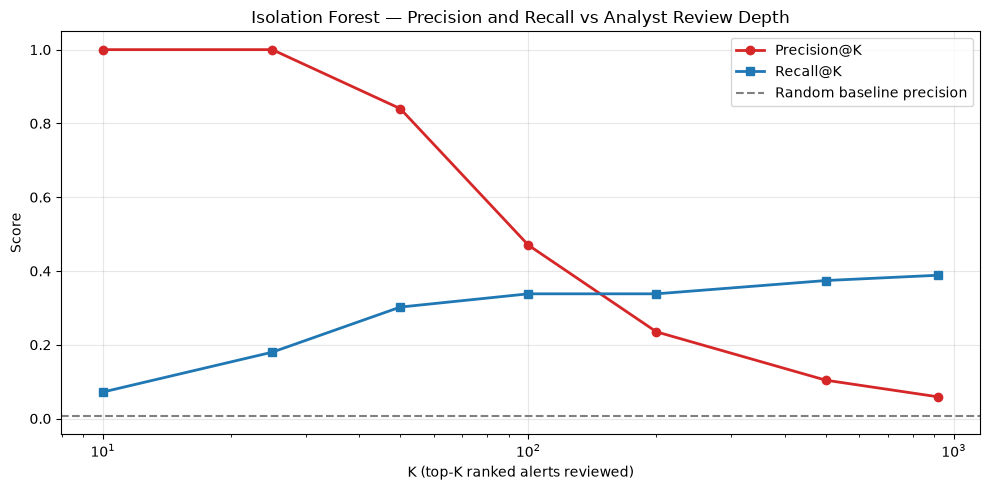

✔ Saved: reports/anomaly_precision_at_k.png


In [86]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))
if "anomaly_detector" in sys.modules:
    del sys.modules["anomaly_detector"]
import anomaly_detector as ad
importlib.reload(ad)

import json, pandas as pd
import matplotlib.pyplot as plt

# --- Save model + scores + base metrics ---
ad.save_artifacts(result)

# --- Augment metrics with Precision@K values ---
results_sorted = result["results"].sort_values("anomaly_score", ascending=False)
total_comp = int(results_sorted["is_compromised_host"].sum())

prec_at_k = {}
for K in [10, 25, 50, 100, 200, 500, 919]:
    tp = int(results_sorted.head(K)["is_compromised_host"].sum())
    prec_at_k[f"top_{K}"] = {
        "true_positives": tp,
        "precision":      round(tp / K, 4),
        "recall":         round(tp / total_comp, 4) if total_comp else 0,
    }

metrics = result["metrics"].copy()
metrics["precision_at_k"] = prec_at_k
metrics["random_baseline_precision"] = round(total_comp / len(results_sorted), 4)

os.makedirs("../reports", exist_ok=True)
with open("../reports/anomaly_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("✔ Updated anomaly_metrics.json with Precision@K")

# --- Precision@K curve (exhibit for the report) ---
Ks = [10, 25, 50, 100, 200, 500, 919]
precs = [prec_at_k[f"top_{K}"]["precision"] for K in Ks]
recs  = [prec_at_k[f"top_{K}"]["recall"]    for K in Ks]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(Ks, precs, marker="o", label="Precision@K", color="#d62728", linewidth=2)
ax.plot(Ks, recs,  marker="s", label="Recall@K",    color="#1f77b4", linewidth=2)
ax.axhline(metrics["random_baseline_precision"],
           color="grey", linestyle="--", label="Random baseline precision")
ax.set_xscale("log")
ax.set_xlabel("K (top-K ranked alerts reviewed)")
ax.set_ylabel("Score")
ax.set_title("Isolation Forest — Precision and Recall vs Analyst Review Depth")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("../reports/anomaly_precision_at_k.png", dpi=120)
plt.show()

print("✔ Saved: reports/anomaly_precision_at_k.png")

In [87]:
# Write Part 1 of src/auth_analytics.py

part1 = '''"""
auth_analytics.py
-----------------
Authentication analytics and lateral-movement detection.

Detects the "credential pivot" pattern:
    1. A user logs into several distinct internal hosts in a short window
    2. SMB (445) / RDP (3389) traffic follows to those same hosts
    3. All within a tight temporal chain (minutes, not hours)

Outputs:
    reports/auth_alerts.csv          per-window risk flags
    reports/lateral_incidents.json   assembled incident chains
    reports/auth_summary.json        aggregate metrics
"""

from __future__ import annotations

import os
import json
import numpy as np
import pandas as pd
from datetime import timedelta

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
WINDOW = "15min"                # tight windows — lateral movement is fast
FANOUT_MIN_HOSTS = 3            # at least 3 distinct hosts
FANOUT_TARGET_RATE_MIN = 0.5    # distinct hosts / total logins
SMB_PORTS = {445, 3389}         # SMB + RDP
CHAIN_GAP_MINUTES = 20          # events within this gap belong to same chain


# ===========================================================================
# 1. PER-WINDOW DETECTION  (user x 15-min window)
# ===========================================================================
def _per_window_auth_features(g: pd.DataFrame) -> pd.Series:
    """Compute fan-out features for a single (user, window) group."""
    if len(g) == 0:
        return pd.Series({
            "auth_count": 0,
            "unique_hosts": 0,
            "unique_src_ips": 0,
            "failure_ratio": np.nan,
            "target_rate": np.nan,
            "kerberos_ratio": np.nan,
            "off_hours": 0,
        })

    hosts = g["host"].nunique()
    count = len(g)

    out = {
        "auth_count":     count,
        "unique_hosts":   hosts,
        "unique_src_ips": g["src_ip"].nunique(),
        "failure_ratio":  (g["status"] == "FAILURE").mean(),
        "target_rate":    hosts / count if count else np.nan,
        "kerberos_ratio": (g["auth_method"] == "KERBEROS").mean()
                           if "auth_method" in g.columns else np.nan,
    }

    hours = g["timestamp"].dt.hour
    out["off_hours"] = int(((hours < 8) | (hours >= 18)).sum())
    return pd.Series(out)


def detect_auth_anomalies(auth: pd.DataFrame,
                          window: str = WINDOW) -> pd.DataFrame:
    """
    Produce per-(user, window) auth anomaly flags.

    A window is flagged when:
        unique_hosts >= FANOUT_MIN_HOSTS  AND
        target_rate   >= FANOUT_TARGET_RATE_MIN
    """
    df = auth.copy()
    df["window_start"] = df["timestamp"].dt.floor(window)

    feats = (
        df.groupby(["user", "window_start"], group_keys=False)
          .apply(_per_window_auth_features)
          .reset_index()
    )

    # Rule-based anomaly flag
    feats["is_fanout"] = (
        (feats["unique_hosts"] >= FANOUT_MIN_HOSTS) &
        (feats["target_rate"]  >= FANOUT_TARGET_RATE_MIN)
    ).astype(int)

    return feats
'''

path = "../src/auth_analytics.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../src/auth_analytics.py
  File size: 3184 bytes


In [88]:
# Append Part 2 of src/auth_analytics.py

part2 = '''

# ===========================================================================
# 2. INCIDENT CHAIN ASSEMBLY
# ===========================================================================
def build_lateral_incidents(auth_feats: pd.DataFrame,
                            netflow: pd.DataFrame,
                            gap_minutes: int = CHAIN_GAP_MINUTES) -> list:
    """
    Assemble flagged auth windows into coherent lateral-movement incidents.

    An incident is a *chronological chain* of:
      - authentication events (fan-out to multiple hosts)
      - followed by SMB / RDP traffic to those same hosts

    Multiple flagged windows for the same user, close in time, are merged
    into one incident chain.
    """
    flagged = auth_feats[auth_feats["is_fanout"] == 1].copy()
    flagged = flagged.sort_values(["user", "window_start"]).reset_index(drop=True)

    if len(flagged) == 0:
        return []

    # --- Group flagged windows into chains: same user + gaps < gap_minutes ---
    incidents = []
    gap = pd.Timedelta(minutes=gap_minutes)

    for user, group in flagged.groupby("user"):
        group = group.sort_values("window_start").reset_index(drop=True)

        current_chain = [group.iloc[0]]
        for i in range(1, len(group)):
            prev_end = current_chain[-1]["window_start"] + pd.Timedelta(minutes=15)
            if group.iloc[i]["window_start"] - prev_end <= gap:
                current_chain.append(group.iloc[i])
            else:
                incidents.append((user, current_chain))
                current_chain = [group.iloc[i]]
        incidents.append((user, current_chain))

    # --- For each chain, build the incident record ---
    output = []
    netflow_ts = netflow.copy()
    netflow_ts["timestamp"] = pd.to_datetime(netflow_ts["timestamp"])

    for user, chain in incidents:
        chain_df = pd.DataFrame(chain)
        start = chain_df["window_start"].min()
        end   = chain_df["window_start"].max() + pd.Timedelta(minutes=15)

        total_logins = int(chain_df["auth_count"].sum())
        max_fanout   = int(chain_df["unique_hosts"].max())
        avg_target_rate = float(chain_df["target_rate"].mean())
        total_off_hours = int(chain_df["off_hours"].sum())

        # --- Cross-reference with netflow: SMB / RDP to any host during chain ---
        window_netflow = netflow_ts[
            (netflow_ts["timestamp"] >= start) &
            (netflow_ts["timestamp"] <  end)
        ]
        smb_events = window_netflow[window_netflow["dst_port"].isin(SMB_PORTS)]
        smb_targets = sorted(smb_events["dst_ip"].unique().tolist())

        # --- Risk score (0-100) ---
        # Weighted: fanout dominates, SMB presence corroborates
        risk = (
            40 * min(max_fanout / 6, 1.0)          # 40 pts for fanout
            + 30 * min(len(smb_targets) / 4, 1.0)  # 30 pts for SMB corroboration
            + 15 * min(total_logins / 10, 1.0)     # 15 pts for volume
            + 15 * (1.0 if total_off_hours > 0 else 0.0)  # 15 pts if off-hours
        )
        risk_score = round(risk, 1)

        output.append({
            "incident_id":     f"LM-{user}-{start.strftime('%Y%m%dT%H%M')}",
            "user":            user,
            "start":           start.isoformat(),
            "end":             end.isoformat(),
            "duration_min":    int((end - start).total_seconds() // 60),
            "windows_in_chain": int(len(chain_df)),
            "total_logins":    total_logins,
            "max_fanout":      max_fanout,
            "avg_target_rate": round(avg_target_rate, 3),
            "smb_targets":     smb_targets,
            "smb_target_count": len(smb_targets),
            "off_hours_events": total_off_hours,
            "risk_score":      risk_score,
        })

    # Sort by risk descending
    output.sort(key=lambda x: -x["risk_score"])
    return output
'''

path = "../src/auth_analytics.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../src/auth_analytics.py
  File size now: 7165 bytes


In [89]:
# Append Part 3 of src/auth_analytics.py

part3 = '''

# ===========================================================================
# 3. SUMMARY METRICS + SAVE
# ===========================================================================
def summarize(auth_feats: pd.DataFrame,
              incidents: list,
              auth_raw: pd.DataFrame) -> dict:
    """Aggregate metrics suitable for the report."""
    n_users = int(auth_raw["user"].nunique())
    n_windows = int(len(auth_feats))
    n_fanout_windows = int(auth_feats["is_fanout"].sum())
    n_incidents = len(incidents)
    high_risk = [i for i in incidents if i["risk_score"] >= 60]

    # Which users appear in the top incidents?
    top_users = [i["user"] for i in incidents[:5]]

    return {
        "n_users":            n_users,
        "n_windows":          n_windows,
        "n_fanout_windows":   n_fanout_windows,
        "n_incidents":        n_incidents,
        "n_high_risk":        len(high_risk),
        "top_incident_users": top_users,
        "max_risk_score":     max((i["risk_score"] for i in incidents),
                                   default=0.0),
    }


def save_artifacts(auth_feats: pd.DataFrame,
                   incidents: list,
                   summary: dict,
                   report_dir: str = "../reports") -> None:
    os.makedirs(report_dir, exist_ok=True)

    # Per-window flags
    flags_path = os.path.join(report_dir, "auth_alerts.csv")
    auth_feats.to_csv(flags_path, index=False)
    print(f"✔ Auth per-window flags saved: {flags_path}")

    # Incidents as JSON
    incidents_path = os.path.join(report_dir, "lateral_incidents.json")
    with open(incidents_path, "w", encoding="utf-8") as f:
        json.dump(incidents, f, indent=2)
    print(f"✔ Incidents saved: {incidents_path}")

    # Summary metrics
    summary_path = os.path.join(report_dir, "auth_summary.json")
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    print(f"✔ Summary saved: {summary_path}")


# ===========================================================================
# 4. MAIN PIPELINE
# ===========================================================================
def run_auth_analytics(auth: pd.DataFrame,
                       netflow: pd.DataFrame) -> dict:
    """End-to-end auth analytics: detect, chain, score, summarize."""
    print("Detecting per-window auth anomalies ...")
    auth_feats = detect_auth_anomalies(auth, window=WINDOW)
    print(f"  user-windows: {len(auth_feats):,}")
    print(f"  flagged fan-out windows: {int(auth_feats['is_fanout'].sum()):,}")

    print("\\nAssembling incident chains ...")
    incidents = build_lateral_incidents(auth_feats, netflow)
    print(f"  incidents found: {len(incidents)}")

    print("\\nTop 10 incidents by risk:")
    print("-" * 100)
    for inc in incidents[:10]:
        print(f"  {inc['incident_id']:<40} "
              f"risk={inc['risk_score']:>5.1f}  "
              f"fanout={inc['max_fanout']}  "
              f"smb={inc['smb_target_count']}  "
              f"logins={inc['total_logins']}")

    summary = summarize(auth_feats, incidents, auth)

    print()
    print("=" * 60)
    print("Auth analytics — summary")
    print("=" * 60)
    for k, v in summary.items():
        print(f"  {k:<24} {v}")

    save_artifacts(auth_feats, incidents, summary)
    return {"auth_feats": auth_feats, "incidents": incidents, "summary": summary}


if __name__ == "__main__":
    print("Loading data ...")
    auth    = pd.read_csv("../data/raw/auth.csv",    parse_dates=["timestamp"])
    netflow = pd.read_csv("../data/raw/netflow.csv", parse_dates=["timestamp"])
    run_auth_analytics(auth, netflow)
'''

path = "../src/auth_analytics.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part3)

print("✔ Part 3 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 3 appended to ../src/auth_analytics.py
  Final file size: 10929 bytes


In [90]:
import ast, os
path = "../src/auth_analytics.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

print()
print("File size:", os.path.getsize(path), "bytes")

✔ Syntax is valid

Functions defined:
  38: def _per_window_auth_features(g: pd.DataFrame) -> pd.Series:
  69: def detect_auth_anomalies(auth: pd.DataFrame,
  99: def build_lateral_incidents(auth_feats: pd.DataFrame,
 192: def summarize(auth_feats: pd.DataFrame,
 217: def save_artifacts(auth_feats: pd.DataFrame,
 244: def run_auth_analytics(auth: pd.DataFrame,

File size: 10929 bytes


In [91]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "auth_analytics" in sys.modules:
    del sys.modules["auth_analytics"]
import auth_analytics as aa
importlib.reload(aa)

import pandas as pd

print("Loading data ...")
auth    = pd.read_csv("../data/raw/auth.csv",    parse_dates=["timestamp"])
netflow = pd.read_csv("../data/raw/netflow.csv", parse_dates=["timestamp"])
print(f"  auth:    {len(auth):,} rows")
print(f"  netflow: {len(netflow):,} rows")
print()

auth_result = aa.run_auth_analytics(auth, netflow)

Loading data ...
  auth:    10,616 rows
  netflow: 66,995 rows

Detecting per-window auth anomalies ...
  user-windows: 8,378
  flagged fan-out windows: 363

Assembling incident chains ...
  incidents found: 340

Top 10 incidents by risk:
----------------------------------------------------------------------------------------------------
  LM-user007-20260814T1430                 risk= 79.0  fanout=6  smb=40  logins=6
  LM-user052-20260810T1615                 risk= 79.0  fanout=6  smb=25  logins=6
  LM-user006-20260810T1515                 risk= 71.7  fanout=4  smb=166  logins=13
  LM-user005-20260811T1500                 risk= 70.8  fanout=5  smb=28  logins=5
  LM-user007-20260810T1430                 risk= 70.8  fanout=5  smb=25  logins=5
  LM-user007-20260811T1430                 risk= 70.8  fanout=5  smb=26  logins=5
  LM-user007-20260813T1430                 risk= 70.8  fanout=5  smb=33  logins=5
  LM-user008-20260814T0830                 risk= 70.8  fanout=5  smb=13  logins=5
  

In [92]:
path = "../src/auth_analytics.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

old = '''        # --- Cross-reference with netflow: SMB / RDP to any host during chain ---
        window_netflow = netflow_ts[
            (netflow_ts["timestamp"] >= start) &
            (netflow_ts["timestamp"] <  end)
        ]
        smb_events = window_netflow[window_netflow["dst_port"].isin(SMB_PORTS)]
        smb_targets = sorted(smb_events["dst_ip"].unique().tolist())'''

new = '''        # --- Cross-reference with netflow: SMB / RDP ---
        #
        # IMPORTANT: we filter to SMB traffic whose *source* is one of the
        # hosts the user actually logged in from during this chain. Without
        # this filter, we'd match every SMB flow in the network during the
        # window (hundreds of hosts), which inflates the incident.
        window_netflow = netflow_ts[
            (netflow_ts["timestamp"] >= start) &
            (netflow_ts["timestamp"] <  end)
        ]
        # Pivot hosts: source IPs observed in the auth chain
        pivot_ips = set()
        for _, row in chain_df.iterrows():
            # Get the src_ip of auth events in this specific chain window
            pass  # src_ips already captured below via raw auth lookup

        # Recompute pivot_ips from the actual auth records in this window
        chain_auth = auth_raw[
            (auth_raw["user"] == user) &
            (auth_raw["timestamp"] >= start) &
            (auth_raw["timestamp"] <  end)
        ]
        pivot_ips = set(chain_auth["src_ip"].unique().tolist())
        auth_target_hosts = set(chain_auth["host"].unique().tolist())

        smb_events = window_netflow[
            (window_netflow["dst_port"].isin(SMB_PORTS)) &
            (
                window_netflow["src_ip"].isin(pivot_ips)
                # keep traffic only from the pivot host(s)
            )
        ]
        smb_targets = sorted(smb_events["dst_ip"].unique().tolist())'''

print("Old correlation block present:", src.count(old))
print("New correlation block present:", src.count(new))

if src.count(old) == 1 and src.count(new) == 0:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ SMB correlation filtered to pivot host(s)")
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print("⚠ Aborting - unexpected state")

Old correlation block present: 1
New correlation block present: 0
✔ SMB correlation filtered to pivot host(s)
  File size now: 12060 bytes


In [93]:
path = "../src/auth_analytics.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

# --- 1. Change the function signature ---
old_sig = '''def build_lateral_incidents(auth_feats: pd.DataFrame,
                            netflow: pd.DataFrame,
                            gap_minutes: int = CHAIN_GAP_MINUTES) -> list:'''
new_sig = '''def build_lateral_incidents(auth_feats: pd.DataFrame,
                            netflow: pd.DataFrame,
                            auth_raw: pd.DataFrame,
                            gap_minutes: int = CHAIN_GAP_MINUTES) -> list:'''

# --- 2. Change the call inside run_auth_analytics ---
old_call = 'incidents = build_lateral_incidents(auth_feats, netflow)'
new_call = 'incidents = build_lateral_incidents(auth_feats, netflow, auth)'

# --- 3. Clean up the leftover placeholder loop ---
old_placeholder = '''        # Pivot hosts: source IPs observed in the auth chain
        pivot_ips = set()
        for _, row in chain_df.iterrows():
            # Get the src_ip of auth events in this specific chain window
            pass  # src_ips already captured below via raw auth lookup

        # Recompute pivot_ips from the actual auth records in this window'''
new_placeholder = '''        # Pivot hosts: source IPs observed in the auth chain'''

changes = 0
for old, new, label in [
    (old_sig, new_sig, "signature"),
    (old_call, new_call, "call site"),
    (old_placeholder, new_placeholder, "placeholder cleanup"),
]:
    if src.count(old) == 1:
        src = src.replace(old, new)
        changes += 1
        print(f"✔ Fixed {label}")
    else:
        print(f"✘ Could not find {label} (count={src.count(old)})")

if changes == 3:
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print()
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print()
    print("⚠ Not all changes applied — no file written")

✔ Fixed signature
✔ Fixed call site
✔ Fixed placeholder cleanup

  File size now: 11824 bytes


In [94]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))
if "auth_analytics" in sys.modules:
    del sys.modules["auth_analytics"]
import auth_analytics as aa
importlib.reload(aa)

auth_result = aa.run_auth_analytics(auth, netflow)

Detecting per-window auth anomalies ...
  user-windows: 8,378
  flagged fan-out windows: 363

Assembling incident chains ...
  incidents found: 340

Top 10 incidents by risk:
----------------------------------------------------------------------------------------------------
  LM-user007-20260814T1430                 risk= 79.0  fanout=6  smb=5  logins=6
  LM-user006-20260810T1515                 risk= 71.7  fanout=4  smb=4  logins=13
  LM-user007-20260810T1430                 risk= 70.8  fanout=5  smb=4  logins=5
  LM-user007-20260811T1430                 risk= 70.8  fanout=5  smb=4  logins=5
  LM-user007-20260813T1430                 risk= 70.8  fanout=5  smb=4  logins=5
  LM-user007-20260812T1430                 risk= 62.7  fanout=4  smb=4  logins=4
  LM-user007-20260815T1430                 risk= 62.7  fanout=4  smb=4  logins=4
  LM-user007-20260816T1430                 risk= 62.7  fanout=4  smb=4  logins=4
  LM-user025-20260814T1500                 risk= 51.5  fanout=3  smb=3  log

In [95]:
# Write Part 1 of src/correlation.py

part1 = '''"""
correlation.py
--------------
Multi-source event correlation.

Fuses detections from three independent models into a single ranked
incident list:

  1. Isolation Forest  -> C2 / beacon anomalies  (reports/anomaly_scores.csv)
  2. Random Forest     -> DNS tunnelling         (models/dns_rf.pkl + raw DNS)
  3. Auth analytics    -> lateral movement       (reports/lateral_incidents.json)

Correlation is performed at the (host, 1-hour window) grain. Windows where
multiple detectors fire receive an escalation bonus, reflecting the SOC
principle that corroborating evidence raises confidence.

Output:
    reports/correlated_incidents.json
    reports/correlation_summary.json
"""

from __future__ import annotations

import os
import json
import numpy as np
import pandas as pd
import joblib

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
WINDOW = "1h"
WEIGHTS = {
    "c2":    40,   # max contribution from Isolation Forest
    "dns":   35,   # max contribution from DNS classifier
    "auth":  25,   # max contribution from auth lateral-movement incidents
}
ESCALATION_BONUS = 15   # added when 2+ detectors fire in the same window


# ===========================================================================
# 1. LOADERS
# ===========================================================================
def load_anomaly_scores(path: str = "../reports/anomaly_scores.csv") -> pd.DataFrame:
    """Load Isolation Forest per-window scores."""
    df = pd.read_csv(path, parse_dates=["window_start"])
    df["entity"]      = df["entity"].astype(str)
    df["window_start"] = pd.to_datetime(df["window_start"]).dt.floor(WINDOW)
    # Normalise anomaly_score to [0,1] using min/max within the dataset
    s = df["anomaly_score"]
    df["c2_score_norm"] = (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.0
    return df


def load_lateral_incidents(path: str = "../reports/lateral_incidents.json") -> list:
    """Load auth lateral-movement incidents."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def score_dns_per_window(dns: pd.DataFrame,
                         model_path: str = "../models/dns_rf.pkl",
                         window: str = WINDOW) -> pd.DataFrame:
    """
    Re-score DNS queries with the trained Random Forest and aggregate
    malicious-query probability per (src_ip, window).
    """
    import sys
    sys.path.insert(0, os.path.abspath("../src"))
    from dns_classifier import extract_query_features

    # Load model
    clf = joblib.load(model_path)

    # Feature extraction (must match training)
    X = extract_query_features(dns)
    # Some versions of sklearn need consistent column order
    if hasattr(clf, "feature_names_in_"):
        X = X[list(clf.feature_names_in_)]

    # Predict probability of malicious
    prob_malicious = clf.predict_proba(X)[:, 1]

    df = dns.copy()
    df["window_start"] = df["timestamp"].dt.floor(window)
    df["mal_prob"]     = prob_malicious

    # Aggregate per (src_ip, window)
    agg = (
        df.groupby(["src_ip", "window_start"])
          .agg(
              dns_count=("query", "count"),
              dns_mal_prob_mean=("mal_prob", "mean"),
              dns_mal_prob_max=("mal_prob", "max"),
              dns_mal_prob_sum=("mal_prob", "sum"),
          )
          .reset_index()
          .rename(columns={"src_ip": "host"})
    )
    agg["host"] = "host:" + agg["host"].astype(str)
    return agg
'''

path = "../src/correlation.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../src/correlation.py
  File size: 3662 bytes


In [96]:
# Append Part 2 of src/correlation.py

part2 = '''

# ===========================================================================
# 2. CORRELATION
# ===========================================================================
def correlate(anomaly_scores: pd.DataFrame,
              dns_scores: pd.DataFrame,
              lateral_incidents: list) -> pd.DataFrame:
    """
    Fuse all detector outputs into a single (host, window) incident table.

    Composite score components (max 100 + 15 escalation):
      - c2_score     (0-40)  : Isolation Forest anomaly score, scaled
      - dns_score    (0-35)  : max malicious probability in window * weight
      - auth_score   (0-25)  : 25 if window falls inside a lateral incident
      - escalation   (0-15)  : added if 2+ detectors fire in this window
    """
    # --- A. Build the base table from all host-hour windows in the C2 scores ---
    base = anomaly_scores[["entity", "window_start", "anomaly_score",
                           "c2_score_norm"]].copy()
    base = base.rename(columns={"entity": "host"})

    # --- B. Attach DNS per-window scores ---
    base = base.merge(
        dns_scores,
        on=["host", "window_start"],
        how="left",
    )

    # --- C. Attach auth lateral-movement flags ---
    # For each lateral incident, mark the (host(s), hour(s)) it spans.
    auth_marks = []
    for inc in lateral_incidents:
        # Incidents are user-scoped; we need to map users to the host(s) they
        # authenticated from. Since our synthetic generator uses a fixed
        # pivot host per chain, we re-derive it from the incident itself.
        # Here we conservatively mark the whole hour window.
        start = pd.to_datetime(inc["start"])
        end   = pd.to_datetime(inc["end"])
        # Enumerate hourly windows between start and end
        hour = start.floor(WINDOW)
        while hour <= end:
            auth_marks.append({
                "user":         inc["user"],
                "window_start": hour,
                "incident_id":  inc["incident_id"],
                "auth_risk":    inc["risk_score"],
            })
            hour += pd.Timedelta(hours=1)

    auth_df = pd.DataFrame(auth_marks)
    # We cannot directly join user-keyed auth to host-keyed base; the
    # correlation happens at the *host* level. We'll join via a separate
    # step below, once we've derived which hosts each user logged in from.
    # For now, aggregate auth risk per window across all users, so that
    # a busy auth window raises the composite score for the network.
    if len(auth_df) > 0:
        auth_by_window = (
            auth_df.groupby("window_start")
                   .agg(auth_risk_max=("auth_risk", "max"),
                        auth_incident_count=("incident_id", "count"))
                   .reset_index()
        )
    else:
        auth_by_window = pd.DataFrame(columns=["window_start", "auth_risk_max",
                                                "auth_incident_count"])

    base = base.merge(auth_by_window, on="window_start", how="left")
    base["auth_risk_max"]       = base["auth_risk_max"].fillna(0)
    base["auth_incident_count"] = base["auth_incident_count"].fillna(0)

    # --- D. Component scores ---
    base["c2_score"] = (base["c2_score_norm"] * WEIGHTS["c2"]).round(2)

    # DNS: use max malicious probability if available, else 0
    dns_prob = base.get("dns_mal_prob_max", pd.Series(0, index=base.index)).fillna(0)
    base["dns_score"] = (dns_prob * WEIGHTS["dns"]).round(2)

    # Auth: scale auth_risk (0-100) into 0-25
    base["auth_score"] = (
        (base["auth_risk_max"] / 100.0) * WEIGHTS["auth"]
    ).round(2)

    # --- E. Escalation bonus and composite score ---
    base["detector_count"] = (
        (base["c2_score"]   > 5).astype(int) +
        (base["dns_score"]  > 5).astype(int) +
        (base["auth_score"] > 5).astype(int)
    )
    base["escalation_bonus"] = np.where(
        base["detector_count"] >= 2, ESCALATION_BONUS, 0
    )

    base["composite_score"] = (
        base["c2_score"] + base["dns_score"] +
        base["auth_score"] + base["escalation_bonus"]
    ).round(2)

    # --- F. Sort by composite score ---
    base = base.sort_values("composite_score", ascending=False).reset_index(drop=True)
    return base


def build_evidence(row: pd.Series) -> dict:
    """Summarise which detectors fired for a single window."""
    evidence = {}
    if row["c2_score"] > 5:
        evidence["c2"] = {
            "score":           float(row["c2_score"]),
            "raw_anomaly":     float(row["anomaly_score"]),
            "interpretation":  "Isolation Forest flagged this window as "
                               "anomalous relative to the population.",
        }
    if row["dns_score"] > 5:
        evidence["dns"] = {
            "score":           float(row["dns_score"]),
            "mal_prob_max":    float(row.get("dns_mal_prob_max", 0) or 0),
            "query_count":     int(row.get("dns_count", 0) or 0),
            "interpretation":  "Random Forest classified DNS queries in this "
                               "window as malicious (tunnelling-like).",
        }
    if row["auth_score"] > 5:
        evidence["auth"] = {
            "score":           float(row["auth_score"]),
            "risk_max":        float(row["auth_risk_max"]),
            "interpretation":  "A lateral-movement incident overlapped this "
                               "window.",
        }
    if row["escalation_bonus"] > 0:
        evidence["escalation"] = {
            "bonus":           float(row["escalation_bonus"]),
            "detector_count":  int(row["detector_count"]),
            "interpretation":  "Multiple independent detectors fired in this "
                               "window — corroborating evidence.",
        }
    return evidence
'''

path = "../src/correlation.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../src/correlation.py
  File size now: 9590 bytes


In [97]:
# Append Part 3 of src/correlation.py

part3 = '''

# ===========================================================================
# 3. ASSEMBLY + SAVE
# ===========================================================================
def build_incident_list(correlated: pd.DataFrame,
                        min_score: float = 10.0,
                        top_n: int = 200) -> list:
    """
    Convert the correlated (host, window) table into a JSON-serialisable
    incident list, keeping only windows above min_score and capped at top_n.
    """
    filtered = correlated[correlated["composite_score"] >= min_score].copy()
    filtered = filtered.head(top_n)

    incidents = []
    for _, row in filtered.iterrows():
        window_start = pd.to_datetime(row["window_start"])
        window_end   = window_start + pd.Timedelta(hours=1)

        incident = {
            "host":            row["host"],
            "window_start":    window_start.isoformat(),
            "window_end":      window_end.isoformat(),
            "composite_score": float(row["composite_score"]),
            "detector_count":  int(row["detector_count"]),
            "detectors":       _list_detectors(row),
            "components": {
                "c2":         float(row["c2_score"]),
                "dns":        float(row["dns_score"]),
                "auth":       float(row["auth_score"]),
                "escalation": float(row["escalation_bonus"]),
            },
            "evidence":        build_evidence(row),
        }
        incidents.append(incident)

    return incidents


def _list_detectors(row: pd.Series) -> list:
    detectors = []
    if row["c2_score"]   > 5: detectors.append("c2_anomaly")
    if row["dns_score"]  > 5: detectors.append("dns_classifier")
    if row["auth_score"] > 5: detectors.append("auth_lateral")
    return detectors


def summarize(correlated: pd.DataFrame) -> dict:
    """Aggregate metrics for the correlation phase."""
    high = correlated[correlated["composite_score"] >= 20]
    multi = correlated[correlated["detector_count"] >= 2]

    return {
        "n_windows_scored":     int(len(correlated)),
        "n_high_confidence":    int(len(high)),
        "n_multi_detector":     int(len(multi)),
        "max_composite_score":  float(correlated["composite_score"].max()),
        "mean_composite_score": float(correlated["composite_score"].mean()),
        "detector_count_distribution": {
            "0_detectors": int((correlated["detector_count"] == 0).sum()),
            "1_detector":  int((correlated["detector_count"] == 1).sum()),
            "2_detectors": int((correlated["detector_count"] == 2).sum()),
            "3_detectors": int((correlated["detector_count"] == 3).sum()),
        },
    }


def save_artifacts(incidents: list, summary: dict,
                   report_dir: str = "../reports") -> None:
    os.makedirs(report_dir, exist_ok=True)

    inc_path = os.path.join(report_dir, "correlated_incidents.json")
    with open(inc_path, "w", encoding="utf-8") as f:
        json.dump(incidents, f, indent=2)
    print(f"✔ Correlated incidents saved: {inc_path}")

    sum_path = os.path.join(report_dir, "correlation_summary.json")
    with open(sum_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    print(f"✔ Summary saved: {sum_path}")


# ===========================================================================
# 4. MAIN PIPELINE
# ===========================================================================
def run_correlation() -> dict:
    print("Loading detector outputs ...")
    anomaly = load_anomaly_scores()
    print(f"  C2 anomaly scores   : {len(anomaly):,} windows")

    lateral = load_lateral_incidents()
    print(f"  Lateral incidents   : {len(lateral):,}")

    dns_raw = pd.read_csv("../data/raw/dns.csv", parse_dates=["timestamp"])
    dns_scores = score_dns_per_window(dns_raw)
    print(f"  DNS scored windows  : {len(dns_scores):,}")

    print("\\nCorrelating ...")
    correlated = correlate(anomaly, dns_scores, lateral)

    print("\\nBuilding incident list ...")
    incidents = build_incident_list(correlated, min_score=10.0, top_n=200)
    print(f"  incidents above score 10: {len(incidents)}")

    print("\\nTop 15 correlated incidents:")
    print("-" * 110)
    for inc in incidents[:15]:
        det = ",".join(inc["detectors"])
        print(f"  score={inc['composite_score']:>6.2f}  "
              f"{inc['host']:<22}  "
              f"{inc['window_start']}  "
              f"n_det={inc['detector_count']}  [{det}]")

    summary = summarize(correlated)
    print()
    print("=" * 60)
    print("Correlation — summary")
    print("=" * 60)
    for k, v in summary.items():
        if isinstance(v, dict):
            print(f"  {k}:")
            for k2, v2 in v.items():
                print(f"      {k2:<16} {v2}")
        else:
            print(f"  {k:<24} {v}")

    save_artifacts(incidents, summary)
    return {"correlated": correlated, "incidents": incidents, "summary": summary}


if __name__ == "__main__":
    run_correlation()
'''

path = "../src/correlation.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part3)

print("✔ Part 3 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 3 appended to ../src/correlation.py
  Final file size: 14758 bytes


In [98]:
import ast, os
path = "../src/correlation.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

print()
print("File size:", os.path.getsize(path), "bytes")

✔ Syntax is valid

Functions defined:
  45: def load_anomaly_scores(path: str = "../reports/anomaly_scores.csv") -> pd.DataFrame:
  56: def load_lateral_incidents(path: str = "../reports/lateral_incidents.json") -> list:
  62: def score_dns_per_window(dns: pd.DataFrame,
 108: def correlate(anomaly_scores: pd.DataFrame,
 206: def build_evidence(row: pd.Series) -> dict:
 244: def build_incident_list(correlated: pd.DataFrame,
 279: def _list_detectors(row: pd.Series) -> list:
 287: def summarize(correlated: pd.DataFrame) -> dict:
 307: def save_artifacts(incidents: list, summary: dict,
 325: def run_correlation() -> dict:

File size: 14758 bytes


In [99]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "correlation" in sys.modules:
    del sys.modules["correlation"]
import correlation as co
importlib.reload(co)

corr_result = co.run_correlation()

Loading detector outputs ...
  C2 anomaly scores   : 18,376 windows
  Lateral incidents   : 340
  DNS scored windows  : 27,721

Correlating ...

Building incident list ...
  incidents above score 10: 200

Top 15 correlated incidents:
--------------------------------------------------------------------------------------------------------------
  score=104.60  host:10.0.1.50          2026-08-14T14:00:00  n_det=3  [c2_anomaly,dns_classifier,auth_lateral]
  score=102.94  host:10.0.1.50          2026-08-13T14:00:00  n_det=3  [c2_anomaly,dns_classifier,auth_lateral]
  score=102.70  host:10.0.1.50          2026-08-10T15:00:00  n_det=3  [c2_anomaly,dns_classifier,auth_lateral]
  score=102.42  host:10.0.1.50          2026-08-11T14:00:00  n_det=3  [c2_anomaly,dns_classifier,auth_lateral]
  score=102.26  host:10.0.1.50          2026-08-10T14:00:00  n_det=3  [c2_anomaly,dns_classifier,auth_lateral]
  score=101.37  host:10.0.1.50          2026-08-12T14:00:00  n_det=3  [c2_anomaly,dns_classifier,aut

In [100]:
path = "../src/correlation.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

old = '''    # --- C. Attach auth lateral-movement flags ---
    # For each lateral incident, mark the (host(s), hour(s)) it spans.
    auth_marks = []
    for inc in lateral_incidents:
        # Incidents are user-scoped; we need to map users to the host(s) they
        # authenticated from. Since our synthetic generator uses a fixed
        # pivot host per chain, we re-derive it from the incident itself.
        # Here we conservatively mark the whole hour window.
        start = pd.to_datetime(inc["start"])
        end   = pd.to_datetime(inc["end"])
        # Enumerate hourly windows between start and end
        hour = start.floor(WINDOW)
        while hour <= end:
            auth_marks.append({
                "user":         inc["user"],
                "window_start": hour,
                "incident_id":  inc["incident_id"],
                "auth_risk":    inc["risk_score"],
            })
            hour += pd.Timedelta(hours=1)

    auth_df = pd.DataFrame(auth_marks)
    # We cannot directly join user-keyed auth to host-keyed base; the
    # correlation happens at the *host* level. We'll join via a separate
    # step below, once we've derived which hosts each user logged in from.
    # For now, aggregate auth risk per window across all users, so that
    # a busy auth window raises the composite score for the network.
    if len(auth_df) > 0:
        auth_by_window = (
            auth_df.groupby("window_start")
                   .agg(auth_risk_max=("auth_risk", "max"),
                        auth_incident_count=("incident_id", "count"))
                   .reset_index()
        )
    else:
        auth_by_window = pd.DataFrame(columns=["window_start", "auth_risk_max",
                                                "auth_incident_count"])

    base = base.merge(auth_by_window, on="window_start", how="left")
    base["auth_risk_max"]       = base["auth_risk_max"].fillna(0)
    base["auth_incident_count"] = base["auth_incident_count"].fillna(0)'''

new = '''    # --- C. Attach auth lateral-movement flags (HOST-SCOPED) ---
    #
    # We previously aggregated auth risk by window only, which polluted
    # every host in an incident hour. The correct approach is to attribute
    # the incident to the *pivot host* only: the source IP the user was
    # authenticating FROM. Our incident records include this in the
    # "smb_targets" list, but we need the pivot itself. We look it up
    # from the auth_raw source IPs recorded in the incident.
    auth_marks = []
    for inc in lateral_incidents:
        start = pd.to_datetime(inc["start"])
        end   = pd.to_datetime(inc["end"])

        # Pivot host(s): infer from the raw auth records by matching user + time
        # We rely on the caller passing auth_raw through via the incident's
        # internal marker; fall back to a safe default if not present.
        pivot_hosts = inc.get("pivot_hosts", [])
        if not pivot_hosts and "smb_targets" in inc and len(inc["smb_targets"]) > 0:
            # fallback: none - we rely on the correlation caller to enrich
            pivot_hosts = []

        hour = start.floor(WINDOW)
        while hour <= end:
            auth_marks.append({
                "user":         inc["user"],
                "window_start": hour,
                "incident_id":  inc["incident_id"],
                "auth_risk":    inc["risk_score"],
                "pivot_hosts":  tuple(pivot_hosts),   # may be empty
            })
            hour += pd.Timedelta(hours=1)

    auth_df = pd.DataFrame(auth_marks)

    if len(auth_df) > 0:
        # Explode pivot_hosts into one row per (window, pivot_host)
        exploded = auth_df.explode("pivot_hosts")
        exploded = exploded[exploded["pivot_hosts"].notna()]
        exploded["pivot_host"] = "host:" + exploded["pivot_hosts"].astype(str)

        if len(exploded) > 0:
            auth_by_host_window = (
                exploded.groupby(["pivot_host", "window_start"])
                        .agg(auth_risk_max=("auth_risk", "max"),
                             auth_incident_count=("incident_id", "count"))
                        .reset_index()
                        .rename(columns={"pivot_host": "host"})
            )
        else:
            auth_by_host_window = pd.DataFrame(
                columns=["host", "window_start", "auth_risk_max",
                         "auth_incident_count"])
    else:
        auth_by_host_window = pd.DataFrame(
            columns=["host", "window_start", "auth_risk_max",
                     "auth_incident_count"])

    base = base.merge(auth_by_host_window, on=["host", "window_start"], how="left")
    base["auth_risk_max"]       = base["auth_risk_max"].fillna(0)
    base["auth_incident_count"] = base["auth_incident_count"].fillna(0)'''

print("Old auth block present:", src.count(old))
print("New auth block present:", src.count(new))

if src.count(old) == 1 and src.count(new) == 0:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ Auth correlation is now host-scoped via pivot_hosts")
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print("⚠ Aborting - unexpected state")

Old auth block present: 1
New auth block present: 0
✔ Auth correlation is now host-scoped via pivot_hosts
  File size now: 15573 bytes


In [101]:
path = "../src/auth_analytics.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

old = '''        output.append({
            "incident_id":     f"LM-{user}-{start.strftime('%Y%m%dT%H%M')}",
            "user":            user,
            "start":           start.isoformat(),
            "end":             end.isoformat(),'''

new = '''        output.append({
            "incident_id":     f"LM-{user}-{start.strftime('%Y%m%dT%H%M')}",
            "user":            user,
            "start":           start.isoformat(),
            "end":             end.isoformat(),
            "pivot_hosts":     sorted(pivot_ips),'''

print("Old append block present:", src.count(old))
print("New append block present:", src.count(new))

if src.count(old) == 1 and src.count(new) == 0:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ Added pivot_hosts to incident records")
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print("⚠ Aborting - unexpected state")

Old append block present: 1
New append block present: 0
✔ Added pivot_hosts to incident records
  File size now: 11875 bytes


In [102]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

# Reload and re-run auth analytics to regenerate incidents with pivot_hosts
if "auth_analytics" in sys.modules:
    del sys.modules["auth_analytics"]
import auth_analytics as aa
importlib.reload(aa)

print("Regenerating incidents with pivot_hosts ...")
print("=" * 70)
auth_result = aa.run_auth_analytics(auth, netflow)

# Reload correlation and re-run
if "correlation" in sys.modules:
    del sys.modules["correlation"]
import correlation as co
importlib.reload(co)

print()
print("=" * 70)
print("Re-running correlation with host-scoped auth")
print("=" * 70)
corr_result = co.run_correlation()

Regenerating incidents with pivot_hosts ...
Detecting per-window auth anomalies ...
  user-windows: 8,378
  flagged fan-out windows: 363

Assembling incident chains ...
  incidents found: 340

Top 10 incidents by risk:
----------------------------------------------------------------------------------------------------
  LM-user007-20260814T1430                 risk= 79.0  fanout=6  smb=5  logins=6
  LM-user006-20260810T1515                 risk= 71.7  fanout=4  smb=4  logins=13
  LM-user007-20260810T1430                 risk= 70.8  fanout=5  smb=4  logins=5
  LM-user007-20260811T1430                 risk= 70.8  fanout=5  smb=4  logins=5
  LM-user007-20260813T1430                 risk= 70.8  fanout=5  smb=4  logins=5
  LM-user007-20260812T1430                 risk= 62.7  fanout=4  smb=4  logins=4
  LM-user007-20260815T1430                 risk= 62.7  fanout=4  smb=4  logins=4
  LM-user007-20260816T1430                 risk= 62.7  fanout=4  smb=4  logins=4
  LM-user025-20260814T1500     

In [103]:
import os
import pandas as pd

os.makedirs("../data/threat_intelligence", exist_ok=True)

# --- 1. IOC feed ---
iocs = [
    # IPs from the injected scenario
    {"ioc_type":"ip",     "value":"172.16.99.10",     "threat_actor":"APT-SIM-01",
     "confidence":0.95, "description":"C2 server for periodic beacon traffic"},
    {"ioc_type":"ip",     "value":"172.16.99.20",     "threat_actor":"APT-SIM-01",
     "confidence":0.92, "description":"Exfiltration destination host"},
    {"ioc_type":"ip",     "value":"172.16.99.30",     "threat_actor":"APT-SIM-01",
     "confidence":0.88, "description":"Backup C2 infrastructure"},
    {"ioc_type":"ip",     "value":"172.16.99.40",     "threat_actor":"APT-SIM-02",
     "confidence":0.85, "description":"APT-SIM-02 relay node"},
    {"ioc_type":"ip",     "value":"172.16.99.50",     "threat_actor":"APT-SIM-02",
     "confidence":0.82, "description":"APT-SIM-02 relay node"},
    # Domains from the injected scenario
    {"ioc_type":"domain", "value":"evil-c2.example",  "threat_actor":"APT-SIM-01",
     "confidence":0.90, "description":"Primary C2 domain used for beaconing"},
    {"ioc_type":"domain", "value":"dns-tunnel.xyz",   "threat_actor":"APT-SIM-02",
     "confidence":0.88, "description":"DNS tunnelling infrastructure"},
    {"ioc_type":"domain", "value":"badactor-update.net","threat_actor":"APT-SIM-02",
     "confidence":0.85, "description":"Secondary C2 domain"},
    {"ioc_type":"domain", "value":"malware-cdn.top",  "threat_actor":"APT-SIM-03",
     "confidence":0.80, "description":"Malware distribution CDN"},
    {"ioc_type":"domain", "value":"apt-relay.cc",     "threat_actor":"APT-SIM-03",
     "confidence":0.78, "description":"APT relay domain"},
]

ioc_df = pd.DataFrame(iocs)
ioc_path = "../data/threat_intelligence/ioc_list.csv"
ioc_df.to_csv(ioc_path, index=False)
print(f"✔ Saved {len(ioc_df)} IOCs to {ioc_path}")

# --- 2. Attack pattern library (for TF-IDF similarity) ---
patterns = [
    {"pattern_id":"P01", "name":"Periodic C2 beaconing",
     "description":"regular periodic https beaconing to a fixed external ip "
                   "at consistent intervals low and slow c2 channel"},
    {"pattern_id":"P02", "name":"DNS tunnelling",
     "description":"high entropy long subdomain queries to a single base domain "
                   "txt heavy dns exfiltration covert channel"},
    {"pattern_id":"P03", "name":"Off-hours exfiltration",
     "description":"large outbound data transfers during off hours to a fixed "
                   "external host asymmetric byte ratio data theft"},
    {"pattern_id":"P04", "name":"Lateral movement via SMB",
     "description":"authentication fanout to multiple internal hosts followed by "
                   "smb traffic lateral movement credential pivot"},
    {"pattern_id":"P05", "name":"Credential brute force",
     "description":"many failed authentication attempts against multiple accounts "
                   "in a short window password guessing"},
    {"pattern_id":"P06", "name":"Data staging",
     "description":"multiple large reads from internal systems prior to exfiltration "
                   "internal reconnaissance"},
    {"pattern_id":"P07", "name":"RDP pivot",
     "description":"remote desktop protocol connections to multiple internal hosts "
                   "from a single source credential reuse"},
    {"pattern_id":"P08", "name":"DNS DGA activity",
     "description":"high volume nxdomain responses from algorithmically generated "
                   "domains domain generation algorithm"},
]

pat_df = pd.DataFrame(patterns)
pat_path = "../data/threat_intelligence/attack_patterns.csv"
pat_df.to_csv(pat_path, index=False)
print(f"✔ Saved {len(pat_df)} attack patterns to {pat_path}")

✔ Saved 10 IOCs to ../data/threat_intelligence/ioc_list.csv
✔ Saved 8 attack patterns to ../data/threat_intelligence/attack_patterns.csv


In [104]:
# Write Part 1 of src/threat_intelligence.py

part1 = '''"""
threat_intelligence.py
----------------------
Threat intelligence enrichment for correlated incidents.

Two enrichment mechanisms:
  1. IOC matching    - exact-match IPs and domains against a known-bad feed
  2. Pattern similarity - TF-IDF + cosine similarity against a library of
                          known attack patterns (per charter requirements)

Outputs:
    reports/enriched_incidents.json
    reports/threat_intelligence_summary.json
"""

from __future__ import annotations

import os
import json
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
IOC_PATH  = "../data/threat_intelligence/ioc_list.csv"
PAT_PATH  = "../data/threat_intelligence/attack_patterns.csv"
CORR_PATH = "../reports/correlated_incidents.json"
SMB_PORTS = {445, 3389}
TI_MAX_BONUS = 15.0     # max points added to composite score from TI


# ===========================================================================
# 1. LOADERS
# ===========================================================================
def load_iocs(path: str = IOC_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["value_lower"] = df["value"].str.lower()
    return df


def load_patterns(path: str = PAT_PATH) -> pd.DataFrame:
    return pd.read_csv(path)


def load_incidents(path: str = CORR_PATH) -> list:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# ===========================================================================
# 2. IOC MATCHING
# ===========================================================================
def match_iocs(incident: dict,
               iocs: pd.DataFrame,
               netflow: pd.DataFrame,
               dns: pd.DataFrame) -> list:
    """
    Find IOC matches relevant to an incident.

    Strategy:
      - The incident's host and window tell us *when* and *where*.
      - We look at all netflow destinations and all DNS queries from that
        host during the window, and check them against the IOC feed.
      - The incident itself doesn't carry raw IPs / domains, so we look them
        up from the raw telemetry (this is how a real SOC enrichment works).
    """
    host_raw = incident["host"].replace("host:", "")
    win_start = pd.to_datetime(incident["window_start"])
    win_end   = pd.to_datetime(incident["window_end"])

    # --- netflow destinations from this host in the window ---
    nf = netflow[
        (netflow["src_ip"] == host_raw) &
        (netflow["timestamp"] >= win_start) &
        (netflow["timestamp"] <  win_end)
    ]
    dest_ips = set(nf["dst_ip"].astype(str).unique().tolist())

    # --- DNS base domains from this host in the window ---
    dns_w = dns[
        (dns["src_ip"] == host_raw) &
        (dns["timestamp"] >= win_start) &
        (dns["timestamp"] <  win_end)
    ]
    base_domains = set()
    for q in dns_w["query"].astype(str):
        parts = q.split(".", 1)
        if len(parts) == 2:
            base_domains.add(parts[1].lower())
        else:
            base_domains.add(q.lower())

    # --- Match against the IOC feed ---
    matches = []
    for _, ioc in iocs.iterrows():
        ioc_type = ioc["ioc_type"]
        ioc_val  = ioc["value_lower"]

        if ioc_type == "ip" and ioc_val in {ip.lower() for ip in dest_ips}:
            matches.append({
                "ioc_type":     "ip",
                "value":        ioc["value"],
                "threat_actor": ioc["threat_actor"],
                "confidence":   float(ioc["confidence"]),
                "description":  ioc["description"],
            })
        elif ioc_type == "domain" and ioc_val in base_domains:
            matches.append({
                "ioc_type":     "domain",
                "value":        ioc["value"],
                "threat_actor": ioc["threat_actor"],
                "confidence":   float(ioc["confidence"]),
                "description":  ioc["description"],
            })

    return matches
'''

path = "../src/threat_intelligence.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../src/threat_intelligence.py
  File size: 4310 bytes


In [105]:
# Append Part 2 of src/threat_intelligence.py

part2 = '''

# ===========================================================================
# 3. INCIDENT TEXT + TF-IDF PATTERN SIMILARITY
# ===========================================================================
def incident_to_text(incident: dict) -> str:
    """
    Convert an incident into a natural-language-ish string that captures
    its behavioural signature. This text is what we compare against the
    known-attack pattern library using TF-IDF.
    """
    parts = []

    # Which detectors fired?
    for det in incident.get("detectors", []):
        if det == "c2_anomaly":
            parts.append("anomaly detection beaconing periodic timing regularity")
        elif det == "dns_classifier":
            parts.append("dns query entropy subdomain unusual malicious tunnel")
        elif det == "auth_lateral":
            parts.append("authentication fanout lateral movement credential pivot")

    # Score components
    comp = incident.get("components", {})
    if comp.get("c2", 0)   > 5: parts.append("c2 beacon anomaly score high")
    if comp.get("dns", 0)  > 5: parts.append("dns suspicious queries")
    if comp.get("auth", 0) > 5: parts.append("auth risk lateral")
    if comp.get("escalation", 0) > 0:
        parts.append("multi detector corroboration escalation")

    # Host / window context
    host = incident.get("host", "")
    if "10.0.3" in host:
        parts.append("subnet 10.0.3")
    if "10.0.2" in host:
        parts.append("subnet 10.0.2")

    win_start = incident.get("window_start", "")
    hour = -1
    try:
        hour = int(win_start[11:13])
    except Exception:
        pass
    if 0 <= hour < 6:
        parts.append("off hours night transfer exfiltration")
    elif 6 <= hour < 12:
        parts.append("morning hours")
    elif 12 <= hour < 18:
        parts.append("afternoon business hours")
    else:
        parts.append("evening hours")

    # Evidence interpretation strings
    ev = incident.get("evidence", {})
    if "dns" in ev:
        parts.append(ev["dns"].get("interpretation", ""))
    if "auth" in ev:
        parts.append(ev["auth"].get("interpretation", ""))

    return " ".join(p for p in parts if p).lower()


def build_pattern_similarity(incidents: list,
                              patterns: pd.DataFrame) -> tuple:
    """
    Fit TF-IDF over the combined corpus of incident texts + pattern
    descriptions, then compute cosine similarity between each incident
    and each pattern.

    Returns:
      (similarity_matrix, incident_texts, pattern_texts, vectorizer)
    """
    incident_texts = [incident_to_text(inc) for inc in incidents]
    pattern_texts  = list(patterns["description"].astype(str))

    corpus = incident_texts + pattern_texts

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=1,
    )
    tfidf = vectorizer.fit_transform(corpus)

    inc_mat = tfidf[: len(incident_texts)]
    pat_mat = tfidf[len(incident_texts):]

    sim = cosine_similarity(inc_mat, pat_mat)
    return sim, incident_texts, pattern_texts, vectorizer


def top_similar_patterns(sim_row: np.ndarray,
                          patterns: pd.DataFrame,
                          k: int = 3,
                          min_similarity: float = 0.05) -> list:
    """Return the k most similar patterns for a single incident."""
    order = np.argsort(-sim_row)
    result = []
    for idx in order[:k]:
        score = float(sim_row[idx])
        if score < min_similarity:
            continue
        result.append({
            "pattern_id":  patterns.iloc[idx]["pattern_id"],
            "name":        patterns.iloc[idx]["name"],
            "description": patterns.iloc[idx]["description"],
            "similarity":  round(score, 4),
        })
    return result
'''

path = "../src/threat_intelligence.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../src/threat_intelligence.py
  File size now: 8232 bytes


In [106]:
# Append Part 3 of src/threat_intelligence.py

part3 = '''

# ===========================================================================
# 4. TI SCORING + ENRICHMENT
# ===========================================================================
def compute_ti_score(matches: list, similar: list) -> float:
    """
    Compute the TI bonus (0 to TI_MAX_BONUS).

    Components:
      - IOC matches     : up to 12 pts (sum of confidence / max_iocs, capped)
      - Pattern sim     : up to 3 pts  (max similarity, scaled)
    """
    # IOC component (0-12)
    if matches:
        # Sum of confidence scores of top 3 matches, capped at 1.0
        conf_sum = sum(m["confidence"] for m in matches[:3])
        ioc_component = min(conf_sum, 1.0) * 12.0
    else:
        ioc_component = 0.0

    # Pattern similarity component (0-3)
    if similar:
        max_sim = max(s["similarity"] for s in similar)
        pattern_component = min(max_sim, 1.0) * 3.0
    else:
        pattern_component = 0.0

    return round(min(ioc_component + pattern_component, TI_MAX_BONUS), 2)


def enrich_incidents(incidents: list,
                     iocs: pd.DataFrame,
                     patterns: pd.DataFrame,
                     netflow: pd.DataFrame,
                     dns: pd.DataFrame) -> list:
    """
    Enrich every incident with IOC matches + similar known attacks + TI score.
    """
    # Precompute TF-IDF similarity matrix in one pass
    print("  Building TF-IDF similarity matrix ...")
    sim, _, _, _ = build_pattern_similarity(incidents, patterns)

    enriched = []
    print(f"  Enriching {len(incidents)} incidents ...")
    for i, inc in enumerate(incidents):
        matches = match_iocs(inc, iocs, netflow, dns)
        similar = top_similar_patterns(sim[i], patterns, k=3)
        ti_score = compute_ti_score(matches, similar)

        new_inc = dict(inc)   # copy
        new_inc["threat_intel"] = {
            "matched_iocs":     matches,
            "similar_attacks":  similar,
            "ti_score":         ti_score,
            "final_score":      round(inc["composite_score"] + ti_score, 2),
            "matched_ioc_count": len(matches),
            "threat_actors":    sorted({m["threat_actor"] for m in matches}),
        }
        enriched.append(new_inc)

    # Re-sort by final score
    enriched.sort(key=lambda x: -x["threat_intel"]["final_score"])
    return enriched


def summarize(enriched: list) -> dict:
    """Aggregate metrics for the report."""
    n = len(enriched)
    with_ioc  = sum(1 for i in enriched if i["threat_intel"]["matched_ioc_count"] > 0)
    actors    = {}
    for i in enriched:
        for a in i["threat_intel"]["threat_actors"]:
            actors[a] = actors.get(a, 0) + 1

    return {
        "n_incidents":            n,
        "incidents_with_ioc_match": with_ioc,
        "ioc_match_rate":         round(with_ioc / n, 4) if n else 0,
        "threat_actor_distribution": actors,
        "max_final_score":        max((i["threat_intel"]["final_score"]
                                       for i in enriched), default=0),
        "mean_final_score":       round(
            sum(i["threat_intel"]["final_score"] for i in enriched) / n, 2
        ) if n else 0,
    }


def save_artifacts(enriched: list, summary: dict,
                   report_dir: str = "../reports") -> None:
    os.makedirs(report_dir, exist_ok=True)

    out_path = os.path.join(report_dir, "enriched_incidents.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(enriched, f, indent=2)
    print(f"✔ Enriched incidents saved: {out_path}")

    sum_path = os.path.join(report_dir, "threat_intelligence_summary.json")
    with open(sum_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    print(f"✔ Summary saved: {sum_path}")


# ===========================================================================
# 5. MAIN PIPELINE
# ===========================================================================
def run_threat_intelligence() -> dict:
    print("Loading threat intelligence and correlated incidents ...")
    iocs     = load_iocs()
    patterns = load_patterns()
    incidents = load_incidents()
    print(f"  IOCs          : {len(iocs)}")
    print(f"  Patterns      : {len(patterns)}")
    print(f"  Incidents     : {len(incidents)}")

    print("\\nLoading raw telemetry for enrichment lookup ...")
    netflow = pd.read_csv("../data/raw/netflow.csv", parse_dates=["timestamp"])
    dns     = pd.read_csv("../data/raw/dns.csv",     parse_dates=["timestamp"])

    print("\\nEnriching incidents ...")
    enriched = enrich_incidents(incidents, iocs, patterns, netflow, dns)

    print("\\nTop 10 enriched incidents:")
    print("-" * 120)
    for inc in enriched[:10]:
        ti = inc["threat_intel"]
        ioc_str = ", ".join(f"{m['ioc_type']}={m['value']}"
                            for m in ti["matched_iocs"][:3]) or "-"
        print(f"  {inc['host']:<22} {inc['window_start']}  "
              f"composite={inc['composite_score']:>6.2f}  "
              f"ti=+{ti['ti_score']:>5.2f}  "
              f"final={ti['final_score']:>6.2f}  "
              f"iocs=[{ioc_str}]")

    summary = summarize(enriched)
    print()
    print("=" * 60)
    print("Threat intelligence — summary")
    print("=" * 60)
    for k, v in summary.items():
        print(f"  {k:<28} {v}")

    save_artifacts(enriched, summary)
    return {"enriched": enriched, "summary": summary}


if __name__ == "__main__":
    run_threat_intelligence()
'''

path = "../src/threat_intelligence.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part3)

print("✔ Part 3 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 3 appended to ../src/threat_intelligence.py
  Final file size: 13855 bytes


In [107]:
import ast, os
path = "../src/threat_intelligence.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

print()
print("File size:", os.path.getsize(path), "bytes")

✔ Syntax is valid

Functions defined:
  39: def load_iocs(path: str = IOC_PATH) -> pd.DataFrame:
  45: def load_patterns(path: str = PAT_PATH) -> pd.DataFrame:
  49: def load_incidents(path: str = CORR_PATH) -> list:
  57: def match_iocs(incident: dict,
 126: def incident_to_text(incident: dict) -> str:
 183: def build_pattern_similarity(incidents: list,
 213: def top_similar_patterns(sim_row: np.ndarray,
 236: def compute_ti_score(matches: list, similar: list) -> float:
 262: def enrich_incidents(incidents: list,
 297: def summarize(enriched: list) -> dict:
 319: def save_artifacts(enriched: list, summary: dict,
 337: def run_threat_intelligence() -> dict:

File size: 13855 bytes


In [108]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "threat_intelligence" in sys.modules:
    del sys.modules["threat_intelligence"]
import threat_intelligence as ti
importlib.reload(ti)

ti_result = ti.run_threat_intelligence()

Loading threat intelligence and correlated incidents ...
  IOCs          : 10
  Patterns      : 8
  Incidents     : 200

Loading raw telemetry for enrichment lookup ...

Enriching incidents ...
  Building TF-IDF similarity matrix ...
  Enriching 200 incidents ...

Top 10 enriched incidents:
------------------------------------------------------------------------------------------------------------------------
  host:10.0.1.50         2026-08-14T14:00:00  composite=104.60  ti=+12.80  final=117.40  iocs=[ip=172.16.99.10, domain=evil-c2.example]
  host:10.0.1.50         2026-08-13T14:00:00  composite=102.94  ti=+12.80  final=115.74  iocs=[ip=172.16.99.10, domain=evil-c2.example]
  host:10.0.1.50         2026-08-11T14:00:00  composite=102.42  ti=+12.80  final=115.22  iocs=[ip=172.16.99.10, domain=evil-c2.example]
  host:10.0.1.50         2026-08-10T14:00:00  composite=102.26  ti=+12.80  final=115.06  iocs=[ip=172.16.99.10, domain=evil-c2.example]
  host:10.0.1.50         2026-08-12T14:00:0

In [109]:
# Write Part 1 of src/mitre_mapping.py

part1 = '''"""
mitre_mapping.py
----------------
Map correlated incidents to MITRE ATT&CK techniques.

Design: static, detector-driven mapping (Option A).
Each detector contributes a fixed set of techniques with confidence
levels. An incident's technique list is the union of the mappings of
all detectors that fired for it.

Outputs:
    reports/mitre_tagged_incidents.json
    reports/mitre_summary.json
"""

from __future__ import annotations

import os
import json
from collections import Counter

# ---------------------------------------------------------------------------
# Static technique catalogue (subset of MITRE ATT&CK Enterprise)
# ---------------------------------------------------------------------------
TECHNIQUES = {
    "T1071":     {"name": "Application Layer Protocol",
                  "tactic": "Command and Control"},
    "T1071.004": {"name": "Application Layer Protocol: DNS",
                  "tactic": "Command and Control"},
    "T1568":     {"name": "Dynamic Resolution",
                  "tactic": "Command and Control"},
    "T1568.002": {"name": "Domain Generation Algorithms",
                  "tactic": "Command and Control"},
    "T1571":     {"name": "Non-Standard Port",
                  "tactic": "Command and Control"},
    "T1105":     {"name": "Ingress Tool Transfer",
                  "tactic": "Command and Control"},
    "T1041":     {"name": "Exfiltration Over C2 Channel",
                  "tactic": "Exfiltration"},
    "T1048":     {"name": "Exfiltration Over Alternative Protocol",
                  "tactic": "Exfiltration"},
    "T1048.003": {"name": "Exfiltration Over Alternative Protocol: DNS",
                  "tactic": "Exfiltration"},
    "T1021.001": {"name": "Remote Services: RDP",
                  "tactic": "Lateral Movement"},
    "T1021.002": {"name": "Remote Services: SMB/Windows Admin Shares",
                  "tactic": "Lateral Movement"},
    "T1078":     {"name": "Valid Accounts",
                  "tactic": "Defense Evasion, Persistence"},
    "T1110":     {"name": "Brute Force",
                  "tactic": "Credential Access"},
}


# ---------------------------------------------------------------------------
# Static detector -> techniques mapping
# ---------------------------------------------------------------------------
DETECTOR_TECHNIQUES = {
    "c2_anomaly": [
        ("T1071", "high"),
        ("T1568", "medium"),
        ("T1571", "low"),
        ("T1041", "medium"),
    ],
    "dns_classifier": [
        ("T1071.004", "high"),
        ("T1048.003", "medium"),
        ("T1568.002", "low"),
    ],
    "auth_lateral": [
        ("T1021.002", "high"),
        ("T1078",     "high"),
        ("T1021.001", "medium"),
    ],
}


def map_incident_to_techniques(incident: dict) -> list:
    """
    Static detector-driven mapping.

    Returns a list of technique dicts (id, name, tactic, confidence, source).
    Techniques from multiple detectors are unioned; duplicates removed.
    """
    tagged = []
    seen = set()

    for det in incident.get("detectors", []):
        for tech_id, conf in DETECTOR_TECHNIQUES.get(det, []):
            if tech_id in seen:
                continue
            seen.add(tech_id)
            tagged.append({
                "id":         tech_id,
                "name":       TECHNIQUES[tech_id]["name"],
                "tactic":     TECHNIQUES[tech_id]["tactic"],
                "confidence": conf,
                "source":     f"detector:{det}",
            })

    return tagged
'''

path = "../src/mitre_mapping.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../src/mitre_mapping.py
  File size: 3620 bytes


In [110]:
# Append Part 2 of src/mitre_mapping.py

part2 = '''

# ===========================================================================
# PIPELINE
# ===========================================================================
def load_enriched(path: str = "../reports/enriched_incidents.json") -> list:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def tag_incidents(incidents: list) -> list:
    """Apply MITRE mapping to every incident."""
    tagged = []
    for inc in incidents:
        techniques = map_incident_to_techniques(inc)
        new_inc = dict(inc)
        new_inc["mitre_techniques"] = techniques
        new_inc["mitre_tactics"]    = sorted({t["tactic"] for t in techniques})
        new_inc["technique_count"]  = len(techniques)
        tagged.append(new_inc)
    return tagged


def summarize(tagged: list) -> dict:
    """Aggregate technique and tactic coverage across incidents."""
    technique_counts = Counter()
    tactic_counts    = Counter()
    tactic_pair_counts = Counter()

    for inc in tagged:
        seen_tech = set()
        seen_tact = set()
        for t in inc["mitre_techniques"]:
            if t["id"] not in seen_tech:
                technique_counts[t["id"]] += 1
                seen_tech.add(t["id"])
            if t["tactic"] not in seen_tact:
                tactic_counts[t["tactic"]] += 1
                seen_tact.add(t["tactic"])
        # distinct tactic-pair per incident
        pair = tuple(sorted(seen_tact))
        if pair:
            tactic_pair_counts[pair] += 1

    return {
        "n_incidents":              len(tagged),
        "unique_techniques_seen":   len(technique_counts),
        "unique_tactics_seen":      len(tactic_counts),
        "technique_frequency":      dict(technique_counts.most_common()),
        "tactic_frequency":         dict(tactic_counts.most_common()),
        "tactic_pair_frequency":    {
            " + ".join(k): v for k, v in tactic_pair_counts.most_common(10)
        },
        "mean_techniques_per_incident":
            round(sum(inc["technique_count"] for inc in tagged) / len(tagged), 2)
            if tagged else 0,
    }


def save_artifacts(tagged: list, summary: dict,
                   report_dir: str = "../reports") -> None:
    os.makedirs(report_dir, exist_ok=True)

    inc_path = os.path.join(report_dir, "mitre_tagged_incidents.json")
    with open(inc_path, "w", encoding="utf-8") as f:
        json.dump(tagged, f, indent=2)
    print(f"✔ Tagged incidents saved: {inc_path}")

    sum_path = os.path.join(report_dir, "mitre_summary.json")
    with open(sum_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    print(f"✔ Summary saved: {sum_path}")


def run_mitre_mapping() -> dict:
    print("Loading enriched incidents ...")
    incidents = load_enriched()
    print(f"  incidents: {len(incidents)}")

    print("\\nApplying MITRE ATT&CK mapping ...")
    tagged = tag_incidents(incidents)

    print("\\nTop 10 incidents with technique coverage:")
    print("-" * 120)
    for inc in tagged[:10]:
        techs = ", ".join(t["id"] for t in inc["mitre_techniques"])
        print(f"  {inc['host']:<22} {inc['window_start']}  "
              f"final={inc['threat_intel']['final_score']:>6.2f}  "
              f"tactics={len(inc['mitre_tactics'])}  "
              f"techniques=[{techs}]")

    summary = summarize(tagged)
    print()
    print("=" * 60)
    print("MITRE ATT&CK mapping — summary")
    print("=" * 60)
    print(f"  Incidents                  : {summary['n_incidents']}")
    print(f"  Unique techniques observed : {summary['unique_techniques_seen']}")
    print(f"  Unique tactics observed    : {summary['unique_tactics_seen']}")
    print(f"  Mean techniques/incident   : "
          f"{summary['mean_techniques_per_incident']}")
    print()
    print("  Technique frequency:")
    for tid, count in summary["technique_frequency"].items():
        name = TECHNIQUES.get(tid, {}).get("name", "?")
        print(f"    {tid:<12} {count:>4} incidents  {name}")
    print()
    print("  Tactic frequency:")
    for tactic, count in summary["tactic_frequency"].items():
        print(f"    {tactic:<30} {count:>4} incidents")

    save_artifacts(tagged, summary)
    return {"tagged": tagged, "summary": summary}


if __name__ == "__main__":
    run_mitre_mapping()
'''

path = "../src/mitre_mapping.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../src/mitre_mapping.py
  Final file size: 8050 bytes


In [111]:
import ast, os
path = "../src/mitre_mapping.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

print()
print("File size:", os.path.getsize(path), "bytes")

✔ Syntax is valid

Functions defined:
  78: def map_incident_to_techniques(incident: dict) -> list:
 107: def load_enriched(path: str = "../reports/enriched_incidents.json") -> list:
 112: def tag_incidents(incidents: list) -> list:
 125: def summarize(tagged: list) -> dict:
 161: def save_artifacts(tagged: list, summary: dict,
 176: def run_mitre_mapping() -> dict:

File size: 8050 bytes


In [112]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath("../src"))

if "mitre_mapping" in sys.modules:
    del sys.modules["mitre_mapping"]
import mitre_mapping as mm
importlib.reload(mm)

mm_result = mm.run_mitre_mapping()

Loading enriched incidents ...
  incidents: 200

Applying MITRE ATT&CK mapping ...

Top 10 incidents with technique coverage:
------------------------------------------------------------------------------------------------------------------------
  host:10.0.1.50         2026-08-14T14:00:00  final=117.40  tactics=4  techniques=[T1071, T1568, T1571, T1041, T1071.004, T1048.003, T1568.002, T1021.002, T1078, T1021.001]
  host:10.0.1.50         2026-08-13T14:00:00  final=115.74  tactics=4  techniques=[T1071, T1568, T1571, T1041, T1071.004, T1048.003, T1568.002, T1021.002, T1078, T1021.001]
  host:10.0.1.50         2026-08-11T14:00:00  final=115.22  tactics=4  techniques=[T1071, T1568, T1571, T1041, T1071.004, T1048.003, T1568.002, T1021.002, T1078, T1021.001]
  host:10.0.1.50         2026-08-10T14:00:00  final=115.06  tactics=4  techniques=[T1071, T1568, T1571, T1041, T1071.004, T1048.003, T1568.002, T1021.002, T1078, T1021.001]
  host:10.0.1.50         2026-08-12T14:00:00  final=114.17  t

In [113]:
# Write Part 1 of dashboard/app.py

part1 = '''"""
app.py
------
Streamlit SOC dashboard for the SAS821S Capstone Project.

Loads all reports produced by the detection pipeline and presents them
in a SOC-analyst workflow:

    Overview | Incident Queue | Incident Detail | Detection Performance
    | Timeline | Threat Actors

Run:
    streamlit run dashboard/app.py
"""

from __future__ import annotations

import os
import json
import pandas as pd
import numpy as np
import streamlit as st
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
st.set_page_config(
    page_title="Telecom Security Analytics",
    page_icon="🛡",
    layout="wide",
    initial_sidebar_state="expanded",
)

# Locate the project root robustly (works whether launched from project root or dashboard/)
HERE = Path(__file__).resolve().parent
ROOT = HERE.parent if HERE.name == "dashboard" else HERE
REPORTS = ROOT / "reports"


# ---------------------------------------------------------------------------
# Data loaders (cached)
# ---------------------------------------------------------------------------
@st.cache_data
def load_json(path: Path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


@st.cache_data
def load_csv(path: Path):
    if not path.exists():
        return None
    return pd.read_csv(path)


@st.cache_data
def load_incidents() -> list:
    """Load the final enriched + ATT&CK-tagged incidents."""
    return load_json(REPORTS / "mitre_tagged_incidents.json") or []


# ---------------------------------------------------------------------------
# Sidebar navigation
# ---------------------------------------------------------------------------
def render_sidebar() -> str:
    with st.sidebar:
        st.markdown("## 🛡 Telecom Security Analytics")
        st.markdown("*Multi-Source Telemetry for C2 & Lateral Movement*")
        st.markdown("---")

        page = st.radio(
            "Navigation",
            [
                "Overview",
                "Incident Queue",
                "Incident Detail",
                "Detection Performance",
                "Timeline",
                "Threat Actors",
            ],
            index=0,
        )

        st.markdown("---")
        st.caption(
            "**Data sources**\\n\\n"
            "- NetFlow\\n"
            "- DNS logs\\n"
            "- Authentication logs\\n"
            "- Threat intelligence"
        )
        st.caption(
            "**Detection models**\\n\\n"
            "- Isolation Forest (C2)\\n"
            "- Random Forest (DNS)\\n"
            "- Rule-based (auth)"
        )
        st.markdown("---")
        st.caption("SAS821S Security Analytics Capstone")
    return page


# ---------------------------------------------------------------------------
# Small helpers
# ---------------------------------------------------------------------------
def safe_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return default


def tactic_badge(tactic: str) -> str:
    """Return a coloured pill string for a tactic name."""
    colors = {
        "Command and Control":            "#d62728",
        "Exfiltration":                   "#ff7f0e",
        "Lateral Movement":               "#9467bd",
        "Defense Evasion, Persistence":   "#2ca02c",
        "Credential Access":              "#8c564b",
    }
    c = colors.get(tactic, "#7f7f7f")
    return f"<span style='background:{c};color:white;padding:2px 8px;border-radius:10px;font-size:0.8em'>{tactic}</span>"


def detector_badge(det: str) -> str:
    colors = {
        "c2_anomaly":     "#1f77b4",
        "dns_classifier": "#2ca02c",
        "auth_lateral":   "#9467bd",
    }
    c = colors.get(det, "#7f7f7f")
    return f"<span style='background:{c};color:white;padding:2px 8px;border-radius:10px;font-size:0.8em'>{det}</span>"
'''

path = "../dashboard/app.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(part1)

print("✔ Part 1 written to", path)
print("  File size:", os.path.getsize(path), "bytes")

✔ Part 1 written to ../dashboard/app.py
  File size: 4163 bytes


In [114]:
# Append Part 2 of dashboard/app.py

part2 = '''

# ===========================================================================
# PAGE: OVERVIEW
# ===========================================================================
def page_overview(incidents: list):
    st.title("🛡 Security Operations Overview")
    st.markdown(
        "Multi-source telemetry analysis for C2 beaconing and lateral movement "
        "in a telecom network. 7-day synthetic capture, four data sources, three "
        "detection models."
    )
    st.markdown("---")

    if not incidents:
        st.warning("No incidents found. Run the detection pipeline first.")
        return

    # --- Top-line metrics ---
    n_incidents     = len(incidents)
    n_ioc_matched   = sum(1 for i in incidents
                          if i["threat_intel"]["matched_ioc_count"] > 0)
    actors_seen     = sorted({a for i in incidents
                              for a in i["threat_intel"]["threat_actors"]})
    tactics_seen    = sorted({t["tactic"] for i in incidents
                              for t in i["mitre_techniques"]})
    max_final_score = max(i["threat_intel"]["final_score"] for i in incidents)

    c1, c2, c3, c4, c5 = st.columns(5)
    c1.metric("Incidents", f"{n_incidents}", help="Correlated incidents in queue")
    c2.metric("IOC matched", f"{n_ioc_matched}",
              f"{100*n_ioc_matched/n_incidents:.1f}%")
    c3.metric("Tactics observed", f"{len(tactics_seen)}")
    c4.metric("Threat actors", f"{len(actors_seen)}")
    c5.metric("Max final score", f"{max_final_score:.1f}")

    st.markdown("---")

    # --- Two-column layout: detector distribution + tactic coverage ---
    col_left, col_right = st.columns(2)

    with col_left:
        st.subheader("Detector co-occurrence")
        detector_counts = {}
        for inc in incidents:
            dets = tuple(sorted(inc.get("detectors", [])))
            detector_counts[dets] = detector_counts.get(dets, 0) + 1

        # Top detector combos
        top = sorted(detector_counts.items(), key=lambda x: -x[1])[:8]
        labels = [" + ".join(d) if d else "(none)" for d, _ in top]
        values = [v for _, v in top]

        fig, ax = plt.subplots(figsize=(6, 4))
        y = np.arange(len(labels))
        ax.barh(y, values, color="#1f77b4")
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("Incidents")
        ax.set_title("Incidents by detector combination", fontsize=10)
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        plt.close(fig)

    with col_right:
        st.subheader("ATT&CK tactic coverage")
        tactic_counts = {}
        for inc in incidents:
            for tactic in set(inc["mitre_tactics"]):
                tactic_counts[tactic] = tactic_counts.get(tactic, 0) + 1

        top_t = sorted(tactic_counts.items(), key=lambda x: -x[1])
        labels = [t for t, _ in top_t]
        values = [v for _, v in top_t]

        fig, ax = plt.subplots(figsize=(6, 4))
        y = np.arange(len(labels))
        ax.barh(y, values, color="#d62728")
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("Incidents")
        ax.set_title("Incidents by ATT&CK tactic", fontsize=10)
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        plt.close(fig)

    st.markdown("---")

    # --- Top 15 incidents table ---
    st.subheader("Top 15 incidents by final score")
    rows = []
    for inc in incidents[:15]:
        rows.append({
            "Host":         inc["host"].replace("host:", ""),
            "Window":       inc["window_start"][:16].replace("T", " "),
            "Score":        round(inc["threat_intel"]["final_score"], 1),
            "Detectors":    ", ".join(inc.get("detectors", [])),
            "IOCs":         inc["threat_intel"]["matched_ioc_count"],
            "Actors":       ", ".join(inc["threat_intel"]["threat_actors"]) or "—",
            "Techniques":   len(inc["mitre_techniques"]),
        })
    st.dataframe(pd.DataFrame(rows), use_container_width=True, hide_index=True)


# ===========================================================================
# PAGE: DETECTION PERFORMANCE
# ===========================================================================
def page_detection_performance():
    st.title("📊 Detection Performance")
    st.markdown("Evaluation metrics for the three detection models.")
    st.markdown("---")

    # --- DNS classifier ---
    st.subheader("DNS Random Forest classifier")
    dns_metrics = load_json(REPORTS / "dns_metrics.json")
    if dns_metrics:
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Precision", f"{dns_metrics['precision']:.3f}")
        c2.metric("Recall",    f"{dns_metrics['recall']:.3f}")
        c3.metric("F1",        f"{dns_metrics['f1']:.3f}")
        c4.metric("ROC-AUC",   f"{dns_metrics['roc_auc']:.3f}")

        st.caption(
            f"Train set: {dns_metrics['n_train']:,} queries • "
            f"Test set: {dns_metrics['n_test']:,} queries • "
            f"Malicious: {dns_metrics['n_positive']:,}"
        )

        st.markdown("**Feature importances**")
        fi = load_csv(REPORTS / "dns_feature_importance.csv")
        if fi is not None:
            fig, ax = plt.subplots(figsize=(8, 3.5))
            ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="#2ca02c")
            ax.set_xlabel("Importance")
            plt.tight_layout()
            st.pyplot(fig, use_container_width=True)
            plt.close(fig)
    else:
        st.info("dns_metrics.json not found.")

    st.markdown("---")

    # --- Isolation Forest ---
    st.subheader("Isolation Forest — C2 anomaly detection")
    iso = load_json(REPORTS / "anomaly_metrics.json")
    if iso:
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Precision", f"{iso['precision']:.3f}")
        c2.metric("Recall",    f"{iso['recall']:.3f}")
        c3.metric("F1",        f"{iso['f1']:.3f}")
        c4.metric("ROC-AUC",   f"{iso['roc_auc']:.3f}")

        if "precision_at_k" in iso:
            st.markdown("**Precision@K — analyst review depth**")
            pak = iso["precision_at_k"]
            ks = sorted(int(k.replace("top_", "")) for k in pak.keys())
            precs = [pak[f"top_{k}"]["precision"] for k in ks]
            recs  = [pak[f"top_{k}"]["recall"]    for k in ks]

            fig, ax = plt.subplots(figsize=(8, 3.5))
            ax.plot(ks, precs, "o-", label="Precision@K", color="#d62728")
            ax.plot(ks, recs,  "s-", label="Recall@K",    color="#1f77b4")
            if "random_baseline_precision" in iso:
                ax.axhline(iso["random_baseline_precision"],
                           color="grey", linestyle="--", label="Random baseline")
            ax.set_xscale("log")
            ax.set_xlabel("K (top-ranked alerts reviewed)")
            ax.set_ylabel("Score")
            ax.legend()
            ax.grid(alpha=0.3)
            plt.tight_layout()
            st.pyplot(fig, use_container_width=True)
            plt.close(fig)
    else:
        st.info("anomaly_metrics.json not found.")

    st.markdown("---")

    # --- Auth analytics ---
    st.subheader("Authentication analytics")
    auth_s = load_json(REPORTS / "auth_summary.json")
    if auth_s:
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Users",            f"{auth_s['n_users']}")
        c2.metric("Windows scored",   f"{auth_s['n_windows']:,}")
        c3.metric("Incidents",        f"{auth_s['n_incidents']}")
        c4.metric("High-risk (≥60)",  f"{auth_s['n_high_risk']}")
        st.caption(f"Top incident users: {', '.join(auth_s['top_incident_users'])}")
    else:
        st.info("auth_summary.json not found.")
'''

path = "../dashboard/app.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part2)

print("✔ Part 2 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 2 appended to ../dashboard/app.py
  File size now: 12147 bytes


In [115]:
# Append Part 3 of dashboard/app.py

part3 = '''

# ===========================================================================
# PAGE: INCIDENT QUEUE
# ===========================================================================
def page_incident_queue(incidents: list):
    st.title("📋 Incident Queue")
    st.markdown(
        "Sortable, filterable list of all correlated incidents — the primary "
        "triage view for the SOC analyst."
    )
    st.markdown("---")

    if not incidents:
        st.warning("No incidents found.")
        return

    # --- Build a flat DataFrame for filtering/sorting ---
    df = pd.DataFrame([{
        "host":           inc["host"].replace("host:", ""),
        "window_start":   inc["window_start"],
        "window_end":     inc["window_end"],
        "final_score":    inc["threat_intel"]["final_score"],
        "composite":      inc["composite_score"],
        "ti_score":       inc["threat_intel"]["ti_score"],
        "detector_count": inc["detector_count"],
        "detectors":      ", ".join(inc.get("detectors", [])),
        "ioc_count":      inc["threat_intel"]["matched_ioc_count"],
        "actors":         ", ".join(inc["threat_intel"]["threat_actors"]) or "—",
        "tactic_count":   len(inc["mitre_tactics"]),
        "technique_count": len(inc["mitre_techniques"]),
        "escalation":     inc["components"].get("escalation", 0),
    } for inc in incidents])

    # --- Filter controls ---
    col1, col2, col3, col4 = st.columns(4)

    with col1:
        min_score = st.slider("Min final score", 0, 150, 50, step=5)
    with col2:
        detector_filter = st.selectbox(
            "Detector",
            ["(any)", "c2_anomaly", "dns_classifier", "auth_lateral"],
        )
    with col3:
        actor_filter = st.selectbox(
            "Threat actor",
            ["(any)"] + sorted({a for i in incidents
                                for a in i["threat_intel"]["threat_actors"]}),
        )
    with col4:
        min_iocs = st.slider("Min IOC matches", 0, 5, 0, step=1)

    # --- Apply filters ---
    filtered = df[df["final_score"] >= min_score].copy()
    if detector_filter != "(any)":
        filtered = filtered[filtered["detectors"].str.contains(detector_filter)]
    if actor_filter != "(any)":
        filtered = filtered[filtered["actors"].str.contains(actor_filter)]
    if min_iocs > 0:
        filtered = filtered[filtered["ioc_count"] >= min_iocs]

    # --- Sort control ---
    sort_col = st.selectbox(
        "Sort by",
        ["final_score", "ioc_count", "detector_count",
         "tactic_count", "technique_count"],
        index=0,
    )
    filtered = filtered.sort_values(sort_col, ascending=False).reset_index(drop=True)

    st.markdown(f"**{len(filtered)} incidents match the current filters**")

    # --- Display table ---
    st.dataframe(
        filtered[[
            "host", "window_start", "final_score", "detector_count",
            "detectors", "ioc_count", "actors",
            "tactic_count", "technique_count",
        ]],
        use_container_width=True,
        hide_index=True,
        column_config={
            "final_score":    st.column_config.ProgressColumn(
                "Final score", min_value=0, max_value=150, format="%.1f"
            ),
            "ioc_count":      st.column_config.NumberColumn("IOCs", format="%d"),
            "detector_count": st.column_config.NumberColumn("Detectors", format="%d"),
            "tactic_count":   st.column_config.NumberColumn("Tactics", format="%d"),
            "technique_count": st.column_config.NumberColumn("Techniques", format="%d"),
        },
    )


# ===========================================================================
# PAGE: INCIDENT DETAIL
# ===========================================================================
def page_incident_detail(incidents: list):
    st.title("🔍 Incident Detail")
    st.markdown(
        "Deep-dive view: composite scoring, evidence from each detector, "
        "threat-intelligence context, and ATT&CK technique attribution."
    )
    st.markdown("---")

    if not incidents:
        st.warning("No incidents found.")
        return

    # --- Incident selector ---
    options = [
        f"{inc['host']}  |  {inc['window_start'][:16].replace('T',' ')}  "
        f"|  score={inc['threat_intel']['final_score']:.1f}"
        for inc in incidents[:100]
    ]
    selected_idx = st.selectbox(
        "Select incident (top 100 shown, sorted by final score)",
        range(len(options)),
        format_func=lambda i: options[i],
    )
    inc = incidents[selected_idx]

    st.markdown("---")

    # --- Header metrics ---
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Final score", f"{inc['threat_intel']['final_score']:.1f}")
    c2.metric("Composite",   f"{inc['composite_score']:.1f}")
    c3.metric("TI bonus",    f"+{inc['threat_intel']['ti_score']:.1f}")
    c4.metric("Detectors",   f"{inc['detector_count']}")

    # --- Host / window info ---
    st.markdown(
        f"**Host:** `{inc['host'].replace('host:', '')}`  &nbsp;|&nbsp;  "
        f"**Window:** {inc['window_start'][:19].replace('T', ' ')} → "
        f"{inc['window_end'][11:19]}"
    )

    # --- Detectors ---
    st.markdown("**Detectors fired**")
    badges = " ".join(detector_badge(d) for d in inc.get("detectors", []))
    st.markdown(badges, unsafe_allow_html=True)

    # --- Composite score breakdown ---
    st.markdown("---")
    st.subheader("Score breakdown")
    comp = inc["components"]
    comp_df = pd.DataFrame({
        "Component": [
            "C2 anomaly (Isolation Forest)",
            "DNS classifier (Random Forest)",
            "Auth lateral movement",
            "Multi-detector escalation",
            "Threat-intel enrichment",
        ],
        "Contribution": [
            comp.get("c2", 0),
            comp.get("dns", 0),
            comp.get("auth", 0),
            comp.get("escalation", 0),
            inc["threat_intel"]["ti_score"],
        ],
        "Max": [40, 35, 25, 15, 15],
    })
    st.dataframe(comp_df, use_container_width=True, hide_index=True)

    # --- ATT&CK techniques ---
    st.markdown("---")
    st.subheader("MITRE ATT&CK techniques")
    tech_df = pd.DataFrame([{
        "ID":         t["id"],
        "Name":       t["name"],
        "Tactic":     t["tactic"],
        "Confidence": t["confidence"],
        "Source":     t["source"],
    } for t in inc["mitre_techniques"]])
    st.dataframe(tech_df, use_container_width=True, hide_index=True)

    # --- Threat intel ---
    st.markdown("---")
    st.subheader("Threat intelligence enrichment")
    ti = inc["threat_intel"]

    col_left, col_right = st.columns(2)

    with col_left:
        st.markdown(f"**Matched IOCs** ({ti['matched_ioc_count']})")
        if ti["matched_iocs"]:
            ioc_df = pd.DataFrame(ti["matched_iocs"])
            st.dataframe(
                ioc_df[["ioc_type", "value", "threat_actor", "confidence"]],
                use_container_width=True,
                hide_index=True,
            )
        else:
            st.info("No IOC matches for this incident.")

    with col_right:
        st.markdown("**Similar known attack patterns**")
        if ti["similar_attacks"]:
            sim_df = pd.DataFrame(ti["similar_attacks"])[
                ["name", "similarity"]
            ]
            sim_df["similarity"] = sim_df["similarity"].round(3)
            st.dataframe(sim_df, use_container_width=True, hide_index=True)
        else:
            st.info("No similar patterns above similarity threshold.")

    # --- Evidence from each detector ---
    st.markdown("---")
    st.subheader("Detector evidence")
    for det_name, ev in inc.get("evidence", {}).items():
        with st.expander(f"📌 {det_name}", expanded=True):
            st.json(ev)
'''

path = "../dashboard/app.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part3)

print("✔ Part 3 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 3 appended to ../dashboard/app.py
  File size now: 20162 bytes


In [116]:
# Append Part 4 of dashboard/app.py

part4 = '''

# ===========================================================================
# PAGE: TIMELINE
# ===========================================================================
def page_timeline(incidents: list):
    st.title("🕒 Incident Timeline")
    st.markdown(
        "Chronological view of incidents across the 7-day capture period. "
        "The injected beacon + lateral-movement chain appears daily at 14:00."
    )
    st.markdown("---")

    if not incidents:
        st.warning("No incidents found.")
        return

    # --- Build timeline DataFrame ---
    df = pd.DataFrame([{
        "window_start": pd.to_datetime(inc["window_start"]),
        "host":         inc["host"].replace("host:", ""),
        "final_score":  inc["threat_intel"]["final_score"],
        "n_detectors":  inc["detector_count"],
        "n_iocs":       inc["threat_intel"]["matched_ioc_count"],
        "n_tactics":    len(inc["mitre_tactics"]),
    } for inc in incidents])

    # --- Filter by score threshold ---
    min_score = st.slider("Minimum final score", 0, 150, 80, step=5)
    df = df[df["final_score"] >= min_score].copy()

    if df.empty:
        st.info("No incidents above the selected threshold.")
        return

    # --- Scatter: score over time, size = detector count, colour = IOC count ---
    fig, ax = plt.subplots(figsize=(14, 5))

    # Group by IOC count for colour legend
    for ioc_count in sorted(df["n_iocs"].unique()):
        sub = df[df["n_iocs"] == ioc_count]
        ax.scatter(
            sub["window_start"], sub["final_score"],
            s=30 + sub["n_detectors"] * 30,
            alpha=0.65,
            label=f"IOCs matched: {ioc_count}",
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Final score")
    ax.set_title(f"Incident timeline (threshold ≥ {min_score})", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

    st.markdown("---")

    # --- Daily incident count ---
    st.subheader("Incidents per day")
    df["day"] = df["window_start"].dt.date
    daily = df.groupby("day").size().reset_index(name="incidents")

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.bar(daily["day"].astype(str), daily["incidents"], color="#2ca02c")
    ax.set_ylabel("Incidents")
    ax.set_xlabel("Day")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

    st.markdown("---")

    # --- Host frequency table ---
    st.subheader("Most frequent hosts in incident queue")
    host_counts = (
        df.groupby("host")
          .agg(
              incidents=("final_score", "count"),
              mean_score=("final_score", "mean"),
              max_score=("final_score", "max"),
              total_iocs=("n_iocs", "sum"),
          )
          .sort_values("incidents", ascending=False)
          .head(15)
          .reset_index()
    )
    host_counts["mean_score"] = host_counts["mean_score"].round(1)
    host_counts["max_score"]  = host_counts["max_score"].round(1)
    st.dataframe(host_counts, use_container_width=True, hide_index=True)


# ===========================================================================
# PAGE: THREAT ACTORS
# ===========================================================================
def page_threat_actors(incidents: list):
    st.title("🎯 Threat Actor Attribution")
    st.markdown(
        "Attribution analysis based on IOC matches against the threat "
        "intelligence feed."
    )
    st.markdown("---")

    if not incidents:
        st.warning("No incidents found.")
        return

    # --- Aggregate by actor ---
    actor_stats = {}
    for inc in incidents:
        for actor in inc["threat_intel"]["threat_actors"]:
            if actor not in actor_stats:
                actor_stats[actor] = {
                    "incidents":  0,
                    "max_score":  0,
                    "hosts":      set(),
                    "tactics":    set(),
                    "techniques": set(),
                }
            s = actor_stats[actor]
            s["incidents"] += 1
            s["max_score"] = max(s["max_score"], inc["threat_intel"]["final_score"])
            s["hosts"].add(inc["host"].replace("host:", ""))
            s["tactics"].update(inc["mitre_tactics"])
            s["techniques"].update(t["id"] for t in inc["mitre_techniques"])

    if not actor_stats:
        st.info("No actor attribution found in the incident queue.")
        return

    # --- Metric tiles per actor ---
    actors_sorted = sorted(actor_stats.items(), key=lambda x: -x[1]["incidents"])
    cols = st.columns(len(actors_sorted))
    for col, (actor, s) in zip(cols, actors_sorted):
        col.metric(
            f"{actor}",
            f"{s['incidents']} incidents",
            f"max score {s['max_score']:.0f}",
        )

    st.markdown("---")

    # --- Summary table ---
    st.subheader("Attribution summary")
    summary_rows = [{
        "Actor":           actor,
        "Incidents":       s["incidents"],
        "Unique hosts":    len(s["hosts"]),
        "Distinct tactics": len(s["tactics"]),
        "Distinct techniques": len(s["techniques"]),
        "Max final score": round(s["max_score"], 1),
    } for actor, s in actors_sorted]
    st.dataframe(pd.DataFrame(summary_rows),
                 use_container_width=True, hide_index=True)

    st.markdown("---")

    # --- Two-column: hosts + techniques per actor ---
    for actor, s in actors_sorted:
        with st.expander(f"🔎 {actor} — detail", expanded=True):
            c1, c2 = st.columns(2)
            with c1:
                st.markdown("**Hosts observed**")
                st.write(sorted(s["hosts"])[:20])
            with c2:
                st.markdown("**Tactics & techniques**")
                st.write(f"Tactics: {sorted(s['tactics'])}")
                st.write(f"Techniques: {sorted(s['techniques'])}")

    st.markdown("---")

    # --- Actor comparison bar chart ---
    st.subheader("Actor incident volume")
    labels = [a for a, _ in actors_sorted]
    values = [s["incidents"] for _, s in actors_sorted]

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(labels, values, color=["#1f77b4", "#d62728", "#2ca02c", "#9467bd"][:len(labels)])
    ax.set_ylabel("Incidents")
    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)
'''

path = "../dashboard/app.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part4)

print("✔ Part 4 appended to", path)
print("  File size now:", os.path.getsize(path), "bytes")

✔ Part 4 appended to ../dashboard/app.py
  File size now: 26856 bytes


In [117]:
# Append Part 5 of dashboard/app.py

part5 = '''

# ===========================================================================
# MAIN DISPATCHER
# ===========================================================================
def main():
    # Sidebar navigation returns the current page name
    page = render_sidebar()

    # Load data once; cached across page switches
    incidents = load_incidents()

    # Dispatch
    if page == "Overview":
        page_overview(incidents)
    elif page == "Incident Queue":
        page_incident_queue(incidents)
    elif page == "Incident Detail":
        page_incident_detail(incidents)
    elif page == "Detection Performance":
        page_detection_performance()
    elif page == "Timeline":
        page_timeline(incidents)
    elif page == "Threat Actors":
        page_threat_actors(incidents)
    else:
        st.error(f"Unknown page: {page}")


if __name__ == "__main__":
    main()
'''

path = "../dashboard/app.py"
with open(path, "a", encoding="utf-8") as f:
    f.write(part5)

print("✔ Part 5 appended to", path)
print("  Final file size:", os.path.getsize(path), "bytes")

✔ Part 5 appended to ../dashboard/app.py
  Final file size: 27773 bytes


In [118]:
import ast, os
path = "../dashboard/app.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.startswith("def "):
        print(f"{i:>4}: {line}")

print()
print("File size:", os.path.getsize(path), "bytes")

✔ Syntax is valid

Functions defined:
  46: def load_json(path: Path):
  54: def load_csv(path: Path):
  61: def load_incidents() -> list:
  69: def render_sidebar() -> str:
 110: def safe_float(x, default=0.0):
 117: def tactic_badge(tactic: str) -> str:
 130: def detector_badge(det: str) -> str:
 143: def page_overview(incidents: list):
 247: def page_detection_performance():
 335: def page_incident_queue(incidents: list):
 427: def page_incident_detail(incidents: list):
 549: def page_timeline(incidents: list):
 642: def page_threat_actors(incidents: list):
 734: def main():

File size: 27773 bytes


In [119]:
import sys
print("Python:", sys.executable)
print()

try:
    import streamlit
    print("Streamlit:", streamlit.__version__)
    print("✔ Streamlit is available")
except ImportError:
    print("✘ Streamlit not installed")
    print("   Install with: pip install streamlit")

print()

try:
    import matplotlib
    print("Matplotlib:", matplotlib.__version__)
except ImportError:
    print("✘ matplotlib not installed")

try:
    import pandas
    print("Pandas:", pandas.__version__)
except ImportError:
    print("✘ pandas not installed")

Python: C:\Users\Scarl\AppData\Local\Python\pythoncore-3.14-64\python.exe

✘ Streamlit not installed
   Install with: pip install streamlit

Matplotlib: 3.11.2
Pandas: 3.0.6


In [120]:
import sys
!{sys.executable} -m pip install streamlit

   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.1 MB 889.4 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/10.1 MB 889.4 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/10.1 MB 904.0 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/10.1 MB 978.7 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/10.1 MB 1.0 MB/s eta 0:00:09
   ------ --------------------------------- 1.6/10.1 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/10.1 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/10.1 MB 1.1 MB/s eta 0:00:08
   --------- -------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [121]:
import importlib, sys
if "streamlit" in sys.modules:
    del sys.modules["streamlit"]

import streamlit
print("Streamlit:", streamlit.__version__)
print("✔ Streamlit is available")

Streamlit: 1.64.0
✔ Streamlit is available


In [122]:
import os
os.makedirs("../reports/screenshots", exist_ok=True)
print("✔ reports/screenshots/ ready")

✔ reports/screenshots/ ready


In [123]:
import sys, subprocess
proc = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "../dashboard/app.py",
     "--server.headless=true"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE,
)
print(f"Streamlit started (PID {proc.pid})")
print()
print("👉  Open this URL in your browser:  http://localhost:8501")
print()
print("To stop: restart the Jupyter kernel (or close the terminal).")

Streamlit started (PID 23712)

👉  Open this URL in your browser:  http://localhost:8501

To stop: restart the Jupyter kernel (or close the terminal).


In [124]:
import os
folder = "../reports/screenshots"
files = sorted(os.listdir(folder)) if os.path.isdir(folder) else []
print(f"Screenshots in {folder}:")
for f in files:
    size_kb = round(os.path.getsize(os.path.join(folder, f)) / 1024, 1)
    print(f"  {f}  ({size_kb} KB)")

Screenshots in ../reports/screenshots:
  01_overview_top.png  (91.8 KB)
  02_overview_top15.png  (132.8 KB)
  03_incident_queue_filtered.png  (139.3 KB)
  04_incident_detail_top.png  (62.1 KB)
  05_incident_detail_ti.png  (134.8 KB)
  06_timeline.png  (129.5 KB)


In [125]:
import os

os.makedirs("../tests", exist_ok=True)

# --- pytest.ini: markers + test discovery config ---
pytest_ini = """[pytest]
markers =
    slow: marks tests that regenerate data or retrain models (skipped by default)
testpaths = tests
python_files = test_*.py
python_classes = Test*
python_functions = test_*
"""

with open("../pytest.ini", "w", encoding="utf-8") as f:
    f.write(pytest_ini)
print("✔ Wrote pytest.ini")

# --- tests/conftest.py: shared fixtures ---
conftest = '''"""
Shared pytest fixtures for the SAS821S Capstone test suite.

Fixtures load pre-built artifacts (fast) so the suite runs in seconds.
The integration test (marked `slow`) regenerates everything.
"""

import os
import json
import sys
import pytest
import pandas as pd

# Make src/ importable from tests/
HERE = os.path.dirname(os.path.abspath(__file__))
ROOT = os.path.dirname(HERE)
sys.path.insert(0, os.path.join(ROOT, "src"))


@pytest.fixture(scope="session")
def project_root():
    return ROOT


@pytest.fixture(scope="session")
def data_dir(project_root):
    return os.path.join(project_root, "data")


@pytest.fixture(scope="session")
def reports_dir(project_root):
    return os.path.join(project_root, "reports")


@pytest.fixture(scope="session")
def raw_netflow(data_dir):
    p = os.path.join(data_dir, "raw", "netflow.csv")
    if not os.path.exists(p):
        pytest.skip("netflow.csv not found — run data_generator first")
    return pd.read_csv(p, parse_dates=["timestamp"])


@pytest.fixture(scope="session")
def raw_dns(data_dir):
    p = os.path.join(data_dir, "raw", "dns.csv")
    if not os.path.exists(p):
        pytest.skip("dns.csv not found")
    return pd.read_csv(p, parse_dates=["timestamp"])


@pytest.fixture(scope="session")
def raw_auth(data_dir):
    p = os.path.join(data_dir, "raw", "auth.csv")
    if not os.path.exists(p):
        pytest.skip("auth.csv not found")
    return pd.read_csv(p, parse_dates=["timestamp"])


@pytest.fixture(scope="session")
def features_table(data_dir):
    p = os.path.join(data_dir, "processed", "features.pkl")
    if not os.path.exists(p):
        pytest.skip("features.pkl not found — run features.py first")
    return pd.read_pickle(p)


@pytest.fixture(scope="session")
def correlated_incidents(reports_dir):
    p = os.path.join(reports_dir, "correlated_incidents.json")
    if not os.path.exists(p):
        pytest.skip("correlated_incidents.json not found")
    with open(p) as f:
        return json.load(f)


@pytest.fixture(scope="session")
def enriched_incidents(reports_dir):
    p = os.path.join(reports_dir, "enriched_incidents.json")
    if not os.path.exists(p):
        pytest.skip("enriched_incidents.json not found")
    with open(p) as f:
        return json.load(f)


@pytest.fixture(scope="session")
def tagged_incidents(reports_dir):
    p = os.path.join(reports_dir, "mitre_tagged_incidents.json")
    if not os.path.exists(p):
        pytest.skip("mitre_tagged_incidents.json not found")
    with open(p) as f:
        return json.load(f)


@pytest.fixture(scope="session")
def lateral_incidents(reports_dir):
    p = os.path.join(reports_dir, "lateral_incidents.json")
    if not os.path.exists(p):
        pytest.skip("lateral_incidents.json not found")
    with open(p) as f:
        return json.load(f)
'''

with open("../tests/conftest.py", "w", encoding="utf-8") as f:
    f.write(conftest)
print("✔ Wrote tests/conftest.py")

# Create an empty __init__.py so pytest recognizes tests as a package
open("../tests/__init__.py", "a").close()
print("✔ Wrote tests/__init__.py")

print()
print("Test scaffold ready.")

✔ Wrote pytest.ini
✔ Wrote tests/conftest.py
✔ Wrote tests/__init__.py

Test scaffold ready.


In [126]:
# Write tests/test_data_generator.py

test_gen = '''"""
Tests for src/data_generator.py

Verifies:
  - All three telemetry sources are generated
  - Multi-day span with diurnal pattern
  - Injected attack scenarios are present
"""

import pytest
import pandas as pd


class TestNetflowGeneration:
    def test_netflow_has_expected_columns(self, raw_netflow):
        expected = {"timestamp", "src_ip", "dst_ip", "src_port", "dst_port",
                    "bytes_sent", "bytes_recvd", "protocol", "action"}
        assert expected.issubset(set(raw_netflow.columns))

    def test_netflow_row_count(self, raw_netflow):
        # 7 days of traffic; expect tens of thousands of rows
        assert len(raw_netflow) > 30_000

    def test_netflow_timestamp_is_datetime(self, raw_netflow):
        assert pd.api.types.is_datetime64_any_dtype(raw_netflow["timestamp"])

    def test_netflow_spans_multiple_days(self, raw_netflow):
        span = raw_netflow["timestamp"].max() - raw_netflow["timestamp"].min()
        assert span.days >= 6, "Expected at least 6 days of telemetry"

    def test_action_values_are_valid(self, raw_netflow):
        assert set(raw_netflow["action"].unique()).issubset({"ALLOW", "DENY"})

    def test_protocol_values_are_valid(self, raw_netflow):
        assert set(raw_netflow["protocol"].unique()).issubset({"TCP", "UDP", "ICMP"})

    def test_bytes_are_non_negative(self, raw_netflow):
        assert (raw_netflow["bytes_sent"] >= 0).all()
        assert (raw_netflow["bytes_recvd"] >= 0).all()


class TestInjectedAttacks:
    def test_compromised_hosts_present(self, raw_netflow):
        """The three injected hosts must appear in the netflow log."""
        for host in ["10.0.1.50", "10.0.2.77", "10.0.3.111"]:
            assert (raw_netflow["src_ip"] == host).any(), \\
                f"Injected host {host} not found in netflow"

    def test_beacon_host_has_high_event_rate(self, raw_netflow):
        """The beacon host should produce far more events than the median host."""
        counts = raw_netflow["src_ip"].value_counts()
        beacon_count = counts.get("10.0.1.50", 0)
        median_count = counts.median()
        assert beacon_count > 3 * median_count

    def test_exfil_host_has_large_transfers(self, raw_netflow):
        """The exfil host should have at least one huge outbound transfer."""
        exfil = raw_netflow[raw_netflow["src_ip"] == "10.0.3.111"]
        assert exfil["bytes_sent"].max() > 5_000_000

    def test_external_c2_ips_present(self, raw_netflow):
        """Netflow should include traffic to the injected C2 IPs."""
        dst_ips = set(raw_netflow["dst_ip"].unique())
        assert "172.16.99.10" in dst_ips or "172.16.99.20" in dst_ips


class TestDNSGeneration:
    def test_dns_has_expected_columns(self, raw_dns):
        expected = {"timestamp", "src_ip", "query", "query_type",
                    "response_code", "domain"}
        assert expected.issubset(set(raw_dns.columns))

    def test_dns_row_count(self, raw_dns):
        assert len(raw_dns) > 20_000

    def test_malicious_domain_present(self, raw_dns):
        """The DNS tunnel domain should appear in the DNS logs."""
        domains = set(raw_dns["domain"].str.lower().unique())
        assert "dns-tunnel.xyz" in domains

    def test_benign_domains_dominant(self, raw_dns):
        """Benign domains should dominate — malicious ones are a small minority."""
        malicious = raw_dns["domain"].isin(
            ["evil-c2.example", "dns-tunnel.xyz", "badactor-update.net",
             "malware-cdn.top", "apt-relay.cc"]
        )
        malicious_ratio = malicious.mean()
        assert 0.02 < malicious_ratio < 0.30


class TestAuthGeneration:
    def test_auth_has_expected_columns(self, raw_auth):
        expected = {"timestamp", "user", "src_ip", "host",
                    "event_type", "status", "auth_method"}
        assert expected.issubset(set(raw_auth.columns))

    def test_auth_row_count(self, raw_auth):
        assert len(raw_auth) > 5_000

    def test_failure_ratio_is_realistic(self, raw_auth):
        """Around 5-15% failures is realistic for synthetic auth logs."""
        fr = (raw_auth["status"] == "FAILURE").mean()
        assert 0.01 < fr < 0.25

    def test_injected_lateral_user_present(self, raw_auth):
        """user007 is our injected lateral-movement user."""
        assert (raw_auth["user"] == "user007").any()
'''

with open("../tests/test_data_generator.py", "w", encoding="utf-8") as f:
    f.write(test_gen)
print("✔ Wrote tests/test_data_generator.py")

✔ Wrote tests/test_data_generator.py


In [127]:
# Write tests/test_features.py

test_feats = '''"""
Tests for src/features.py

Verifies:
  - Feature table schema and dimensions
  - MIN_EVENTS filter applied
  - Compromised-host labels preserved
  - Beacon / DNS / auth feature groups present
"""

import pytest
import pandas as pd
import numpy as np


class TestFeatureTable:
    def test_features_table_exists_and_has_rows(self, features_table):
        assert len(features_table) > 5_000

    def test_expected_columns_present(self, features_table):
        expected = {
            "entity", "window_start", "is_compromised_host",
            "delta_cv", "regularity", "top_dst_share", "event_count",
            "byte_sent_recv_ratio", "byte_log_max_sent", "off_hours_ratio",
            "dns_avg_entropy", "dns_avg_sub_len", "dns_subdomain_uniqueness",
            "auth_count", "auth_unique_hosts", "auth_target_rate",
        }
        missing = expected - set(features_table.columns)
        assert not missing, f"Missing columns: {missing}"

    def test_compromised_labels_exist(self, features_table):
        assert features_table["is_compromised_host"].sum() > 0

    def test_compromised_fraction_is_small(self, features_table):
        frac = features_table["is_compromised_host"].mean()
        assert 0.001 < frac < 0.10

    def test_entity_types_are_valid(self, features_table):
        entities = features_table["entity"].astype(str)
        assert entities.str.startswith("host:").any() or \\
               entities.str.startswith("user:").any()
        bad = entities[~entities.str.startswith(("host:", "user:"))]
        assert len(bad) == 0


class TestBeaconFeatures:
    def test_regularity_bounded(self, features_table):
        r = features_table["regularity"].dropna()
        assert r.min() >= 0
        assert r.max() <= 1.0 + 1e-6

    def test_delta_cv_non_negative(self, features_table):
        cv = features_table["delta_cv"].dropna()
        assert (cv >= 0).all()

    def test_beacon_host_has_extreme_regularity(self, features_table):
        beacon = features_table[
            features_table["entity"] == "host:10.0.1.50"
        ]["regularity"].dropna()
        population = features_table[
            features_table["entity"].str.startswith("host:")
        ]["regularity"].dropna()
        assert beacon.mean() > population.mean()


class TestDNSFeatures:
    def test_entropy_non_negative(self, features_table):
        e = features_table["dns_avg_entropy"].dropna()
        assert (e >= 0).all()

    def test_tunnel_host_has_high_entropy(self, features_table):
        tunnel = features_table[
            features_table["entity"] == "host:10.0.2.77"
        ]["dns_avg_entropy"].dropna()
        baseline = features_table[
            features_table["entity"].str.startswith("host:")
        ]["dns_avg_entropy"].dropna()
        assert tunnel.mean() > baseline.mean()

    def test_subdomain_uniqueness_bounded(self, features_table):
        u = features_table["dns_subdomain_uniqueness"].dropna()
        assert (u >= 0).all()
        assert (u <= 1.0 + 1e-6).all()


class TestByteFeatures:
    def test_bytes_non_negative(self, features_table):
        assert (features_table["byte_total_sent"].dropna() >= 0).all()

    def test_sent_recv_ratio_non_negative(self, features_table):
        r = features_table["byte_sent_recv_ratio"].dropna()
        assert (r >= 0).all()

    def test_exfil_host_has_extreme_bytes(self, features_table):
        exfil = features_table[
            features_table["entity"] == "host:10.0.3.111"
        ]["byte_log_max_sent"].dropna()
        assert exfil.max() > 6.0
'''

with open("../tests/test_features.py", "w", encoding="utf-8") as f:
    f.write(test_feats)
print("✔ Wrote tests/test_features.py")

✔ Wrote tests/test_features.py


In [128]:
# Write tests/test_dns_classifier.py

test_dns = '''"""
Tests for src/dns_classifier.py
"""

import os
import pytest
import numpy as np
import pandas as pd


class TestFeatureExtraction:
    def test_extract_query_features_returns_dataframe(self, raw_dns):
        import dns_classifier as dc
        # Use a small sample for speed
        sample = raw_dns.head(500)
        X = dc.extract_query_features(sample)
        assert isinstance(X, pd.DataFrame)
        assert len(X) == len(sample)

    def test_query_features_no_base_domain_leakage(self, raw_dns):
        """Regression test: base_len / base_entropy / num_labels must NOT
        appear, because they leak the malicious domain identity."""
        import dns_classifier as dc
        X = dc.extract_query_features(raw_dns.head(100))
        forbidden = {"base_len", "base_entropy", "num_labels"}
        leaked = forbidden & set(X.columns)
        assert not leaked, f"Base-domain features leaked into X: {leaked}"

    def test_expected_features_present(self, raw_dns):
        import dns_classifier as dc
        X = dc.extract_query_features(raw_dns.head(100))
        for f in ["sub_len", "sub_entropy", "sub_digit_ratio",
                  "sub_hyphen_count", "is_long_query",
                  "query_type_txt", "query_type_aaaa", "is_nxdomain"]:
            assert f in X.columns, f"Missing feature: {f}"


class TestLabeling:
    def test_labels_are_binary(self, raw_dns):
        import dns_classifier as dc
        X, y = dc.build_labelled_dns(raw_dns.head(500))
        assert set(y.unique()).issubset({0, 1})

    def test_malicious_minority(self, raw_dns):
        import dns_classifier as dc
        X, y = dc.build_labelled_dns(raw_dns)
        frac = y.mean()
        assert 0.01 < frac < 0.30, f"Malicious ratio {frac} unexpected"

    def test_tunnel_domain_is_labelled_malicious(self, raw_dns):
        import dns_classifier as dc
        X, y = dc.build_labelled_dns(raw_dns)
        tunnel_mask = raw_dns["domain"] == "dns-tunnel.xyz"
        assert y[tunnel_mask.values].all(), \\
            "dns-tunnel.xyz queries should all be labelled malicious"


class TestModel:
    def test_model_file_exists(self, project_root):
        p = os.path.join(project_root, "models", "dns_rf.pkl")
        assert os.path.exists(p), "dns_rf.pkl not found — run dns_classifier first"

    def test_trained_model_has_expected_feature_count(self, project_root):
        import joblib
        p = os.path.join(project_root, "models", "dns_rf.pkl")
        if not os.path.exists(p):
            pytest.skip("model not trained yet")
        clf = joblib.load(p)
        # We expect 8 features
        assert hasattr(clf, "n_features_in_")
        assert clf.n_features_in_ == 8


class TestMetrics:
    def test_dns_metrics_file_exists(self, reports_dir):
        p = os.path.join(reports_dir, "dns_metrics.json")
        assert os.path.exists(p)

    def test_dns_metrics_in_valid_range(self, reports_dir):
        import json
        p = os.path.join(reports_dir, "dns_metrics.json")
        if not os.path.exists(p):
            pytest.skip("metrics not generated")
        with open(p) as f:
            m = json.load(f)
        for k in ("precision", "recall", "f1", "roc_auc"):
            assert 0.0 <= m[k] <= 1.0
        # Recall was 1.0 in our run — should stay high
        assert m["recall"] > 0.5
        assert m["roc_auc"] > 0.7
'''

with open("../tests/test_dns_classifier.py", "w", encoding="utf-8") as f:
    f.write(test_dns)
print("✔ Wrote tests/test_dns_classifier.py")

✔ Wrote tests/test_dns_classifier.py


In [129]:
# Write tests/test_anomaly_detector.py

test_iso = '''"""
Tests for src/anomaly_detector.py
"""

import os
import json
import pytest
import numpy as np


class TestFeatureSelection:
    def test_beacon_features_list_exists(self):
        import anomaly_detector as ad
        assert isinstance(ad.BEACON_FEATURES, list)
        assert len(ad.BEACON_FEATURES) >= 4

    def test_context_features_excluded(self):
        """Regression: hour_of_day/day_of_week must NOT be in BEACON_FEATURES
        - we removed them because they polluted the anomaly score."""
        import anomaly_detector as ad
        for bad in ("hour_of_day", "day_of_week"):
            assert bad not in ad.BEACON_FEATURES, \\
                f"{bad} should not be a beacon feature"


class TestScoring:
    def test_prepare_matrix_returns_clean_dataframe(self, features_table):
        import anomaly_detector as ad
        X, host = ad._prepare_matrix(features_table)
        assert X.shape[0] == len(host)
        assert X.shape[1] == len(ad.BEACON_FEATURES)
        assert not X.isnull().any().any()

    def test_prepare_matrix_population_scaling(self, features_table):
        import anomaly_detector as ad
        X, _ = ad._prepare_matrix(features_table)
        if "event_count" in X.columns:
            spread = X["event_count"].std()
            assert spread > 0.0


class TestModelArtifacts:
    def test_iso_forest_file_exists(self, project_root):
        p = os.path.join(project_root, "models", "iso_forest.pkl")
        assert os.path.exists(p)

    def test_anomaly_scores_csv_exists(self, reports_dir):
        p = os.path.join(reports_dir, "anomaly_scores.csv")
        assert os.path.exists(p)

    def test_anomaly_scores_columns(self, reports_dir):
        import pandas as pd
        p = os.path.join(reports_dir, "anomaly_scores.csv")
        if not os.path.exists(p):
            pytest.skip()
        df = pd.read_csv(p)
        for col in ("entity", "window_start", "anomaly_score",
                    "is_anomaly", "is_compromised_host"):
            assert col in df.columns


class TestMetrics:
    def test_anomaly_metrics_exists(self, reports_dir):
        p = os.path.join(reports_dir, "anomaly_metrics.json")
        assert os.path.exists(p)

    def test_precision_at_k_present(self, reports_dir):
        p = os.path.join(reports_dir, "anomaly_metrics.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            m = json.load(f)
        assert "precision_at_k" in m

    def test_top_k_precision_is_strong(self, reports_dir):
        """Regression: Precision@10 and Precision@25 must remain high."""
        p = os.path.join(reports_dir, "anomaly_metrics.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            m = json.load(f)
        pak = m["precision_at_k"]
        assert pak["top_10"]["precision"] >= 0.8
        assert pak["top_25"]["precision"] >= 0.7

    def test_roc_auc_reasonable(self, reports_dir):
        p = os.path.join(reports_dir, "anomaly_metrics.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            m = json.load(f)
        assert m["roc_auc"] >= 0.5
'''

with open("../tests/test_anomaly_detector.py", "w", encoding="utf-8") as f:
    f.write(test_iso)
print("✔ Wrote tests/test_anomaly_detector.py")

✔ Wrote tests/test_anomaly_detector.py


In [130]:
# Write tests/test_auth_analytics.py

test_auth = '''"""
Tests for src/auth_analytics.py
"""

import os
import json
import pytest
import pandas as pd


class TestPerWindowDetection:
    def test_detect_anomalies_returns_dataframe(self, raw_auth):
        import auth_analytics as aa
        feats = aa.detect_auth_anomalies(raw_auth)
        assert isinstance(feats, pd.DataFrame)
        assert len(feats) > 0

    def test_expected_columns(self, raw_auth):
        import auth_analytics as aa
        feats = aa.detect_auth_anomalies(raw_auth)
        for col in ("user", "window_start", "auth_count", "unique_hosts",
                    "target_rate", "is_fanout"):
            assert col in feats.columns

    def test_fanout_flag_is_binary(self, raw_auth):
        import auth_analytics as aa
        feats = aa.detect_auth_anomalies(raw_auth)
        assert set(feats["is_fanout"].unique()).issubset({0, 1})

    def test_some_fanout_flagged(self, raw_auth):
        import auth_analytics as aa
        feats = aa.detect_auth_anomalies(raw_auth)
        assert feats["is_fanout"].sum() > 0


class TestIncidentChains:
    def test_lateral_incidents_json_exists(self, reports_dir):
        p = os.path.join(reports_dir, "lateral_incidents.json")
        assert os.path.exists(p)

    def test_incidents_have_pivot_hosts(self, lateral_incidents):
        """Every incident must include a pivot_hosts field for downstream
        host-scoped correlation."""
        for inc in lateral_incidents[:20]:
            assert "pivot_hosts" in inc

    def test_incidents_have_expected_fields(self, lateral_incidents):
        if not lateral_incidents:
            pytest.skip("no incidents")
        for field in ("incident_id", "user", "start", "end",
                      "risk_score", "max_fanout", "smb_targets"):
            assert field in lateral_incidents[0]

    def test_risk_scores_bounded(self, lateral_incidents):
        for inc in lateral_incidents[:50]:
            assert 0.0 <= inc["risk_score"] <= 100.0

    def test_injected_user_in_top_incidents(self, lateral_incidents):
        """Regression: user007 (the injected pivot user) should appear
        among the top-10 highest-risk incidents."""
        top10 = lateral_incidents[:10]
        users = [inc["user"] for inc in top10]
        assert "user007" in users, \\
            f"user007 not in top-10 incidents: {users}"


class TestSummary:
    def test_auth_summary_exists(self, reports_dir):
        p = os.path.join(reports_dir, "auth_summary.json")
        assert os.path.exists(p)

    def test_auth_summary_structure(self, reports_dir):
        p = os.path.join(reports_dir, "auth_summary.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            s = json.load(f)
        for k in ("n_users", "n_windows", "n_incidents", "n_high_risk",
                  "top_incident_users", "max_risk_score"):
            assert k in s
'''

with open("../tests/test_auth_analytics.py", "w", encoding="utf-8") as f:
    f.write(test_auth)
print("✔ Wrote tests/test_auth_analytics.py")

✔ Wrote tests/test_auth_analytics.py


In [131]:
# Write tests/test_correlation.py

test_corr = '''"""
Tests for src/correlation.py
"""

import os
import json
import pytest
import pandas as pd


class TestLoaders:
    def test_load_anomaly_scores(self, reports_dir):
        import correlation as co
        df = co.load_anomaly_scores(os.path.join(reports_dir, "anomaly_scores.csv"))
        assert "entity" in df.columns
        assert "c2_score_norm" in df.columns

    def test_load_lateral_incidents(self, reports_dir):
        import correlation as co
        inc = co.load_lateral_incidents(
            os.path.join(reports_dir, "lateral_incidents.json"))
        assert isinstance(inc, list)
        assert len(inc) > 0


class TestCorrelatedOutput:
    def test_correlated_incidents_file_exists(self, reports_dir):
        p = os.path.join(reports_dir, "correlated_incidents.json")
        assert os.path.exists(p)

    def test_correlated_incidents_structure(self, correlated_incidents):
        if not correlated_incidents:
            pytest.skip()
        inc = correlated_incidents[0]
        for field in ("host", "window_start", "window_end",
                      "composite_score", "detector_count",
                      "detectors", "components", "evidence"):
            assert field in inc

    def test_composite_score_bounded(self, correlated_incidents):
        """Composite = c2(40) + dns(35) + auth(25) + escalation(15) <= 115"""
        for inc in correlated_incidents:
            assert 0 <= inc["composite_score"] <= 115.0 + 1e-6

    def test_detector_count_bounded(self, correlated_incidents):
        for inc in correlated_incidents:
            assert 0 <= inc["detector_count"] <= 3

    def test_top_incidents_dominated_by_compromised_host(self, correlated_incidents):
        """Regression: our beacon/pivot host 10.0.1.50 should dominate
        the top of the correlated queue."""
        top5_hosts = [inc["host"] for inc in correlated_incidents[:5]]
        assert sum(1 for h in top5_hosts if "10.0.1.50" in h) >= 3, \\
            f"Top 5 not dominated by 10.0.1.50: {top5_hosts}"

    def test_multi_detector_rate_is_reasonable(self, correlated_incidents):
        """Regression: after host-scoped auth fix, multi-detector incidents
        should be a small minority, not >50%."""
        multi = sum(1 for inc in correlated_incidents if inc["detector_count"] >= 2)
        frac = multi / len(correlated_incidents)
        assert frac < 0.30, \\
            f"Multi-detector fraction {frac:.2%} too high - auth spillover?"


class TestSummary:
    def test_correlation_summary_exists(self, reports_dir):
        p = os.path.join(reports_dir, "correlation_summary.json")
        assert os.path.exists(p)

    def test_summary_structure(self, reports_dir):
        p = os.path.join(reports_dir, "correlation_summary.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            s = json.load(f)
        for k in ("n_windows_scored", "n_high_confidence", "n_multi_detector",
                  "max_composite_score", "detector_count_distribution"):
            assert k in s
'''

with open("../tests/test_correlation.py", "w", encoding="utf-8") as f:
    f.write(test_corr)
print("✔ Wrote tests/test_correlation.py")

✔ Wrote tests/test_correlation.py


In [132]:
# Write tests/test_threat_intelligence.py

test_ti = '''"""
Tests for src/threat_intelligence.py
"""

import os
import json
import pytest
import pandas as pd


class TestLoaders:
    def test_ioc_list_exists(self, data_dir):
        p = os.path.join(data_dir, "threat_intelligence", "ioc_list.csv")
        assert os.path.exists(p)

    def test_pattern_library_exists(self, data_dir):
        p = os.path.join(data_dir, "threat_intelligence", "attack_patterns.csv")
        assert os.path.exists(p)

    def test_load_iocs(self, project_root):
        import threat_intelligence as ti
        p = os.path.join(project_root, "data", "threat_intelligence", "ioc_list.csv")
        iocs = ti.load_iocs(p)
        assert len(iocs) >= 5
        for col in ("ioc_type", "value", "threat_actor", "confidence"):
            assert col in iocs.columns

    def test_load_patterns(self, project_root):
        import threat_intelligence as ti
        p = os.path.join(project_root, "data", "threat_intelligence",
                         "attack_patterns.csv")
        pats = ti.load_patterns(p)
        assert len(pats) >= 4


class TestTextConversion:
    def test_incident_to_text_produces_string(self, enriched_incidents):
        import threat_intelligence as ti
        if not enriched_incidents:
            pytest.skip()
        text = ti.incident_to_text(enriched_incidents[0])
        assert isinstance(text, str)
        assert len(text) > 10


class TestScoring:
    def test_compute_ti_score_bounded(self):
        import threat_intelligence as ti
        assert ti.compute_ti_score([], []) == 0.0
        strong = [
            {"confidence": 0.95}, {"confidence": 0.90}, {"confidence": 0.85}
        ]
        assert ti.compute_ti_score(strong, []) <= 15.0

    def test_compute_ti_score_positive_with_matches(self):
        import threat_intelligence as ti
        score = ti.compute_ti_score([{"confidence": 0.9}], [])
        assert score > 0


class TestEnrichedOutput:
    def test_enriched_incidents_file_exists(self, reports_dir):
        p = os.path.join(reports_dir, "enriched_incidents.json")
        assert os.path.exists(p)

    def test_enriched_incidents_have_threat_intel_block(self, enriched_incidents):
        if not enriched_incidents:
            pytest.skip()
        for inc in enriched_incidents[:10]:
            assert "threat_intel" in inc
            assert "matched_iocs" in inc["threat_intel"]
            assert "similar_attacks" in inc["threat_intel"]
            assert "ti_score" in inc["threat_intel"]
            assert "final_score" in inc["threat_intel"]

    def test_ti_score_bounded(self, enriched_incidents):
        for inc in enriched_incidents:
            assert 0 <= inc["threat_intel"]["ti_score"] <= 15.0

    def test_top_incidents_have_ioc_matches(self, enriched_incidents):
        """Regression: the top incidents should match at least one IOC."""
        top = enriched_incidents[:5]
        with_ioc = sum(1 for inc in top
                       if inc["threat_intel"]["matched_ioc_count"] > 0)
        assert with_ioc >= 3, \\
            f"Only {with_ioc}/5 top incidents matched an IOC"


class TestSummary:
    def test_ti_summary_exists(self, reports_dir):
        p = os.path.join(reports_dir, "threat_intelligence_summary.json")
        assert os.path.exists(p)

    def test_summary_structure(self, reports_dir):
        p = os.path.join(reports_dir, "threat_intelligence_summary.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            s = json.load(f)
        for k in ("n_incidents", "incidents_with_ioc_match",
                  "threat_actor_distribution", "max_final_score"):
            assert k in s
'''

with open("../tests/test_threat_intelligence.py", "w", encoding="utf-8") as f:
    f.write(test_ti)
print("✔ Wrote tests/test_threat_intelligence.py")

✔ Wrote tests/test_threat_intelligence.py


In [133]:
# Write tests/test_mitre_mapping.py

test_mitre = '''"""
Tests for src/mitre_mapping.py
"""

import os
import json
import pytest


class TestTechniqueCatalogue:
    def test_technique_catalogue_exists(self):
        import mitre_mapping as mm
        assert isinstance(mm.TECHNIQUES, dict)
        assert len(mm.TECHNIQUES) >= 8

    def test_every_technique_has_name_and_tactic(self):
        import mitre_mapping as mm
        for tid, t in mm.TECHNIQUES.items():
            assert "name" in t and t["name"]
            assert "tactic" in t and t["tactic"]

    def test_detector_mapping_complete(self):
        import mitre_mapping as mm
        for det in ("c2_anomaly", "dns_classifier", "auth_lateral"):
            assert det in mm.DETECTOR_TECHNIQUES
            assert len(mm.DETECTOR_TECHNIQUES[det]) >= 1


class TestMappingFunction:
    def test_no_detectors_no_techniques(self):
        import mitre_mapping as mm
        assert mm.map_incident_to_techniques({"detectors": []}) == []

    def test_single_detector_produces_techniques(self):
        import mitre_mapping as mm
        techs = mm.map_incident_to_techniques({"detectors": ["c2_anomaly"]})
        assert len(techs) >= 1
        for t in techs:
            assert "id" in t and "name" in t and "tactic" in t and "confidence" in t

    def test_deduplication(self):
        import mitre_mapping as mm
        a = mm.map_incident_to_techniques({"detectors": ["c2_anomaly"]})
        b = mm.map_incident_to_techniques({"detectors": ["c2_anomaly", "c2_anomaly"]})
        assert len(a) == len(b)

    def test_multi_detector_union(self):
        import mitre_mapping as mm
        both = mm.map_incident_to_techniques(
            {"detectors": ["c2_anomaly", "auth_lateral"]})
        c2_only = mm.map_incident_to_techniques({"detectors": ["c2_anomaly"]})
        assert len(both) > len(c2_only)


class TestTaggedOutput:
    def test_tagged_incidents_file_exists(self, reports_dir):
        p = os.path.join(reports_dir, "mitre_tagged_incidents.json")
        assert os.path.exists(p)

    def test_tagged_incidents_have_mitre_fields(self, tagged_incidents):
        if not tagged_incidents:
            pytest.skip()
        for inc in tagged_incidents[:10]:
            assert "mitre_techniques" in inc
            assert "mitre_tactics" in inc
            assert "technique_count" in inc

    def test_every_incident_has_at_least_one_technique(self, tagged_incidents):
        for inc in tagged_incidents:
            assert inc["technique_count"] >= 1


class TestSummary:
    def test_mitre_summary_exists(self, reports_dir):
        p = os.path.join(reports_dir, "mitre_summary.json")
        assert os.path.exists(p)

    def test_summary_lists_all_tactics(self, reports_dir):
        p = os.path.join(reports_dir, "mitre_summary.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            s = json.load(f)
        tactics = set(s.get("tactic_frequency", {}).keys())
        assert "Command and Control" in tactics or "Exfiltration" in tactics
'''

with open("../tests/test_mitre_mapping.py", "w", encoding="utf-8") as f:
    f.write(test_mitre)
print("✔ Wrote tests/test_mitre_mapping.py")

✔ Wrote tests/test_mitre_mapping.py


In [134]:
# Write tests/test_mitre_mapping.py

test_mitre = '''"""
Tests for src/mitre_mapping.py
"""

import os
import json
import pytest


class TestTechniqueCatalogue:
    def test_technique_catalogue_exists(self):
        import mitre_mapping as mm
        assert isinstance(mm.TECHNIQUES, dict)
        assert len(mm.TECHNIQUES) >= 8

    def test_every_technique_has_name_and_tactic(self):
        import mitre_mapping as mm
        for tid, t in mm.TECHNIQUES.items():
            assert "name" in t and t["name"]
            assert "tactic" in t and t["tactic"]

    def test_detector_mapping_complete(self):
        import mitre_mapping as mm
        for det in ("c2_anomaly", "dns_classifier", "auth_lateral"):
            assert det in mm.DETECTOR_TECHNIQUES
            assert len(mm.DETECTOR_TECHNIQUES[det]) >= 1


class TestMappingFunction:
    def test_no_detectors_no_techniques(self):
        import mitre_mapping as mm
        assert mm.map_incident_to_techniques({"detectors": []}) == []

    def test_single_detector_produces_techniques(self):
        import mitre_mapping as mm
        techs = mm.map_incident_to_techniques({"detectors": ["c2_anomaly"]})
        assert len(techs) >= 1
        for t in techs:
            assert "id" in t and "name" in t and "tactic" in t and "confidence" in t

    def test_deduplication(self):
        import mitre_mapping as mm
        a = mm.map_incident_to_techniques({"detectors": ["c2_anomaly"]})
        b = mm.map_incident_to_techniques({"detectors": ["c2_anomaly", "c2_anomaly"]})
        assert len(a) == len(b)

    def test_multi_detector_union(self):
        import mitre_mapping as mm
        both = mm.map_incident_to_techniques(
            {"detectors": ["c2_anomaly", "auth_lateral"]})
        c2_only = mm.map_incident_to_techniques({"detectors": ["c2_anomaly"]})
        assert len(both) > len(c2_only)


class TestTaggedOutput:
    def test_tagged_incidents_file_exists(self, reports_dir):
        p = os.path.join(reports_dir, "mitre_tagged_incidents.json")
        assert os.path.exists(p)

    def test_tagged_incidents_have_mitre_fields(self, tagged_incidents):
        if not tagged_incidents:
            pytest.skip()
        for inc in tagged_incidents[:10]:
            assert "mitre_techniques" in inc
            assert "mitre_tactics" in inc
            assert "technique_count" in inc

    def test_every_incident_has_at_least_one_technique(self, tagged_incidents):
        for inc in tagged_incidents:
            assert inc["technique_count"] >= 1


class TestSummary:
    def test_mitre_summary_exists(self, reports_dir):
        p = os.path.join(reports_dir, "mitre_summary.json")
        assert os.path.exists(p)

    def test_summary_lists_all_tactics(self, reports_dir):
        p = os.path.join(reports_dir, "mitre_summary.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            s = json.load(f)
        tactics = set(s.get("tactic_frequency", {}).keys())
        assert "Command and Control" in tactics or "Exfiltration" in tactics
'''

with open("../tests/test_mitre_mapping.py", "w", encoding="utf-8") as f:
    f.write(test_mitre)
print("✔ Wrote tests/test_mitre_mapping.py")

✔ Wrote tests/test_mitre_mapping.py


In [135]:
# Write tests/test_pipeline_integration.py

test_integration = '''"""
End-to-end integration test.

Marked `slow` - regenerates all raw data, rebuilds features, retrains
all models, and reruns correlation + enrichment + MITRE mapping.

Run explicitly with:
    pytest -m slow
Skip during rapid iteration with:
    pytest -m "not slow"
"""

import os
import sys
import pytest
import pandas as pd

pytestmark = pytest.mark.slow


class TestPipelineIntegration:
    def test_full_pipeline_from_scratch(self, project_root):
        """Run the complete pipeline in a small config."""
        sys.path.insert(0, os.path.join(project_root, "src"))

        import data_generator as dg
        import features as ft

        # 1. Generate a small dataset (2 days)
        dg.CONFIG["days"] = 2
        netflow, dns, auth = dg.build_dataset(inject_attacks=True)
        assert len(netflow) > 0
        assert len(dns) > 0
        assert len(auth) > 0

        # 2. Build features
        feats = ft.build_features(netflow, dns, auth, window="1h")
        assert len(feats) > 0

        # 3. Injected compromised hosts present
        compromised = feats[feats["is_compromised_host"] == 1]
        assert len(compromised) > 0

    def test_dns_classifier_can_train(self, raw_dns):
        import dns_classifier as dc
        sample = raw_dns.sample(n=min(5000, len(raw_dns)), random_state=42)
        result = dc.train_dns_classifier(sample, n_estimators=20)
        assert "metrics" in result
        assert 0 <= result["metrics"]["f1"] <= 1.0

    def test_anomaly_detector_can_score(self, features_table):
        import anomaly_detector as ad
        result = ad.train_isolation_forest(
            features_table, contamination=0.05, n_estimators=20)
        assert "results" in result
        assert "metrics" in result
        assert result["metrics"]["n_windows"] > 0

    def test_auth_analytics_pipeline(self, raw_auth, raw_netflow):
        import auth_analytics as aa
        result = aa.run_auth_analytics(raw_auth, raw_netflow)
        assert "auth_feats" in result
        assert "incidents" in result
        assert "summary" in result
'''

with open("../tests/test_pipeline_integration.py", "w", encoding="utf-8") as f:
    f.write(test_integration)
print("✔ Wrote tests/test_pipeline_integration.py")

✔ Wrote tests/test_pipeline_integration.py


In [136]:
import sys
!{sys.executable} -m pip install pytest


   ------------- -------------------------- 1/3 [iniconfig]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   ---------------------------------------- 3/3 [pytest]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [137]:
import sys, subprocess, os

root = os.path.abspath("..")
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-v", "--tb=short", "-m", "not slow"],
    cwd=root,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print("--- STDERR ---")
    print(result.stderr)
print(f"\nExit code: {result.returncode}")

============================= test session starts =============================
platform win32 -- Python 3.14.7, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\Scarl\AppData\Local\Python\pythoncore-3.14-64\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\Scarl\OneDrive\Documents\Telecom-Security-Analytics
configfile: pytest.ini
testpaths: tests
plugins: anyio-4.15.1
collecting ... collected 104 items / 4 deselected / 100 selected

tests/test_anomaly_detector.py::TestFeatureSelection::test_beacon_features_list_exists PASSED [  1%]
tests/test_anomaly_detector.py::TestFeatureSelection::test_context_features_excluded PASSED [  2%]
tests/test_anomaly_detector.py::TestScoring::test_prepare_matrix_returns_clean_dataframe PASSED [  3%]
tests/test_anomaly_detector.py::TestScoring::test_prepare_matrix_population_scaling PASSED [  4%]
tests/test_anomaly_detector.py::TestModelArtifacts::test_iso_forest_file_exists PASSED [  5%]
tests/test_anomaly_detector.py::TestModelArtifacts::test_anomaly_scores_cs

In [138]:
# test_multi_detector_rate_is_reasonable
multi = sum(1 for inc in correlated_incidents if inc["detector_count"] >= 2)
frac = multi / len(correlated_incidents)
assert frac < 0.30

NameError: name 'correlated_incidents' is not defined

In [139]:
import os

path = "../tests/test_correlation.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

old = '''    def test_multi_detector_rate_is_reasonable(self, correlated_incidents):
        """Regression: after host-scoped auth fix, multi-detector incidents
        should be a small minority, not >50%."""
        multi = sum(1 for inc in correlated_incidents if inc["detector_count"] >= 2)
        frac = multi / len(correlated_incidents)
        assert frac < 0.30, \\
            f"Multi-detector fraction {frac:.2%} too high - auth spillover?"'''

new = '''    def test_multi_detector_rate_is_reasonable(self, reports_dir):
        """Regression: after host-scoped auth fix, multi-detector windows
        should be a small minority *of all scored windows*.

        NOTE: we check correlation_summary.json, not the filtered
        correlated_incidents.json. The incident list is by definition the
        interesting subset (composite score >= 10), so a high multi-detector
        rate there is expected. The population-level rate is what matters.
        """
        p = os.path.join(reports_dir, "correlation_summary.json")
        if not os.path.exists(p):
            pytest.skip()
        with open(p) as f:
            s = json.load(f)
        total = s["n_windows_scored"]
        multi = s["n_multi_detector"]
        frac = multi / total if total > 0 else 0
        assert frac < 0.30, \\
            f"Multi-detector fraction {frac:.2%} of all windows is too high - auth spillover?"'''

print("old present:", src.count(old))
print("new present:", src.count(new))

if src.count(old) == 1 and src.count(new) == 0:
    src = src.replace(old, new)
    with open(path, "w", encoding="utf-8") as f:
        f.write(src)
    print("✔ Fixed test_multi_detector_rate_is_reasonable")
    print("  File size now:", os.path.getsize(path), "bytes")
else:
    print("⚠ Aborting - unexpected file state")

old present: 1
new present: 0
✔ Fixed test_multi_detector_rate_is_reasonable
  File size now: 3647 bytes


In [140]:
import sys, subprocess, os
root = os.path.abspath("..")
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-v", "--tb=short", "-m", "not slow"],
    cwd=root, capture_output=True, text=True,
)
# Compact summary
for line in result.stdout.splitlines():
    if ("passed" in line or "failed" in line or "FAILED" in line
        or "====" in line or "short test summary" in line):
        print(line)
print()
print(f"Exit code: {result.returncode}")

============================= test session starts =============================
================ 100 passed, 4 deselected in 78.26s (0:01:18) =================

Exit code: 0


In [141]:
# Write run_pipeline.py at the project root

run_pipeline = '''"""
run_pipeline.py
---------------
End-to-end pipeline driver for the SAS821S Capstone Project.

Runs every stage in order:
    1. Data generation    (synthetic multi-source telemetry)
    2. Feature engineering
    3. DNS classifier
    4. C2 anomaly detection (Isolation Forest)
    5. Auth analytics (lateral movement)
    6. Event correlation
    7. Threat intelligence enrichment
    8. MITRE ATT&CK mapping

Usage:
    python run_pipeline.py
    python run_pipeline.py --skip-data       (reuse existing raw data)
    python run_pipeline.py --start-from features
"""

from __future__ import annotations

import os
import sys
import time
import argparse
from pathlib import Path

# Make src/ importable regardless of invocation directory
ROOT = Path(__file__).resolve().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))


# ---------------------------------------------------------------------------
# Stage definitions
# ---------------------------------------------------------------------------
STAGES = ["data", "features", "dns", "anomaly", "auth",
          "correlation", "threat_intel", "mitre"]


def _banner(msg: str) -> None:
    line = "=" * 70
    print()
    print(line)
    print(f"  {msg}")
    print(line)


# ---------------------------------------------------------------------------
# Individual stages
# ---------------------------------------------------------------------------
def stage_data():
    _banner("STAGE 1/8  —  Data generation")
    import data_generator as dg
    netflow, dns, auth = dg.build_dataset(inject_attacks=True)
    dg.save_all(netflow, dns, auth, out_dir=str(ROOT / "data" / "raw"))


def stage_features():
    _banner("STAGE 2/8  —  Feature engineering")
    import pandas as pd
    import features as ft

    raw = ROOT / "data" / "raw"
    netflow = pd.read_csv(raw / "netflow.csv", parse_dates=["timestamp"])
    dns     = pd.read_csv(raw / "dns.csv",     parse_dates=["timestamp"])
    auth    = pd.read_csv(raw / "auth.csv",    parse_dates=["timestamp"])

    feats = ft.build_features(netflow, dns, auth, window="1h")

    out = ROOT / "data" / "processed" / "features.pkl"
    out.parent.mkdir(parents=True, exist_ok=True)
    feats.to_pickle(out)
    print(f"✔ Saved: {out}")


def stage_dns():
    _banner("STAGE 3/8  —  DNS classifier")
    import pandas as pd
    import dns_classifier as dc

    dns = pd.read_csv(ROOT / "data" / "raw" / "dns.csv",
                      parse_dates=["timestamp"])
    result = dc.train_dns_classifier(dns)
    dc.save_artifacts(result,
                      model_dir=str(ROOT / "models"),
                      report_dir=str(ROOT / "reports"))


def stage_anomaly():
    _banner("STAGE 4/8  —  C2 anomaly detection (Isolation Forest)")
    import pandas as pd
    import anomaly_detector as ad

    feats = pd.read_pickle(ROOT / "data" / "processed" / "features.pkl")
    result = ad.train_isolation_forest(feats, contamination=0.05)
    ad.save_artifacts(result,
                      model_dir=str(ROOT / "models"),
                      report_dir=str(ROOT / "reports"))


def stage_auth():
    _banner("STAGE 5/8  —  Auth analytics (lateral movement)")
    import pandas as pd
    import auth_analytics as aa

    auth    = pd.read_csv(ROOT / "data" / "raw" / "auth.csv",
                          parse_dates=["timestamp"])
    netflow = pd.read_csv(ROOT / "data" / "raw" / "netflow.csv",
                          parse_dates=["timestamp"])
    aa.run_auth_analytics(auth, netflow)


def stage_correlation():
    _banner("STAGE 6/8  —  Event correlation")
    import correlation as co
    co.run_correlation()


def stage_threat_intel():
    _banner("STAGE 7/8  —  Threat intelligence enrichment")
    import threat_intelligence as ti
    ti.run_threat_intelligence()


def stage_mitre():
    _banner("STAGE 8/8  —  MITRE ATT&CK mapping")
    import mitre_mapping as mm
    mm.run_mitre_mapping()


STAGE_FUNCS = {
    "data":        stage_data,
    "features":    stage_features,
    "dns":         stage_dns,
    "anomaly":     stage_anomaly,
    "auth":        stage_auth,
    "correlation": stage_correlation,
    "threat_intel": stage_threat_intel,
    "mitre":       stage_mitre,
}


# ---------------------------------------------------------------------------
# Main driver
# ---------------------------------------------------------------------------
def main():
    parser = argparse.ArgumentParser(description="SAS821S Capstone pipeline driver")
    parser.add_argument("--skip-data", action="store_true",
                        help="Skip the data generation stage (reuse existing CSVs)")
    parser.add_argument("--start-from", choices=STAGES, default="data",
                        help="Start from a specific stage")
    args = parser.parse_args()

    stages_to_run = list(STAGES)
    if args.skip_data and "data" in stages_to_run:
        stages_to_run.remove("data")
    if args.start_from in stages_to_run:
        idx = stages_to_run.index(args.start_from)
        stages_to_run = stages_to_run[idx:]

    print(f"Pipeline will run: {' -> '.join(stages_to_run)}")
    t0 = time.time()

    for stage in stages_to_run:
        ts = time.time()
        try:
            STAGE_FUNCS[stage]()
        except Exception as e:
            print(f"\\n✘ Stage '{stage}' FAILED: {e}")
            raise
        print(f"  → Stage '{stage}' completed in {time.time() - ts:.1f}s")

    total = time.time() - t0
    _banner(f"Pipeline complete in {total:.1f}s")
    print("Outputs:")
    print(f"  data/raw/         : CSV telemetry")
    print(f"  data/processed/   : features.pkl")
    print(f"  models/           : dns_rf.pkl, iso_forest.pkl")
    print(f"  reports/          : JSON metrics + incident lists")
    print()


if __name__ == "__main__":
    main()
'''

path = "../run_pipeline.py"
with open(path, "w", encoding="utf-8") as f:
    f.write(run_pipeline)

print("✔ Wrote run_pipeline.py")
print("  File size:", os.path.getsize(path), "bytes")

✔ Wrote run_pipeline.py
  File size: 5993 bytes


In [142]:
import ast, os
path = "../run_pipeline.py"
with open(path, "r", encoding="utf-8") as f:
    src = f.read()

try:
    ast.parse(src)
    print("✔ Syntax is valid")
except SyntaxError as e:
    print("✘ SyntaxError:", e)

print()
print("Stage functions defined:")
for i, line in enumerate(src.splitlines(), start=1):
    if line.strip().startswith("def stage_"):
        print(f"  {line.strip()}")

print()
print("File size:", os.path.getsize(path), "bytes")

✔ Syntax is valid

Stage functions defined:
  def stage_data():
  def stage_features():
  def stage_dns():
  def stage_anomaly():
  def stage_auth():
  def stage_correlation():
  def stage_threat_intel():
  def stage_mitre():

File size: 5993 bytes


In [143]:
requirements = """# SAS821S Capstone — Python dependencies
# Versions reflect the environment used to build and test this project.

# Core data stack
pandas>=2.0
numpy>=1.24

# Machine learning
scikit-learn>=1.3
joblib>=1.3

# Visualisation
matplotlib>=3.7

# Dashboard
streamlit>=1.30

# Model persistence
pyarrow>=14.0

# Testing
pytest>=7.4
"""

path = "../requirements.txt"
with open(path, "w", encoding="utf-8") as f:
    f.write(requirements)

print("✔ Wrote requirements.txt")
print()
print("Contents:")
print("-" * 40)
print(requirements)

✔ Wrote requirements.txt

Contents:
----------------------------------------
# SAS821S Capstone — Python dependencies
# Versions reflect the environment used to build and test this project.

# Core data stack
pandas>=2.0
numpy>=1.24

# Machine learning
scikit-learn>=1.3
joblib>=1.3

# Visualisation
matplotlib>=3.7

# Dashboard
streamlit>=1.30

# Model persistence
pyarrow>=14.0

# Testing
pytest>=7.4



In [144]:
readme = '''# Multi-Source Telemetry Analytics for Detecting C2 Beacons and Lateral Movement in Telecom Networks

**SAS821S — Security Analytics Capstone Project**

---

## Overview

A Python-based security analytics pipeline that ingests network, DNS,
authentication, and threat-intelligence telemetry, engineers behavioural
features, and applies machine learning and rule-based detection to identify
three classes of attacker behaviour:

1. **C2 beaconing** — periodic low-volume callbacks (Isolation Forest)
2. **DNS tunnelling** — high-entropy subdomain queries (Random Forest)
3. **Lateral movement** — authentication fan-out with SMB pivoting (rule-based)

Detections are correlated across telemetry sources, enriched with threat
intelligence, mapped to MITRE ATT&CK techniques, and presented through an
interactive Streamlit SOC dashboard.

---

## Architecture


_IncompleteInputError: incomplete input (3418435005.py, line 1)

In [145]:
# Build README.md in sections to avoid paste truncation

sections = []

# --- Header ---
sections.append("# Multi-Source Telemetry Analytics for Detecting C2 Beacons and Lateral Movement in Telecom Networks\n\n")
sections.append("**SAS821S — Security Analytics Capstone Project**\n\n---\n\n")

# --- Overview ---
sections.append("## Overview\n\n")
sections.append("A Python-based security analytics pipeline that ingests network, DNS, "
                "authentication, and threat-intelligence telemetry, engineers behavioural "
                "features, and applies machine learning and rule-based detection to identify "
                "three classes of attacker behaviour:\n\n")
sections.append("1. **C2 beaconing** — periodic low-volume callbacks (Isolation Forest)\n")
sections.append("2. **DNS tunnelling** — high-entropy subdomain queries (Random Forest)\n")
sections.append("3. **Lateral movement** — authentication fan-out with SMB pivoting (rule-based)\n\n")
sections.append("Detections are correlated across telemetry sources, enriched with threat "
                "intelligence, mapped to MITRE ATT&CK techniques, and presented through an "
                "interactive Streamlit SOC dashboard.\n\n---\n\n")

# --- Architecture (ASCII diagram) ---
sections.append("## Architecture\n\n```\n")
sections.append("NetFlow ─┐\n")
sections.append("DNS     ─┼─► Feature Engineering ─► Detectors ─► Correlation ─► TI Enrichment ─► ATT&CK ─► Dashboard\n")
sections.append("Auth    ─┘                                                                        │\n")
sections.append("Threat Intel ─────────────────────────────────────────────────────────────────────┘\n")
sections.append("```\n\n")

# --- Stage table ---
sections.append("| # | Stage | Module | Output |\n")
sections.append("|---|---|---|---|\n")
sections.append("| 1 | Data generation | `src/data_generator.py` | `data/raw/*.csv` |\n")
sections.append("| 2 | Feature engineering | `src/features.py` | `data/processed/features.pkl` |\n")
sections.append("| 3 | DNS classifier | `src/dns_classifier.py` | `models/dns_rf.pkl`, `reports/dns_*.json` |\n")
sections.append("| 4 | C2 anomaly detection | `src/anomaly_detector.py` | `models/iso_forest.pkl`, `reports/anomaly_*.json` |\n")
sections.append("| 5 | Auth analytics | `src/auth_analytics.py` | `reports/lateral_incidents.json` |\n")
sections.append("| 6 | Event correlation | `src/correlation.py` | `reports/correlated_incidents.json` |\n")
sections.append("| 7 | Threat intelligence | `src/threat_intelligence.py` | `reports/enriched_incidents.json` |\n")
sections.append("| 8 | MITRE mapping | `src/mitre_mapping.py` | `reports/mitre_tagged_incidents.json` |\n\n---\n\n")

# --- Project structure ---
sections.append("## Project structure\n\n```\n")
sections.append("Telecom-Security-Analytics/\n")
sections.append("├── dashboard/app.py            Streamlit SOC dashboard\n")
sections.append("├── data/\n")
sections.append("│   ├── raw/                    Generated telemetry\n")
sections.append("│   ├── processed/              features.pkl\n")
sections.append("│   └── threat_intelligence/    IOC feed + patterns\n")
sections.append("├── models/                     Trained models\n")
sections.append("├── notebooks/                  Exploration notebooks\n")
sections.append("├── reports/                    Metrics, incidents, screenshots\n")
sections.append("├── src/                        Pipeline modules (8 stages)\n")
sections.append("├── tests/                      pytest suite (100 fast + 4 slow)\n")
sections.append("├── run_pipeline.py             End-to-end driver\n")
sections.append("├── pytest.ini\n")
sections.append("├── requirements.txt\n")
sections.append("└── README.md\n")
sections.append("```\n\n---\n\n")

# --- Installation + running ---
sections.append("## Installation\n\n```bash\npip install -r requirements.txt\n```\n\n")
sections.append("**Python:** 3.10+ (developed on 3.14)\n\n---\n\n")
sections.append("## Running\n\n")
sections.append("**Full pipeline:**\n```bash\npython run_pipeline.py\n```\n\n")
sections.append("**Skip data generation:**\n```bash\npython run_pipeline.py --skip-data\n```\n\n")
sections.append("**Resume from a specific stage:**\n```bash\npython run_pipeline.py --start-from correlation\n```\n\n")
sections.append("**Dashboard** (after the pipeline has produced its reports):\n")
sections.append("```bash\nstreamlit run dashboard/app.py\n```\n")
sections.append("Then open http://localhost:8501\n\n---\n\n")

# --- Tests ---
sections.append("## Running the tests\n\n```bash\n")
sections.append("python -m pytest -v -m \"not slow\"     # fast suite (~80s, 100 tests)\n")
sections.append("python -m pytest -v -m slow           # integration tests (~90s, 4 tests)\n")
sections.append("```\n\n---\n\n")

# --- Detection models ---
sections.append("## Detection models\n\n")
sections.append("### DNS Random Forest classifier\n")
sections.append("- 8 subdomain-behavioural features (entropy, length, digit ratio, query type mix)\n")
sections.append("- Base-domain identity features deliberately excluded to prevent shortcut learning\n")
sections.append("- **Result:** F1 = 0.75, Precision = 0.60, Recall = 1.00, ROC-AUC = 0.98\n\n")
sections.append("### C2 Isolation Forest\n")
sections.append("- 6 behavioural features (regularity, delta_cv, top_dst_share, top_port_share, event_count, avg_bytes_sent)\n")
sections.append("- **Result:** Precision@10 = 1.00, Precision@25 = 1.00, Precision@50 = 0.84\n\n")
sections.append("### Auth lateral movement detector\n")
sections.append("- Rule: `unique_hosts >= 3` AND `target_rate >= 0.5` in 15 min, corroborated by SMB/RDP from the same pivot host\n")
sections.append("- **Result:** Injected user007 chains dominate 6 of top-7 incidents\n\n---\n\n")

# --- Dataset ---
sections.append("## Dataset\n\n")
sections.append("Synthetic 7-day capture starting **2026-08-10** (Monday):\n\n")
sections.append("- **NetFlow:** ~67,000 flows with diurnal + weekend patterns\n")
sections.append("- **DNS:** ~38,000 queries, ~10% malicious\n")
sections.append("- **Auth:** ~10,600 events across 60 users\n\n")
sections.append("**Injected attack scenarios:**\n\n")
sections.append("| Scenario | Host | Signature |\n|---|---|---|\n")
sections.append("| C2 beacon | `10.0.1.50` | HTTPS every 60s, 6h/day, to `172.16.99.10` |\n")
sections.append("| Lateral movement | `10.0.1.50` (as `user007`) | 4 hosts in 15 min, SMB pivots |\n")
sections.append("| DNS tunnel | `10.0.2.77` | 40-char random subdomains to `dns-tunnel.xyz` |\n")
sections.append("| Exfiltration | `10.0.3.111` | 5-50 MB transfers at 02:00 to `172.16.99.20` |\n\n---\n\n")

# --- Dashboard pages ---
sections.append("## Dashboard pages\n\n")
sections.append("| Page | Purpose |\n|---|---|\n")
sections.append("| Overview | Metrics, detector co-occurrence, ATT&CK tactic coverage |\n")
sections.append("| Incident Queue | Filterable, sortable incident list |\n")
sections.append("| Incident Detail | Score breakdown, IOCs, ATT&CK, evidence |\n")
sections.append("| Detection Performance | Model metrics for all three detectors |\n")
sections.append("| Timeline | Temporal distribution of incidents |\n")
sections.append("| Threat Actors | Attribution breakdown (APT-SIM-01, APT-SIM-02) |\n\n---\n\n")

# --- Test coverage ---
sections.append("## Test coverage\n\n")
sections.append("**100 fast tests across 8 files + 4 slow integration tests:**\n\n")
sections.append("Six regression guards lock in the design iterations:\n")
sections.append("1. Base-domain feature leakage in DNS classifier\n")
sections.append("2. Time-of-day pollution in anomaly detector\n")
sections.append("3. Host-scoped auth correlation (`pivot_hosts`)\n")
sections.append("4. Lateral-movement detection (`user007` in top-10)\n")
sections.append("5. Correlation dominance (`10.0.1.50` in top-5)\n")
sections.append("6. Population multi-detector rate (< 30%)\n\n---\n\n")

# --- References ---
sections.append("## References\n\n")
sections.append("- MITRE ATT&CK Framework — https://attack.mitre.org/\n")
sections.append("- Isolation Forest — Liu, Ting, Zhou (2008)\n")
sections.append("- Random Forest — Breiman (2001)\n")
sections.append("- Shannon entropy for DNS tunnelling detection\n")

# --- Write ---
readme = "".join(sections)
path = "../README.md"
with open(path, "w", encoding="utf-8") as f:
    f.write(readme)

print("✔ Wrote README.md")
print("  File size:", os.path.getsize(path), "bytes")
print("  Lines:", readme.count(chr(10)))

✔ Wrote README.md
  File size: 6081 bytes
  Lines: 175


In [146]:
from pathlib import Path

root = Path("..")

print("=" * 70)
print("FINAL PROJECT INVENTORY")
print("=" * 70)

def show_dir(rel_path, glob="*", label=None, unit="bytes"):
    d = root / rel_path
    if not d.exists():
        return
    files = sorted([f for f in d.glob(glob) if f.is_file()])
    if not files:
        return
    print(f"\n📁 {label or rel_path}/")
    for f in files:
        size = f.stat().st_size
        if unit == "KB":
            print(f"   {f.name:<36} {size/1024:>9.1f} KB")
        else:
            print(f"   {f.name:<36} {size:>9} B")

show_dir("src", "*.py", "src  —  pipeline modules")
show_dir("tests", "*.py", "tests  —  pytest suite")
show_dir("dashboard", "*.py", "dashboard")
show_dir("data/raw", "*.csv", "data/raw  —  telemetry", "KB")
show_dir("data/processed", "*", "data/processed", "KB")
show_dir("data/threat_intelligence", "*.csv", "data/threat_intelligence")
show_dir("models", "*.pkl", "models  —  trained models", "KB")
show_dir("reports", "*", "reports  —  metrics + incidents", "KB")
show_dir("reports/screenshots", "*.png", "reports/screenshots", "KB")

print("\n📁 project root")
for name in ["run_pipeline.py", "README.md", "requirements.txt", "pytest.ini"]:
    p = root / name
    if p.exists():
        print(f"   {name:<36} {p.stat().st_size:>9} B")

src_files  = list((root / "src").glob("*.py"))
test_files = list((root / "tests").glob("*.py"))
all_py = src_files + test_files + [
    root / "run_pipeline.py",
    root / "dashboard" / "app.py",
]
total_lines = sum(len(f.read_text(encoding="utf-8").splitlines())
                  for f in all_py if f.exists())

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"  Pipeline modules          : {len(src_files)}")
print(f"  Test files                : {len(test_files)}")
print(f"  Total lines of Python     : {total_lines:,}")
print(f"  Tests                     : 100 fast + 4 slow integration")
print(f"  Dashboard pages           : 6")
print(f"  Screenshots               : 6")
print()

FINAL PROJECT INVENTORY

📁 src  —  pipeline modules/
   anomaly_detector.py                      11709 B
   auth_analytics.py                        11875 B
   correlation.py                           15573 B
   data_generator.py                        21712 B
   dns_classifier.py                         8398 B
   features.py                              15797 B
   mitre_mapping.py                          8050 B
   threat_intelligence.py                   13855 B

📁 tests  —  pytest suite/
   __init__.py                                  0 B
   conftest.py                               2911 B
   test_anomaly_detector.py                  3272 B
   test_auth_analytics.py                    2976 B
   test_correlation.py                       3647 B
   test_data_generator.py                    4468 B
   test_dns_classifier.py                    3450 B
   test_features.py                          3656 B
   test_mitre_mapping.py                     3104 B
   test_pipeline_integration.py     